<a href="https://colab.research.google.com/github/limarceloaugusto133/lia1_2026_2/blob/main/Visualizar_pe%C3%A7as_com_defeito.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏭 Inspetor Visual de Defeitos em Peças Fundidas
### Uma CNN residual em PyTorch para controle de qualidade na linha de produção

Neste projeto construímos, do zero, um sistema de **classificação binária de imagens** capaz de separar impulsores de bomba submersa **com defeito** de peças **aprovadas**, a partir de fotos de vista superior capturadas na própria fábrica.

> 🎯 **Objetivo:** entregar um modelo executável de ponta a ponta — do download dos dados à exportação ONNX — que detecte peças defeituosas antes da expedição, com o erro mais caro (deixar passar um defeito) sob controle explícito.

🧠 **Tecnologias:** PyTorch · torchvision · scikit-learn · imagehash · torchinfo · ONNX Runtime · Matplotlib

📋 **Pipeline do Projeto:** Download → Limpeza → EDA → Auditoria de vazamento → Split agrupado → Baseline → CNN residual → Avaliação → Impacto de negócio → Inferência → Exportação

1. ⚙️ **Setup** — bibliotecas, `CONFIG` única, sementes e GPU
2. 📂 **Carga dos dados** — download programático via `kagglehub`
3. 🔍 **Análise exploratória** — distribuição, amostras e atalhos indevidos
4. 🛡️ **Auditoria de vazamento** — quase-duplicatas e split por grupos
5. 📏 **Baseline ingênuo** — a régua contra a qual tudo será comparado
6. 🏗️ **Construção do modelo** — CNN residual para 1 canal
7. 🏋️ **Treinamento** — AMP, clipping, early stopping e agendador de LR
8. 📈 **Diagnóstico de aprendizado** — underfitting, overfitting ou saudável?
9. 📊 **Avaliação no teste** — uma única vez, com intervalos de confiança
10. 🔎 **Análise de erros** — onde e por que o modelo erra
11. 💰 **Impacto de negócio** — escolha do limiar pelo custo
12. 🔮 **Inferência** — previsão em imagem nova e teste de robustez
13. 💾 **Persistência e exportação** — `.pth`, JSON de configuração e ONNX
14. 🧭 **Limitações e próximos passos**
15. 🏁 **Resumo final**

---

## 0. 🎯 Contexto e objetivo

### 0.1 O problema de negócio

Peças fundidas saem do molde com defeitos como **porosidade** (bolhas internas que afloram na superfície), **rebarbas**, **marcas de desgaste do molde**, **vazios** e **trincas**. Hoje a triagem é feita por inspeção visual humana: é lenta, cansativa e inconsistente entre inspetores — dois profissionais olhando a mesma peça podem discordar, e o mesmo profissional discorda de si mesmo no fim do turno.

Muitos desses defeitos são **pequenos** em relação ao tamanho da peça. Isso não é um detalhe estético: é a razão de escolhermos uma resolução de entrada que não seja minúscula e um *stem* (primeiro bloco convolucional da rede) que não reduza a imagem agressivamente logo na entrada.

### 0.2 Quem se beneficia

| Quem | Benefício |
|---|---|
| Operador de linha | Deixa de depender só do olho cansado; recebe uma segunda opinião instantânea |
| Gestor de qualidade | Ganha uma taxa de defeito medida e auditável, não estimada |
| Cliente final | Recebe menos peças defeituosas, o que evita parada de bomba em campo |

### 0.3 O que é sucesso, em termos mensuráveis

O erro caro é o **falso negativo**: uma peça defeituosa classificada como boa, que segue para a expedição e falha no cliente. O erro barato é o **falso positivo**: uma peça boa mandada para reinspeção manual.

> 🎯 **Meta declarada:** **recall da classe "defeito" ≥ 0,98** na validação, escolhendo entre os limiares que atendem a essa meta aquele de menor custo esperado. A meta é alta porque a assimetria de custo é alta (um defeito em campo custa ordens de grandeza mais que uma reinspeção). O valor exato e os custos são **suposições editáveis** na `CONFIG` — não são números medidos em fábrica.

> ⚠️ **Recall sozinho não significa nada.** Um modelo que responde "defeito" para tudo tem recall 1,00 e é inútil. Por isso, em todo relatório o recall aparece acompanhado de **precisão** e **especificidade**, e o limiar é escolhido por custo — nunca por recall isolado.

### 0.4 Diagrama do pipeline

```
[kagglehub]
     |
     v
 download  -->  limpeza      -->  EDA        -->  auditoria de vazamento
 (dataset)      (integridade)     (classes,       (pHash + grupos)
                não destrutiva)    brilho)              |
                                                        v
                                             split agrupado 70/15/15
                                                        |
                        +-------------------------------+
                        |                               |
                        v                               v
                   baseline ingenuo               CNN residual (PyTorch)
                   (maioria + logreg)             treino + early stopping
                        |                               |
                        +-------------> comparacao <----+
                                            |
                                            v
                              avaliacao no TESTE (uma vez)
                                            |
                                            v
                         impacto de negocio: limiar por custo (validacao)
                                            |
                                            v
                              inferencia  -->  exportacao ONNX
```

---

## 1. ⚙️ Setup

> 🧭 **O que estamos fazendo?** Instalando as bibliotecas que o Colab não traz, importando tudo, fixando as sementes aleatórias e concentrando **todos** os hiperparâmetros em uma única célula `CONFIG`.
> 🎯 **Por que é necessário?** Porque um experimento que não se reproduz não é um experimento, e hiperparâmetro espalhado pelo notebook é hiperparâmetro que ninguém consegue auditar nem mudar com segurança.
> 🚫 **E se pulássemos?** Cada execução daria um número diferente, e ninguém saberia dizer se a melhoria veio da ideia nova ou da sorte da inicialização.

> 💡 **Não reinstalamos o PyTorch.** O Colab já vem com uma versão de `torch`/`torchvision` compatível com o driver da GPU; reinstalar costuma quebrar o ambiente e exigir reinício de sessão.

In [ ]:
# ============================================================
# INSTALAÇÃO DE DEPENDÊNCIAS
# ============================================================
# Apenas o que o Colab não traz por padrão. O torch/torchvision da
# própria máquina é mantido intacto de propósito.

!pip install -q kagglehub torchinfo imagehash onnx onnxscript onnxruntime

print("✅ Dependências instaladas.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 754.2/754.2 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 19.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.36.2 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.36.2 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have p

In [ ]:
# ============================================================
# IMPORTAÇÕES
# ============================================================

import os
import io
import json
import glob
import math
import time
import random
import platform
import tempfile
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

from PIL import Image, ImageOps, ImageEnhance, ImageFilter

import imagehash
import sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.utils import make_grid
from torchinfo import summary as resumo_modelo

import onnx
import onnxruntime

# ============================================================
# VERSÕES (registro do ambiente, essencial para reprodutibilidade)
# ============================================================
VERSOES = {
    "python": platform.python_version(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit-learn": sklearn.__version__,
    "torch": torch.__version__,
    "onnx": onnx.__version__,
    "onnxruntime": onnxruntime.__version__,
}

print("📁 Ambiente de execução")
for nome, versao in VERSOES.items():
    print(f"   {nome:<14} {versao}")

📁 Ambiente de execução
   python         3.13.15
   numpy          2.1.3
   pandas         2.2.3
   scikit-learn   1.6.1
   torch          2.11.0+cu128
   onnx           1.23.0
   onnxruntime    1.30.0


### 1.1 A célula `CONFIG`

> 💡 **Uma única fonte de verdade.** Todo número que alguém possa querer mudar — tamanho da imagem, taxa de aprendizado, limiar de duplicata, custo de um defeito que escapa — mora aqui. Nenhum desses valores é redigitado depois no notebook.

Os blocos `CUSTOS` e `NEGOCIO` são **suposições hipotéticas de sala de aula**, não dados de fábrica. Estão marcados como tal e existem para tornar explícito o raciocínio econômico da seção 11.

In [ ]:
# ============================================================
# CONFIGURAÇÃO CENTRAL DO PROJETO
# ============================================================
# Regra do notebook: nenhum hiperparâmetro é redefinido fora desta célula.

CONFIG = {
    # ---------- Reprodutibilidade ----------
    "SEED": 42,

    # ---------- Dados ----------
    "DATASET_KAGGLE": "ravirajsinh45/real-life-industrial-dataset-of-casting-product",
    "RESOLUCAO_ALVO": (300, 300),   # usamos SOMENTE a pasta 300x300 (ver seção 2)
    "PASTA_DEFEITO": "def_front",
    "PASTA_OK": "ok_front",
    "AMOSTRA_EDA": 1200,            # nº de imagens por classe na análise de brilho/contraste

    # ---------- Imagem e modelo ----------
    "IMG_SIZE": 128,                # compromisso resolução x custo (justificado na seção 4.3)
    "CANAIS": 1,                    # escala de cinza: as imagens já são monocromáticas
    "DROPOUT": 0.30,

    # ---------- Treinamento ----------
    "EPOCAS": 25,
    "BATCH_SIZE": 32,
    "LR": 1e-3,
    "WEIGHT_DECAY": 1e-4,           # AdamW: decaimento de peso desacoplado da perda
    "CLIP_GRAD": 1.0,               # corte de norma do gradiente
    "PACIENCIA_EARLY_STOP": 7,
    "PACIENCIA_LR": 3,
    "FATOR_LR": 0.5,
    "NUM_WORKERS": 2,

    # ---------- Auditoria de vazamento ----------
    "TAMANHO_PHASH": 8,             # hash de 8x8 bits = 64 bits
    "LIMIAR_HAMMING": 4,            # distância <= 4 bits => tratadas como quase-duplicatas
    "TAMANHO_GRUPO_SUSPEITO": 0.01, # grupo com mais de 1% do dataset = limiar permissivo demais

    # ---------- Avaliação ----------
    "N_BOOTSTRAP": 1000,
    "LIMIAR_PADRAO": 0.50,
    "N_ERROS_MOSTRAR": 6,
    "EXECUTAR_GRADCAM": True,

    # ---------- SUPOSIÇÕES DE NEGÓCIO (hipotéticas, editáveis) ----------
    "CUSTO_FN": 500.0,              # R$: peça defeituosa que chega ao cliente
    "CUSTO_FP": 5.0,                # R$: reinspeção manual de uma peça boa
    "META_RECALL": 0.98,            # recall mínimo aceitável para "defeito"
    "PREVALENCIA_PRODUCAO": 0.03,   # 3% de defeituosas numa linha madura (hipótese)
    "RAZOES_CUSTO_SENSIBILIDADE": [5, 25, 100],  # FN:FP para a tabela de sensibilidade

    # ---------- Saídas ----------
    "DIR_SAIDA": "/content/artefatos",
}

SEED = CONFIG["SEED"]
IMG_SIZE = CONFIG["IMG_SIZE"]
MAPA_CLASSES = {0: "ok", 1: "defeito"}
NOMES_CLASSES = [MAPA_CLASSES[0], MAPA_CLASSES[1]]

os.makedirs(CONFIG["DIR_SAIDA"], exist_ok=True)

print("⚙️  CONFIG carregada")
print(f"   Classe positiva: y=1 -> '{MAPA_CLASSES[1]}'  |  y=0 -> '{MAPA_CLASSES[0]}'")
print(f"   Entrada do modelo: {CONFIG['CANAIS']} canal x {IMG_SIZE}x{IMG_SIZE} px")
print(f"   Suposições de negócio: CUSTO_FN=R${CONFIG['CUSTO_FN']:.2f} | "
      f"CUSTO_FP=R${CONFIG['CUSTO_FP']:.2f} | META_RECALL={CONFIG['META_RECALL']:.2f}")

⚙️  CONFIG carregada
   Classe positiva: y=1 -> 'defeito'  |  y=0 -> 'ok'
   Entrada do modelo: 1 canal x 128x128 px
   Suposições de negócio: CUSTO_FN=R$500.00 | CUSTO_FP=R$5.00 | META_RECALL=0.98


In [ ]:
# ============================================================
# SEMENTES ALEATÓRIAS E DISPOSITIVO
# ============================================================

def fixar_sementes(semente: int) -> None:
    """Fixa as sementes de random, numpy e torch (CPU e CUDA) e desliga o
    autotuner do cuDNN, que escolhe algoritmos diferentes a cada execução."""
    random.seed(semente)
    np.random.seed(semente)
    torch.manual_seed(semente)
    torch.cuda.manual_seed_all(semente)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def iniciar_worker(id_worker: int) -> None:
    """Semente própria para cada processo de leitura do DataLoader."""
    semente = SEED + id_worker
    np.random.seed(semente)
    random.seed(semente)


fixar_sementes(SEED)
GERADOR = torch.Generator()
GERADOR.manual_seed(SEED)

DISPOSITIVO = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USAR_AMP = DISPOSITIVO.type == "cuda"   # precisão mista só faz sentido com GPU

print(f"🚀 Dispositivo: {DISPOSITIVO}")
if DISPOSITIVO.type == "cuda":
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Precisão mista (AMP): ativada")
else:
    print("   ⚠️ Sem GPU. O treino vai rodar, mas bem mais devagar. "
          "No Colab: Ambiente de execução > Alterar o tipo de ambiente > GPU (T4).")

print(f"\n🎲 Sementes fixadas em {SEED}.")
print("   ⚠️ Mesmo com semente fixa, GPU + AMP introduzem pequenas variações entre")
print("      execuções (ordem de soma em ponto flutuante). Espere diferenças na 3ª casa.")

🚀 Dispositivo: cuda
   GPU: Tesla T4
   Precisão mista (AMP): ativada

🎲 Sementes fixadas em 42.
   ⚠️ Mesmo com semente fixa, GPU + AMP introduzem pequenas variações entre
      execuções (ordem de soma em ponto flutuante). Espere diferenças na 3ª casa.


> 💬 **Para discutir:** por que `cudnn.benchmark=False` deixa o treino um pouco mais lento, e em que situação valeria a pena abrir mão da reprodutibilidade para ganhar essa velocidade?

---

## 2. 📂 Carga dos dados

> 🧭 **O que estamos fazendo?** Baixando o dataset direto do Kaggle pelo código, mapeando **todas** as pastas que vieram no pacote e montando um índice (um DataFrame) com caminho, rótulo e origem de cada imagem.
> 🎯 **Por que é necessário?** Porque o notebook precisa rodar na máquina de qualquer pessoa sem upload manual — e porque o pacote baixado contém **mais de um conjunto de imagens**, e misturá-los arruinaria a avaliação.
> 🚫 **E se pulássemos?** Trabalharíamos com um caminho fixo do Drive de alguém (que ninguém mais consegue abrir) e correríamos o risco de treinar num conjunto e testar em outro sem perceber.

> ⚠️ **Duas particularidades deste dataset, tratadas explicitamente:**
> 1. As imagens 300x300 **já vieram com data augmentation aplicado pelo autor** (espelhamentos, rotações, mudanças de brilho). A mesma peça física aparece várias vezes. Isso é tratado na seção 4.
> 2. O download traz também uma pasta **512x512 sem augmentation**, com subpastas de nome igual. Usamos **somente a 300x300** no pipeline. Ela também **não** serve como teste independente: a relação entre os dois conjuntos não é documentada e pode haver peças em comum.

### Credenciais do Kaggle (só se o download pedir)

O `kagglehub` costuma baixar datasets públicos sem autenticação. Se aparecer erro de credencial:

1. Em `kaggle.com` → seu perfil → **Settings** → **API** → **Create New Token**. Baixa um `kaggle.json` com `username` e `key`.
2. No Colab, clique no ícone de **chave (🔑 Secrets)** na barra lateral esquerda.
3. Crie dois segredos: `KAGGLE_USERNAME` e `KAGGLE_KEY`, com os valores do arquivo, e ative "Acesso ao notebook".
4. Execute a célula abaixo antes do download:

```python
from google.colab import userdata
os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")
```

In [ ]:
from google.colab import userdata
os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")

In [ ]:
# ============================================================
# DOWNLOAD PROGRAMÁTICO DO DATASET
# ============================================================
# kagglehub mantém um cache local: reexecutar não baixa de novo.

import kagglehub

inicio = time.time()
CAMINHO_DATASET = kagglehub.dataset_download(CONFIG["DATASET_KAGGLE"])
print(f"✅ Dataset disponível em: {CAMINHO_DATASET}")
print(f"   Tempo: {time.time() - inicio:.1f}s")

print("\n📁 Estrutura de primeiro nível:")
for item in sorted(os.listdir(CAMINHO_DATASET)):
    print(f"   {item}")

Using Colab cache for faster access to the 'real-life-industrial-dataset-of-casting-product' dataset.
✅ Dataset disponível em: /kaggle/input/real-life-industrial-dataset-of-casting-product
   Tempo: 0.7s

📁 Estrutura de primeiro nível:
   casting_512x512
   casting_data


In [ ]:
# ============================================================
# VARREDURA: TODAS AS PASTAS DE IMAGENS E SUAS CONTAGENS
# ============================================================
# Nada de caminho fixo: descobrimos a estrutura com os.walk e confirmamos
# a resolução abrindo uma imagem de cada pasta.

EXTENSOES_VALIDAS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

registros = []
for raiz, _, arquivos in os.walk(CAMINHO_DATASET):
    for nome in arquivos:
        if nome.lower().endswith(EXTENSOES_VALIDAS):
            registros.append({"pasta": raiz, "caminho": os.path.join(raiz, nome)})

df_bruto = pd.DataFrame(registros)
print(f"🔎 Arquivos de imagem encontrados no pacote: {len(df_bruto)}")

# Resolução e modo de cor representativos de cada pasta
linhas_pastas = []
for pasta, grupo in df_bruto.groupby("pasta"):
    with Image.open(grupo["caminho"].iloc[0]) as im:
        largura, altura, modo = im.size[0], im.size[1], im.mode
    linhas_pastas.append({
        "pasta_relativa": os.path.relpath(pasta, CAMINHO_DATASET),
        "n_imagens": len(grupo),
        "resolucao": f"{largura}x{altura}",
        "modo": modo,
        "pasta": pasta,
    })

df_pastas = pd.DataFrame(linhas_pastas).sort_values("pasta_relativa").reset_index(drop=True)

print("\n📋 Pastas de imagens encontradas:")
print(df_pastas[["pasta_relativa", "n_imagens", "resolucao", "modo"]].to_string(index=False))

# Separação explícita: 300x300 entra no pipeline; o resto fica de fora
alvo = f"{CONFIG['RESOLUCAO_ALVO'][0]}x{CONFIG['RESOLUCAO_ALVO'][1]}"
pastas_pipeline = df_pastas.loc[df_pastas["resolucao"] == alvo, "pasta"].tolist()
df_fora = df_pastas.loc[df_pastas["resolucao"] != alvo]

print(f"\n✅ Pastas usadas no pipeline (resolução {alvo}): {len(pastas_pipeline)} "
      f"| {df_pastas.loc[df_pastas['resolucao'] == alvo, 'n_imagens'].sum()} imagens")
if len(df_fora) > 0:
    print(f"⚠️ Pastas EXCLUÍDAS do pipeline: {len(df_fora)} "
          f"| {df_fora['n_imagens'].sum()} imagens")
    for _, linha in df_fora.iterrows():
        print(f"     - {linha['pasta_relativa']} ({linha['resolucao']}, {linha['n_imagens']} imgs)")
    print("   Motivo: resolução diferente, sem augmentation e sem relação documentada")
    print("   com as imagens 300x300 — misturar criaria vazamento silencioso.")

🔎 Arquivos de imagem encontrados no pacote: 8648

📋 Pastas de imagens encontradas:
                           pasta_relativa  n_imagens resolucao modo
casting_512x512/casting_512x512/def_front        781   512x512  RGB
 casting_512x512/casting_512x512/ok_front        519   512x512  RGB
 casting_data/casting_data/test/def_front        453   300x300  RGB
  casting_data/casting_data/test/ok_front        262   300x300  RGB
casting_data/casting_data/train/def_front       3758   300x300  RGB
 casting_data/casting_data/train/ok_front       2875   300x300  RGB

✅ Pastas usadas no pipeline (resolução 300x300): 4 | 7348 imagens
⚠️ Pastas EXCLUÍDAS do pipeline: 2 | 1300 imagens
     - casting_512x512/casting_512x512/def_front (512x512, 781 imgs)
     - casting_512x512/casting_512x512/ok_front (512x512, 519 imgs)
   Motivo: resolução diferente, sem augmentation e sem relação documentada
   com as imagens 300x300 — misturar criaria vazamento silencioso.


In [ ]:
# ============================================================
# ÍNDICE DE IMAGENS: caminho, rótulo, pasta de origem, split original
# ============================================================

def rotulo_da_pasta(caminho: str):
    """Deriva o rótulo do nome da subpasta: def_front -> 1 (defeito), ok_front -> 0 (ok)."""
    nome_pasta = os.path.basename(os.path.dirname(caminho)).lower()
    if CONFIG["PASTA_DEFEITO"] in nome_pasta:
        return 1
    if CONFIG["PASTA_OK"] in nome_pasta:
        return 0
    return None


def split_original(caminho: str) -> str:
    """Identifica se a imagem vinha do treino ou do teste da divisão original do autor."""
    partes = [p.lower() for p in caminho.split(os.sep)]
    if "train" in partes:
        return "treino_original"
    if "test" in partes:
        return "teste_original"
    return "indefinido"


df = df_bruto[df_bruto["pasta"].isin(pastas_pipeline)].copy().reset_index(drop=True)
df["rotulo"] = df["caminho"].apply(rotulo_da_pasta)

sem_rotulo = df["rotulo"].isna().sum()
if sem_rotulo:
    print(f"⚠️ {sem_rotulo} imagens sem rótulo reconhecível foram descartadas do índice.")
    df = df.dropna(subset=["rotulo"]).reset_index(drop=True)

df["rotulo"] = df["rotulo"].astype(int)
df["classe"] = df["rotulo"].map(MAPA_CLASSES)
df["split_original"] = df["caminho"].apply(split_original)
df["pasta_origem"] = df["pasta"].apply(lambda p: os.path.relpath(p, CAMINHO_DATASET))

print(f"📦 Índice montado: {len(df)} imagens 300x300")
print(f"   Mapeamento de rótulos: 'defeito' -> y=1  |  'ok' -> y=0")
print(f"\n   Por classe:\n{df['classe'].value_counts().to_string()}")
print(f"\n   Por split original:\n{df['split_original'].value_counts().to_string()}")

📦 Índice montado: 7348 imagens 300x300
   Mapeamento de rótulos: 'defeito' -> y=1  |  'ok' -> y=0

   Por classe:
classe
defeito    4211
ok         3137

   Por split original:
split_original
treino_original    6633
teste_original      715


In [ ]:
# ============================================================
# DIMENSÕES, MODO DE COR E INTEGRIDADE (verificação NÃO destrutiva)
# ============================================================
# Nenhum arquivo é apagado. Imagens ilegíveis são apenas reportadas e
# excluídas do índice — o dado bruto original continua intacto no disco.

dimensoes, modos, corrompidas = [], [], []

for caminho in df["caminho"]:
    try:
        with Image.open(caminho) as im:
            dimensoes.append(im.size)
            modos.append(im.mode)
            im.verify()                       # detecta arquivo truncado/ilegível
    except Exception as erro:
        corrompidas.append((caminho, type(erro).__name__))
        dimensoes.append(None)
        modos.append(None)

df["dimensao"] = dimensoes
df["modo"] = modos

print("📐 Dimensões encontradas:")
print(pd.Series([d for d in dimensoes if d]).value_counts().to_string())
print("\n🎨 Modos de cor encontrados:")
print(pd.Series([m for m in modos if m]).value_counts().to_string())

if corrompidas:
    print(f"\n❌ Imagens ilegíveis: {len(corrompidas)} (NÃO foram apagadas do disco)")
    for caminho, tipo in corrompidas[:10]:
        print(f"     - {os.path.basename(caminho)} ({tipo})")
    df = df[~df["caminho"].isin([c for c, _ in corrompidas])].reset_index(drop=True)
else:
    print("\n✅ Nenhuma imagem corrompida encontrada.")

df = df.drop(columns=["pasta"]).reset_index(drop=True)
TOTAL_IMAGENS = len(df)
print(f"\n📊 Índice final utilizável: {TOTAL_IMAGENS} imagens")
print(f"   Referência da descrição do dataset (300x300): 7348 imagens — "
      f"diferença: {TOTAL_IMAGENS - 7348:+d}")

📐 Dimensões encontradas:
(300, 300)    7348

🎨 Modos de cor encontrados:
RGB    7348

✅ Nenhuma imagem corrompida encontrada.

📊 Índice final utilizável: 7348 imagens
   Referência da descrição do dataset (300x300): 7348 imagens — diferença: +0


> 💬 **Para discutir:** por que a limpeza deste notebook apenas *reporta* arquivos problemáticos em vez de apagá-los, como fazia o notebook-modelo? O que se perde quando um script apaga dado bruto sem perguntar?

---

## 3. 🔍 Análise exploratória (EDA)

> 🧭 **O que estamos fazendo?** Contando quantas imagens existem de cada classe, olhando amostras reais das duas classes e medindo brilho e contraste de cada uma.
> 🎯 **Por que é necessário?** Para saber se o problema é desbalanceado, para ver com os próprios olhos o que distingue uma peça defeituosa de uma boa, e — o mais importante — para checar se existe um **atalho indevido** (uma pista trivial, como iluminação, que permitiria "acertar" sem olhar o defeito).
> 🚫 **E se pulássemos?** Poderíamos treinar um modelo que aprendeu a reconhecer a lâmpada da bancada em vez da porosidade da peça, e só descobriríamos isso em produção.

📊 Distribuição geral das classes
   ok        3137 imagens (42.7%)
   defeito   4211 imagens (57.3%)

   Razão maior/menor classe: 1.34:1  -> desbalanceamento LEVE

📊 Distribuição dentro do split ORIGINAL do autor (%):
classe           defeito    ok
split_original                
teste_original      63.4  36.6
treino_original     56.7  43.3

   Nota: treino e teste originais têm proporções diferentes entre si.
   Esse é um dos motivos para refazermos o split do zero (seção 4.2).


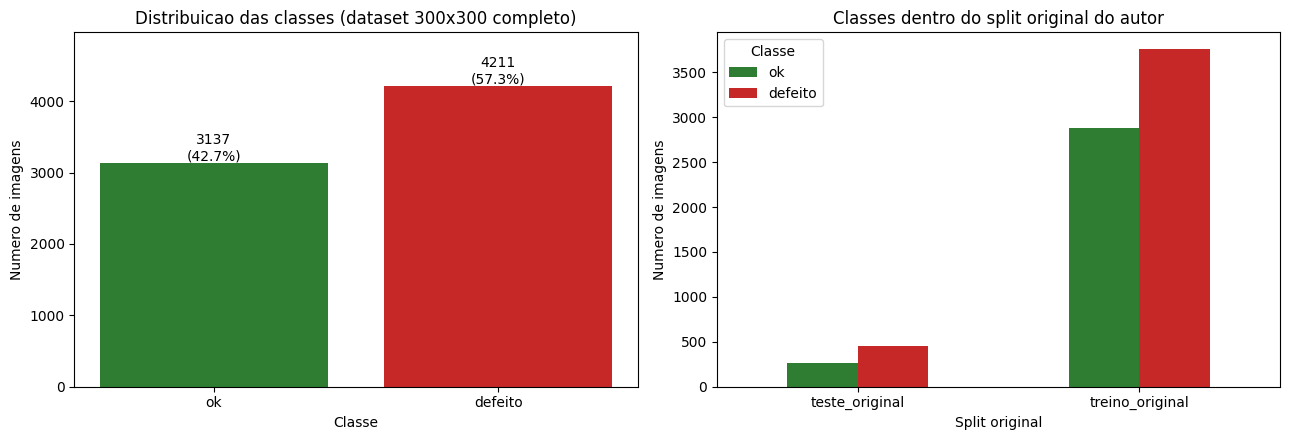

In [ ]:
# ============================================================
# DISTRIBUIÇÃO DAS CLASSES (geral e por split original)
# ============================================================

contagem = df["classe"].value_counts().reindex(NOMES_CLASSES)
percentual = 100 * contagem / contagem.sum()

tabela_cruzada = pd.crosstab(df["split_original"], df["classe"])
tabela_pct = 100 * tabela_cruzada.div(tabela_cruzada.sum(axis=1), axis=0)

print("📊 Distribuição geral das classes")
for nome in NOMES_CLASSES:
    print(f"   {nome:<8} {contagem[nome]:>5} imagens ({percentual[nome]:.1f}%)")

razao = contagem.max() / contagem.min()
print(f"\n   Razão maior/menor classe: {razao:.2f}:1", end="  ")
print("-> desbalanceamento LEVE" if razao < 1.5 else "-> desbalanceamento relevante")

print("\n📊 Distribuição dentro do split ORIGINAL do autor (%):")
print(tabela_pct.round(1).to_string())
print("\n   Nota: treino e teste originais têm proporções diferentes entre si.")
print("   Esse é um dos motivos para refazermos o split do zero (seção 4.2).")

fig, eixos = plt.subplots(1, 2, figsize=(13, 4.5))

barras = eixos[0].bar(contagem.index, contagem.values, color=["#2e7d32", "#c62828"])
for barra, valor, pct in zip(barras, contagem.values, percentual.values):
    eixos[0].text(barra.get_x() + barra.get_width() / 2, valor + 40,
                  f"{valor}\n({pct:.1f}%)", ha="center", fontsize=10)
eixos[0].set_title("Distribuicao das classes (dataset 300x300 completo)")
eixos[0].set_xlabel("Classe")
eixos[0].set_ylabel("Numero de imagens")
eixos[0].set_ylim(0, contagem.max() * 1.18)

tabela_cruzada.reindex(columns=NOMES_CLASSES).plot(
    kind="bar", ax=eixos[1], color=["#2e7d32", "#c62828"], rot=0
)
eixos[1].set_title("Classes dentro do split original do autor")
eixos[1].set_xlabel("Split original")
eixos[1].set_ylabel("Numero de imagens")
eixos[1].legend(title="Classe")

plt.tight_layout()
plt.show()

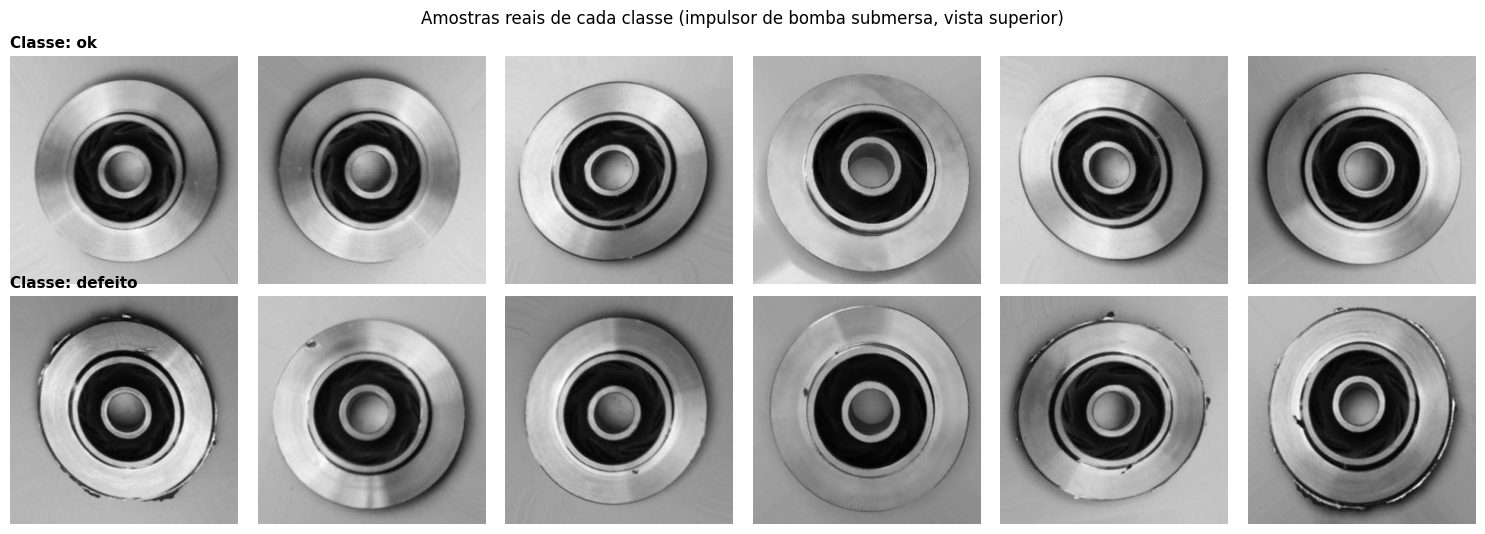

👀 O que procurar nas imagens 'defeito': manchas escuras de porosidade, 
   bordas irregulares (rebarba), riscos e falhas no anel externo e nas pás.
   Muitos defeitos ocupam poucos pixels — daí a preocupação com resolução.


In [ ]:
# ============================================================
# GRADE DE AMOSTRAS DE CADA CLASSE
# ============================================================

rng_eda = np.random.default_rng(SEED)
N_AMOSTRAS = 6

fig, eixos = plt.subplots(2, N_AMOSTRAS, figsize=(15, 5.4))
for linha, nome_classe in enumerate(NOMES_CLASSES):
    subconjunto = df[df["classe"] == nome_classe]
    escolhidas = rng_eda.choice(subconjunto["caminho"].values, N_AMOSTRAS, replace=False)
    for coluna, caminho in enumerate(escolhidas):
        with Image.open(caminho) as im:
            eixos[linha, coluna].imshow(np.asarray(im.convert("L")), cmap="gray")
        eixos[linha, coluna].axis("off")
        if coluna == 0:
            eixos[linha, coluna].set_title(f"Classe: {nome_classe}", loc="left",
                                           fontsize=11, fontweight="bold")

plt.suptitle("Amostras reais de cada classe (impulsor de bomba submersa, vista superior)")
plt.tight_layout()
plt.show()

print("👀 O que procurar nas imagens 'defeito': manchas escuras de porosidade, ")
print("   bordas irregulares (rebarba), riscos e falhas no anel externo e nas pás.")
print("   Muitos defeitos ocupam poucos pixels — daí a preocupação com resolução.")

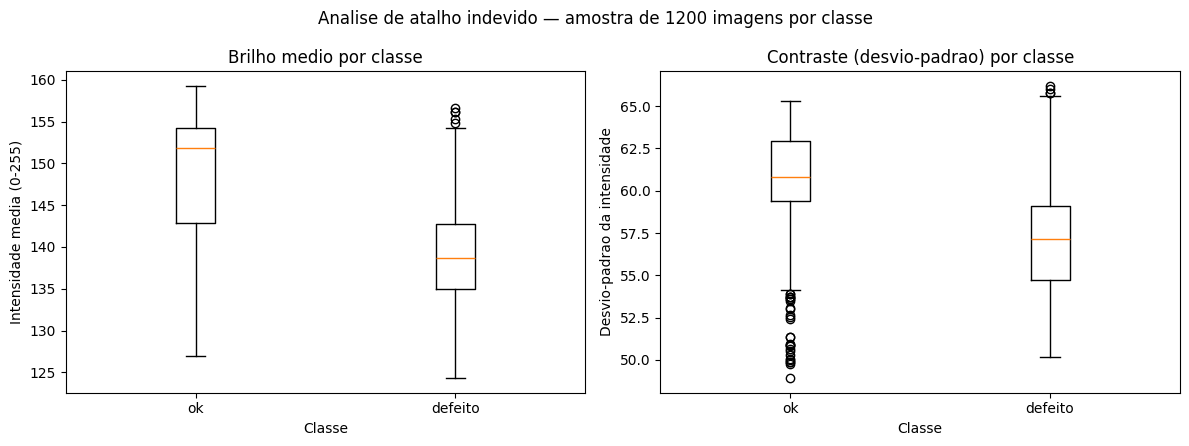

📏 AUC-ROC usando SOMENTE o brilho medio:   0.873
📏 AUC-ROC usando SOMENTE o contraste:      0.838
   (AUC = área sob a curva ROC; 0,5 é sorte pura, 1,0 é separação perfeita.)
   ⚠️ ATENÇÃO: iluminação sozinha separa bem as classes. Existe risco real
      de a CNN aprender esse atalho. Vale reforçar augmentation de brilho.


In [ ]:
# ============================================================
# ATALHO INDEVIDO? BRILHO E CONTRASTE POR CLASSE
# ============================================================
# Se a classe puder ser adivinhada só pela iluminação, a CNN vai aprender
# a iluminação, não o defeito. Medimos isso antes de treinar qualquer coisa.

def estatisticas_iluminacao(caminhos, lado=64):
    """Retorna brilho médio e desvio-padrão (contraste) de cada imagem, em 0-255."""
    brilhos, contrastes = [], []
    for caminho in caminhos:
        with Image.open(caminho) as im:
            arranjo = np.asarray(im.convert("L").resize((lado, lado)), dtype=np.float32)
        brilhos.append(arranjo.mean())
        contrastes.append(arranjo.std())
    return np.array(brilhos), np.array(contrastes)


n_amostra = min(CONFIG["AMOSTRA_EDA"], df["classe"].value_counts().min())
amostra_eda = pd.concat(
    [grupo.sample(n_amostra, random_state=SEED) for _, grupo in df.groupby("classe")]
)

brilho, contraste = estatisticas_iluminacao(amostra_eda["caminho"].values)
y_amostra = amostra_eda["rotulo"].values

dados_brilho = [brilho[y_amostra == 0], brilho[y_amostra == 1]]
dados_contraste = [contraste[y_amostra == 0], contraste[y_amostra == 1]]

fig, eixos = plt.subplots(1, 2, figsize=(12, 4.5))
eixos[0].boxplot(dados_brilho)
eixos[0].set_xticks([1, 2], NOMES_CLASSES)
eixos[0].set_title("Brilho medio por classe")
eixos[0].set_xlabel("Classe")
eixos[0].set_ylabel("Intensidade media (0-255)")

eixos[1].boxplot(dados_contraste)
eixos[1].set_xticks([1, 2], NOMES_CLASSES)
eixos[1].set_title("Contraste (desvio-padrao) por classe")
eixos[1].set_xlabel("Classe")
eixos[1].set_ylabel("Desvio-padrao da intensidade")

plt.suptitle(f"Analise de atalho indevido — amostra de {n_amostra} imagens por classe")
plt.tight_layout()
plt.show()

# Quão longe se chega usando SÓ o brilho como "modelo"?
auc_brilho = roc_auc_score(y_amostra, brilho)
auc_brilho = max(auc_brilho, 1 - auc_brilho)
auc_contraste = roc_auc_score(y_amostra, contraste)
auc_contraste = max(auc_contraste, 1 - auc_contraste)

print(f"📏 AUC-ROC usando SOMENTE o brilho medio:   {auc_brilho:.3f}")
print(f"📏 AUC-ROC usando SOMENTE o contraste:      {auc_contraste:.3f}")
print("   (AUC = área sob a curva ROC; 0,5 é sorte pura, 1,0 é separação perfeita.)")
if max(auc_brilho, auc_contraste) > 0.70:
    print("   ⚠️ ATENÇÃO: iluminação sozinha separa bem as classes. Existe risco real")
    print("      de a CNN aprender esse atalho. Vale reforçar augmentation de brilho.")
else:
    print("   ✅ Iluminação sozinha separa pouco: o sinal útil está na textura/forma,")
    print("      que é exatamente o que queremos que a CNN aprenda.")

> 💡 **Desbalanceamento leve.** A classe "defeito" é a majoritária neste dataset (o código acima imprime as proporções reais). Isso é o *oposto* de uma linha de produção madura, onde defeito é raro. A consequência prática aparece na seção 11: a precisão que medimos aqui **não** se transfere para uma linha com 3% de defeitos.

> 💬 **Para discutir:** se o brilho sozinho tivesse AUC de 0,95, o modelo ainda seria útil? Como você provaria que ele aprendeu o defeito, e não a lâmpada?

---

## 4. 🛡️ Auditoria de vazamento e pré-processamento

### 4.1 Quase-duplicatas

> 🧭 **O que estamos fazendo?** Calculando um **hash perceptual** (uma assinatura numérica curta que resume o conteúdo visual da imagem) de cada foto, inclusive das suas 8 versões espelhadas/giradas de 90°, e agrupando imagens visualmente quase iguais.
> 🎯 **Por que é necessário?** O autor do dataset já aplicou data augmentation (**data augmentation** = criar variações artificiais de uma imagem para ampliar o conjunto de treino). A mesma peça física aparece espelhada e girada em vários arquivos. Se uma variante cair no treino e outra no teste, estaremos testando o modelo em peças que ele já viu — isso é **vazamento de dados** (*data leakage*), e as métricas ficam artificialmente altas.
> 🚫 **E se pulássemos?** Reportaríamos um recall lindo que desabaria no primeiro dia de fábrica.

> 💡 **Por que distância de Hamming, e não igualdade exata?** O notebook-modelo comparava hashes só por igualdade, o que detecta cópias idênticas byte a byte. Duas variantes com brilho levemente alterado têm hashes **parecidos, mas não iguais**. A distância de Hamming (número de bits diferentes entre dois hashes) captura essa semelhança; o limiar está na `CONFIG`.

In [ ]:
# ============================================================
# HASH PERCEPTUAL CANÔNICO (invariante a espelhamento e giros de 90°)
# ============================================================
# Para cada imagem calculamos o pHash das suas 8 transformações do grupo
# diedral (4 rotações x 2 espelhamentos) e guardamos o MENOR deles.
# Assim, duas variantes giradas da mesma peça recebem a mesma assinatura.

def oito_variantes(imagem):
    """Gera as 8 versões diedrais (giros de 90° e espelhamentos) de uma imagem."""
    variantes = []
    atual = imagem
    for _ in range(4):
        variantes.append(atual)
        variantes.append(ImageOps.mirror(atual))
        atual = atual.transpose(Image.ROTATE_90)
    return variantes


def hash_canonico(caminho, tamanho):
    """Menor pHash entre as 8 variantes diedrais, como inteiro de 64 bits."""
    with Image.open(caminho) as imagem:
        cinza = imagem.convert("L")
        valores = []
        for variante in oito_variantes(cinza):
            bits = imagehash.phash(variante, hash_size=tamanho).hash.flatten()
            valores.append(int("".join("1" if b else "0" for b in bits), 2))
    return min(valores)


print("🔐 Calculando hashes perceptuais canônicos (8 variantes por imagem)...")
inicio = time.time()

lista_hashes = []
for posicao, caminho in enumerate(df["caminho"].values):
    lista_hashes.append(hash_canonico(caminho, CONFIG["TAMANHO_PHASH"]))
    if (posicao + 1) % 1500 == 0:
        print(f"   {posicao + 1}/{len(df)} imagens processadas "
              f"({time.time() - inicio:.0f}s)")

hashes = np.array(lista_hashes, dtype=np.uint64)
df["hash"] = hashes
print(f"✅ {len(hashes)} hashes de {CONFIG['TAMANHO_PHASH']**2} bits em "
      f"{time.time() - inicio:.0f}s")
print(f"   Hashes exatamente idênticos: {len(hashes) - len(np.unique(hashes))} imagens "
      f"em {len(np.unique(hashes))} assinaturas distintas")

🔐 Calculando hashes perceptuais canônicos (8 variantes por imagem)...
   1500/7348 imagens processadas (14s)
   3000/7348 imagens processadas (31s)
   4500/7348 imagens processadas (47s)
   6000/7348 imagens processadas (61s)
✅ 7348 hashes de 64 bits em 73s
   Hashes exatamente idênticos: 1398 imagens em 5950 assinaturas distintas


In [ ]:
# ============================================================
# DISTÂNCIA DE HAMMING VETORIZADA + AGRUPAMENTO POR UNION-FIND
# ============================================================
# Comparar ~7,3k x 7,3k pares em Python puro levaria horas. Fazemos em
# blocos com numpy: XOR dos hashes e contagem de bits por tabela de consulta.

TABELA_BITS = np.unpackbits(
    np.arange(256, dtype=np.uint8)[:, None], axis=1
).sum(axis=1).astype(np.uint8)


def distancias_em_bloco(bloco, todos):
    """Matriz de distâncias de Hamming entre um bloco de hashes e todos os hashes."""
    xor = np.bitwise_xor(bloco[:, None], todos[None, :])
    bytes_xor = xor.view(np.uint8).reshape(bloco.size, todos.size, 8)
    return TABELA_BITS[bytes_xor].sum(axis=2)


class UnionFind:
    """Estrutura clássica para agrupar elementos ligados por pares (componentes conexas)."""

    def __init__(self, n):
        self.pai = list(range(n))

    def raiz(self, x):
        while self.pai[x] != x:
            self.pai[x] = self.pai[self.pai[x]]
            x = self.pai[x]
        return x

    def unir(self, a, b):
        ra, rb = self.raiz(a), self.raiz(b)
        if ra != rb:
            self.pai[rb] = ra


TAMANHO_BLOCO = 512


def agrupar_por_limiar(hashes, limiar, guardar_pares=False, max_pares=50000):
    """Agrupa os hashes por componentes conexas sob um limiar de Hamming.

    Devolve (grupos, pares_encontrados). Reaproveitável tanto para testar
    vários limiares (seção de diagnóstico) quanto para o agrupamento final.
    """
    uf_local = UnionFind(len(hashes))
    pares = []
    for comeco in range(0, len(hashes), TAMANHO_BLOCO):
        fim = min(comeco + TAMANHO_BLOCO, len(hashes))
        distancias = distancias_em_bloco(hashes[comeco:fim], hashes)
        linhas, colunas = np.where(distancias <= limiar)
        linhas = linhas + comeco
        mascara = linhas < colunas            # cada par uma única vez
        for i, j in zip(linhas[mascara], colunas[mascara]):
            uf_local.unir(int(i), int(j))
            if guardar_pares and len(pares) < max_pares:
                pares.append((int(i), int(j), int(distancias[i - comeco, j])))
    grupos_local = np.array([uf_local.raiz(i) for i in range(len(hashes))])
    return grupos_local, pares


print("✅ Funcao agrupar_por_limiar() definida. Nenhum agrupamento executado ainda.")

✅ Funcao agrupar_por_limiar() definida. Nenhum agrupamento executado ainda.


In [ ]:
# ============================================================
# DIAGNÓSTICO: VARREDURA DE LIMIARES ANTES DE ESCOLHER UM VALOR
# ============================================================
# Peças fundidas do mesmo molde são naturalmente parecidas entre si. Um
# limiar de Hamming grande demais faz o union-find "encadear" imagens
# diferentes (A perto de B, B perto de C => A e C no mesmo grupo mesmo
# estando longe um do outro), formando um grupo gigante que desequilibra
# o split. Por isso testamos alguns valores ANTES de decidir.

limite_suspeito = CONFIG["TAMANHO_GRUPO_SUSPEITO"] * len(hashes)

print(f"{'limiar':>6} | {'n_grupos':>9} | {'maior_grupo':>12} | {'% do dataset':>12}")
for candidato in [0, 1, 2, 3, 4]:
    grupos_teste, _ = agrupar_por_limiar(hashes, candidato)
    tamanhos_teste = pd.Series(grupos_teste).value_counts()
    n_g = len(tamanhos_teste)
    maior = int(tamanhos_teste.max())
    marca = "⚠️" if maior > limite_suspeito else "✅"
    print(f"{candidato:>6} | {n_g:>9} | {maior:>12} | {100*maior/len(hashes):>11.1f}% {marca}")

print(f"\n💡 Escolha o MENOR limiar cujo maior grupo fique claramente abaixo de "
      f"{100*CONFIG['TAMANHO_GRUPO_SUSPEITO']:.0f}% do dataset. Um limiar grande demais")
print("   não detecta 'mais duplicatas': ele funde peças diferentes por encadeamento.")
print("   Ajuste CONFIG['LIMIAR_HAMMING'] na célula abaixo com base nesta tabela.")

limiar |  n_grupos |  maior_grupo | % do dataset
     0 |      5950 |           20 |         0.3% ✅
     1 |      5950 |           20 |         0.3% ✅
     2 |      2745 |          867 |        11.8% ⚠️
     3 |      2745 |          867 |        11.8% ⚠️
     4 |       877 |         5680 |        77.3% ⚠️

💡 Escolha o MENOR limiar cujo maior grupo fique claramente abaixo de 1% do dataset. Um limiar grande demais
   não detecta 'mais duplicatas': ele funde peças diferentes por encadeamento.
   Ajuste CONFIG['LIMIAR_HAMMING'] na célula abaixo com base nesta tabela.


In [ ]:
# ============================================================
# AGRUPAMENTO FINAL, COM O LIMIAR ESCOLHIDO NO DIAGNÓSTICO ACIMA
# ============================================================

# CONFIG['LIMIAR_HAMMING'] pode ser ajustado aqui com base na tabela anterior,
# sem precisar voltar à célula CONFIG.
CONFIG["LIMIAR_HAMMING"] = 1

limiar = CONFIG["LIMIAR_HAMMING"]
print(f"🔎 Agrupando com distância de Hamming <= {limiar} bits...")
inicio = time.time()

grupos, pares_encontrados = agrupar_por_limiar(hashes, limiar, guardar_pares=True)
df["grupo"] = grupos

print(f"✅ Concluído em {time.time() - inicio:.0f}s | pares semelhantes: {len(pares_encontrados)}")

🔎 Agrupando com distância de Hamming <= 1 bits...
✅ Concluído em 3s | pares semelhantes: 2567


📦 Grupos formados: 5950 (para 7348 imagens)
   Redução efetiva de 'peças distintas': 19.0%
   Imagens em grupos com mais de 1 membro: 2304 (31.4%)
   Maior grupo: 20 imagens

📊 Distribuição do tamanho dos grupos:
   grupos com   1 imagem(ns): 5044
   grupos com   2 imagem(ns): 654
   grupos com   3 imagem(ns): 148
   grupos com   4 imagem(ns): 56
   grupos com   5 imagem(ns): 20
   grupos com   6 imagem(ns): 11
   grupos com   7 imagem(ns): 5
   grupos com   8 imagem(ns): 2
   grupos com   9 imagem(ns): 2
   grupos com  10 imagem(ns): 4
   grupos com  11 imagem(ns): 3
   grupos com  20 imagem(ns): 1

✅ Maior grupo (20) dentro do esperado para o limiar 1.


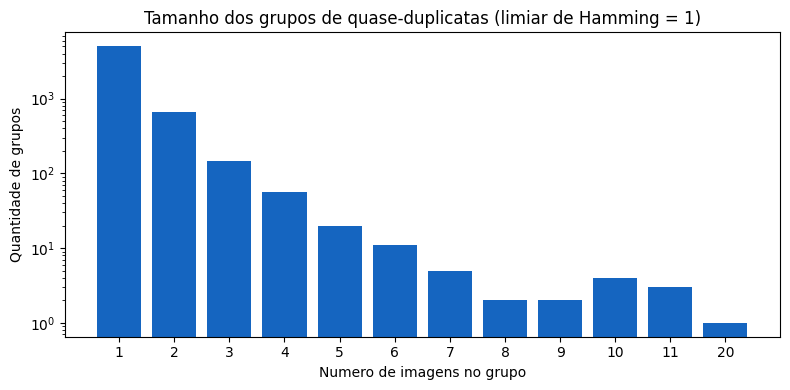

In [ ]:
# ============================================================
# RELATÓRIO DOS GRUPOS DE QUASE-DUPLICATAS
# ============================================================

tamanhos_grupos = df["grupo"].value_counts()
distribuicao = tamanhos_grupos.value_counts().sort_index()
n_grupos = len(tamanhos_grupos)
imagens_agrupadas = int(tamanhos_grupos[tamanhos_grupos > 1].sum())
maior_grupo = int(tamanhos_grupos.max())

print(f"📦 Grupos formados: {n_grupos} (para {len(df)} imagens)")
print(f"   Redução efetiva de 'peças distintas': "
      f"{100 * (1 - n_grupos / len(df)):.1f}%")
print(f"   Imagens em grupos com mais de 1 membro: {imagens_agrupadas} "
      f"({100 * imagens_agrupadas / len(df):.1f}%)")
print(f"   Maior grupo: {maior_grupo} imagens")

print("\n📊 Distribuição do tamanho dos grupos:")
for tamanho, quantidade in distribuicao.items():
    print(f"   grupos com {tamanho:>3} imagem(ns): {quantidade}")

limite_suspeito = CONFIG["TAMANHO_GRUPO_SUSPEITO"] * len(df)
if maior_grupo > limite_suspeito:
    print(f"\n⚠️ O maior grupo tem {maior_grupo} imagens (> {limite_suspeito:.0f}, "
          f"{100*CONFIG['TAMANHO_GRUPO_SUSPEITO']:.0f}% do dataset).")
    print("   Isso indica LIMIAR PERMISSIVO DEMAIS: peças fundidas do mesmo molde são")
    print("   naturalmente parecidas, e o hash está fundindo peças distintas num só grupo.")
    print(f"   Ação: reduzir CONFIG['LIMIAR_HAMMING'] (atual: {limiar}) e reexecutar.")
    print("   Consequência de não corrigir: o split fica desequilibrado, pois um grupo")
    print("   gigante vai inteiro para um único conjunto.")
else:
    print(f"\n✅ Maior grupo ({maior_grupo}) dentro do esperado para o limiar {limiar}.")

fig, eixo = plt.subplots(figsize=(8, 4))
eixo.bar(distribuicao.index.astype(str), distribuicao.values, color="#1565c0")
eixo.set_title(f"Tamanho dos grupos de quase-duplicatas (limiar de Hamming = {limiar})")
eixo.set_xlabel("Numero de imagens no grupo")
eixo.set_ylabel("Quantidade de grupos")
eixo.set_yscale("log")
plt.tight_layout()
plt.show()

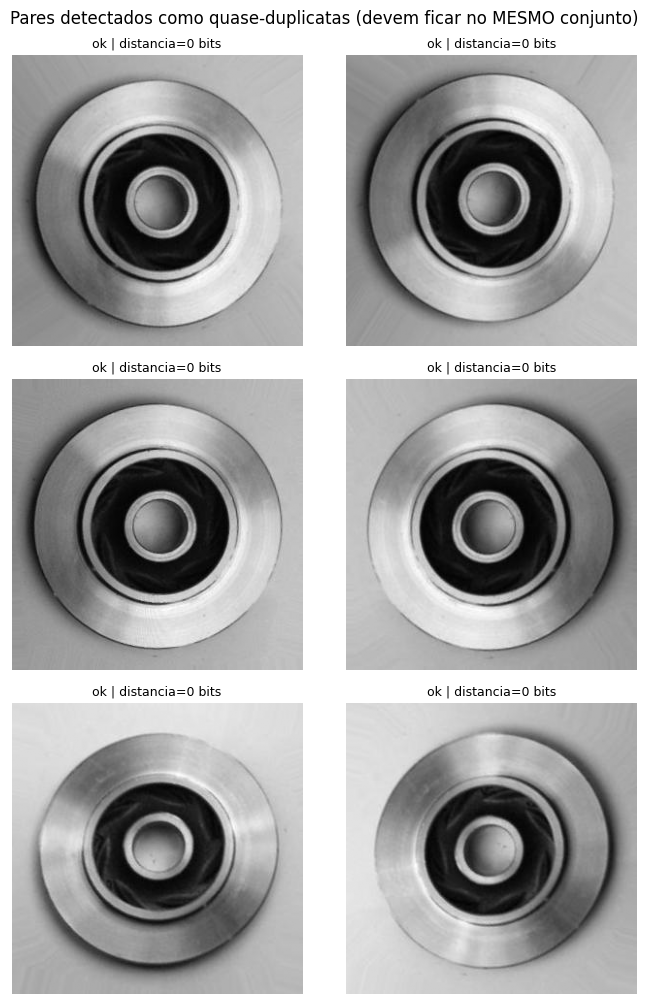

In [ ]:
# ============================================================
# EXEMPLOS VISUAIS DE PARES CONSIDERADOS QUASE-DUPLICATAS
# ============================================================

if pares_encontrados:
    rng_pares = np.random.default_rng(SEED)
    escolhidos = rng_pares.choice(len(pares_encontrados),
                                  size=min(3, len(pares_encontrados)), replace=False)
    fig, eixos = plt.subplots(len(escolhidos), 2, figsize=(7, 3.4 * len(escolhidos)))
    eixos = np.atleast_2d(eixos)
    for linha, indice_par in enumerate(escolhidos):
        i, j, distancia = pares_encontrados[indice_par]
        for coluna, indice_img in enumerate([i, j]):
            with Image.open(df["caminho"].iloc[indice_img]) as im:
                eixos[linha, coluna].imshow(np.asarray(im.convert("L")), cmap="gray")
            eixos[linha, coluna].axis("off")
            eixos[linha, coluna].set_title(
                f"{df['classe'].iloc[indice_img]} | distancia={distancia} bits", fontsize=9
            )
    plt.suptitle("Pares detectados como quase-duplicatas (devem ficar no MESMO conjunto)")
    plt.tight_layout()
    plt.show()
else:
    print("ℹ️ Nenhum par abaixo do limiar. Todos os grupos têm uma única imagem.")

> ⚠️ **Limitação honesta deste método.** O pHash canônico captura cópias **idênticas, espelhadas ou giradas em múltiplos de 90°**. Ele **não** detecta rotações arbitrárias (por exemplo, 17°), mudanças fortes de brilho, recortes ou zoom pesado. Portanto, "nenhuma duplicata encontrada" **não prova** ausência de vazamento — prova apenas que o tipo de duplicata que sabemos procurar não está lá. Como o autor do dataset aplicou augmentation cujo detalhe não conhecemos, existe risco residual, e ele está registrado na seção 14.

### 4.2 Split por grupos

> 🧭 **O que estamos fazendo?** Dividindo as imagens em treino (~70%), validação (~15%) e teste (~15%) de modo que **todas as imagens de um mesmo grupo caiam no mesmo conjunto**, mantendo a proporção de classes.
> 🎯 **Por que é necessário?** Um split aleatório comum quebraria os grupos de quase-duplicatas ao meio, e o teste conteria variantes de peças já vistas no treino.
> 🚫 **E se pulássemos?** Teríamos um número de recall que mede memorização, não generalização.

> 💡 **Por que dois estágios de `StratifiedGroupKFold`?** Não existe uma função pronta que faça um corte triplo estratificado *e* agrupado. Fazemos em duas etapas: primeiro separamos 1/7 para o teste (≈14,3%), depois 1/6 do restante para a validação (≈14,3% do total). O resultado é ≈71/14/14 — uma aproximação de 70/15/15 que preserva as duas restrições importantes (grupos inteiros e proporção de classes). As proporções exatas são impressas pelo código.

In [ ]:
# ============================================================
# SPLIT ESTRATIFICADO E AGRUPADO, EM DOIS ESTÁGIOS
# ============================================================

X_indices = np.arange(len(df))
y_todos = df["rotulo"].values
grupos = df["grupo"].values

# Estágio 1: separa o TESTE (1/7 ≈ 14,3%)
divisor_teste = StratifiedGroupKFold(n_splits=7, shuffle=True, random_state=SEED)
idx_restante, idx_teste = next(divisor_teste.split(X_indices, y_todos, grupos))

# Estágio 2: separa a VALIDAÇÃO dentro do restante (1/6 do restante ≈ 14,3% do total)
divisor_val = StratifiedGroupKFold(n_splits=6, shuffle=True, random_state=SEED)
sub_treino, sub_val = next(
    divisor_val.split(idx_restante, y_todos[idx_restante], grupos[idx_restante])
)
idx_treino = idx_restante[sub_treino]
idx_val = idx_restante[sub_val]

df["conjunto"] = "indefinido"
df.loc[df.index[idx_treino], "conjunto"] = "treino"
df.loc[df.index[idx_val], "conjunto"] = "validacao"
df.loc[df.index[idx_teste], "conjunto"] = "teste"

df_treino = df[df["conjunto"] == "treino"].reset_index(drop=True)
df_val = df[df["conjunto"] == "validacao"].reset_index(drop=True)
df_teste = df[df["conjunto"] == "teste"].reset_index(drop=True)

print("📊 PROVA (a) — tamanho e composição de cada conjunto\n")
cabecalho = f"{'Conjunto':<12}{'N':>7}{'%total':>9}{'defeito':>10}{'% defeito':>12}{'ok':>8}{'% ok':>8}"
print(cabecalho)
print("-" * len(cabecalho))
for nome, parte in [("treino", df_treino), ("validacao", df_val), ("teste", df_teste)]:
    n_def = int((parte["rotulo"] == 1).sum())
    n_ok = int((parte["rotulo"] == 0).sum())
    print(f"{nome:<12}{len(parte):>7}{100*len(parte)/len(df):>8.1f}%"
          f"{n_def:>10}{100*n_def/len(parte):>11.1f}%{n_ok:>8}{100*n_ok/len(parte):>7.1f}%")
print("-" * len(cabecalho))
print(f"{'TOTAL':<12}{len(df):>7}{100.0:>8.1f}%"
      f"{int((df['rotulo']==1).sum()):>10}"
      f"{100*(df['rotulo']==1).mean():>11.1f}%"
      f"{int((df['rotulo']==0).sum()):>8}{100*(df['rotulo']==0).mean():>7.1f}%")

📊 PROVA (a) — tamanho e composição de cada conjunto

Conjunto          N   %total   defeito   % defeito      ok    % ok
------------------------------------------------------------------
treino         5265    71.7%      3005       57.1%    2260   42.9%
validacao      1044    14.2%       594       56.9%     450   43.1%
teste          1039    14.1%       612       58.9%     427   41.1%
------------------------------------------------------------------
TOTAL          7348   100.0%      4211       57.3%    3137   42.7%


In [ ]:
# ============================================================
# PROVA (b): INTERSEÇÃO DE GRUPOS ENTRE OS CONJUNTOS DEVE SER VAZIA
# ============================================================

g_treino = set(df_treino["grupo"])
g_val = set(df_val["grupo"])
g_teste = set(df_teste["grupo"])

interseccoes = {
    "treino ∩ validacao": g_treino & g_val,
    "treino ∩ teste": g_treino & g_teste,
    "validacao ∩ teste": g_val & g_teste,
}

print("🛡️ PROVA (b) — interseção de grupos entre os conjuntos\n")
tudo_ok = True
for nome, conjunto in interseccoes.items():
    if len(conjunto) == 0:
        print(f"   ✅ {nome:<22} = ∅  (0 grupos em comum)")
    else:
        tudo_ok = False
        print(f"   ❌ {nome:<22} = {len(conjunto)} grupos em comum — VAZAMENTO!")

# Verificação redundante, mas barata: nenhum caminho repetido entre conjuntos
caminhos_repetidos = (
    len(set(df_treino["caminho"]) & set(df_teste["caminho"]))
    + len(set(df_val["caminho"]) & set(df_teste["caminho"]))
)
print(f"   {'✅' if caminhos_repetidos == 0 else '❌'} arquivos repetidos entre conjuntos: "
      f"{caminhos_repetidos}")

assert tudo_ok and caminhos_repetidos == 0, "Vazamento detectado — corrija antes de treinar."
print(f"\n✅ Split agrupado validado. Grupos: treino={len(g_treino)}, "
      f"validacao={len(g_val)}, teste={len(g_teste)}")

🛡️ PROVA (b) — interseção de grupos entre os conjuntos

   ✅ treino ∩ validacao     = ∅  (0 grupos em comum)
   ✅ treino ∩ teste         = ∅  (0 grupos em comum)
   ✅ validacao ∩ teste      = ∅  (0 grupos em comum)
   ✅ arquivos repetidos entre conjuntos: 0

✅ Split agrupado validado. Grupos: treino=4253, validacao=848, teste=849


### 4.3 Normalização e carregadores de dados

> 🧭 **O que estamos fazendo?** Redimensionando todas as imagens para 128x128 em 1 canal, carregando-as para a memória, calculando média e desvio-padrão **apenas do treino** e montando os `DataLoader`.
> 🎯 **Por que é necessário?** Redes convolucionais treinam melhor com entradas centradas em zero e escala parecida; e as estatísticas de normalização são um **parâmetro aprendido do treino** — tirá-las do dataset inteiro já é uma forma sutil de vazamento.
> 🚫 **E se pulássemos?** O gradiente ficaria mal condicionado, a convergência mais lenta, e as métricas de teste levemente otimistas por contaminação estatística.

> 💡 **Por que 128x128 e não 300x300?** O custo computacional de uma convolução cresce com o quadrado do lado: 300² é ~5,5x mais caro que 128². Em 128 px ainda sobram detalhes suficientes para porosidade e rebarba, e o treino completo cabe em poucos minutos numa T4. `IMG_SIZE` está na `CONFIG` justamente para que essa escolha possa ser testada: subir para 192 é um experimento de uma linha.

> 💡 **Por que NÃO usamos a média/desvio do ImageNet?** Aquelas constantes (0,485/0,229 etc.) descrevem fotos coloridas da internet. Aqui as imagens são monocromáticas, de uma bancada com iluminação controlada — a distribuição é outra. Calculamos as nossas.

> ⚠️ **O conjunto de teste não pode ser tocado até a seção 9.** Nem para calcular média, nem para escolher limiar, nem para "dar uma olhada". Cada olhada no teste gasta um pouco da sua capacidade de estimar o desempenho real; olhar várias vezes e escolher o melhor resultado é uma forma disfarçada de treinar nele.

In [ ]:
# ============================================================
# PRÉ-CARGA DAS IMAGENS REDIMENSIONADAS EM MEMÓRIA
# ============================================================
# 7,3k imagens de 128x128 em uint8 ocupam ~120 MB: cabem folgadamente na RAM
# do Colab. Ler do disco a cada época seria o gargalo do treino.

def carregar_em_memoria(caminhos, lado):
    """Lê as imagens, converte para escala de cinza e redimensiona, devolvendo um array uint8."""
    arranjo = np.zeros((len(caminhos), lado, lado), dtype=np.uint8)
    for posicao, caminho in enumerate(caminhos):
        with Image.open(caminho) as imagem:
            arranjo[posicao] = np.asarray(
                imagem.convert("L").resize((lado, lado), Image.BILINEAR)
            )
    return arranjo


inicio = time.time()
img_treino = carregar_em_memoria(df_treino["caminho"].values, IMG_SIZE)
img_val = carregar_em_memoria(df_val["caminho"].values, IMG_SIZE)
img_teste = carregar_em_memoria(df_teste["caminho"].values, IMG_SIZE)

y_treino = df_treino["rotulo"].values.astype(np.float32)
y_val = df_val["rotulo"].values.astype(np.float32)
y_teste = df_teste["rotulo"].values.astype(np.float32)

print(f"✅ Imagens em memória em {time.time() - inicio:.1f}s")
print(f"   treino    {img_treino.shape} | {img_treino.nbytes / 1e6:.0f} MB")
print(f"   validacao {img_val.shape}")
print(f"   teste     {img_teste.shape}")

# Média e desvio calculados SOMENTE no treino
MEDIA = float(img_treino.mean() / 255.0)
DESVIO = float(img_treino.std() / 255.0)
print(f"\n📐 Normalização (derivada apenas do TREINO): media={MEDIA:.4f} | desvio={DESVIO:.4f}")

✅ Imagens em memória em 11.3s
   treino    (5265, 128, 128) | 86 MB
   validacao (1044, 128, 128)
   teste     (1039, 128, 128)

📐 Normalização (derivada apenas do TREINO): media=0.5639 | desvio=0.2343


In [ ]:
# ============================================================
# DATASET CUSTOMIZADO, TRANSFORMAÇÕES E DATALOADERS
# ============================================================
# Usamos um Dataset próprio (e não ImageFolder) porque o split foi decidido
# sobre um DataFrame de caminhos e grupos, não sobre a árvore de pastas.

class ConjuntoPecas(Dataset):
    """Imagens de peças já redimensionadas em memória, com rótulo binário (1=defeito)."""

    def __init__(self, imagens, rotulos, transformacoes=None):
        self.imagens = imagens
        self.rotulos = rotulos
        self.transformacoes = transformacoes

    def __len__(self):
        return len(self.imagens)

    def __getitem__(self, indice):
        tensor = torch.from_numpy(self.imagens[indice]).unsqueeze(0).float().div_(255.0)
        if self.transformacoes is not None:
            tensor = self.transformacoes(tensor)
        return tensor, torch.tensor(self.rotulos[indice], dtype=torch.float32)


# Augmentation SOMENTE no treino. Validação e teste recebem apenas normalização.
transformacoes_treino = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomAffine(degrees=10, scale=(0.9, 1.1)),
    T.Normalize(mean=[MEDIA], std=[DESVIO]),
])

transformacoes_avaliacao = T.Compose([
    T.Normalize(mean=[MEDIA], std=[DESVIO]),
])

ds_treino = ConjuntoPecas(img_treino, y_treino, transformacoes_treino)
ds_val = ConjuntoPecas(img_val, y_val, transformacoes_avaliacao)
ds_teste = ConjuntoPecas(img_teste, y_teste, transformacoes_avaliacao)

argumentos_loader = dict(
    batch_size=CONFIG["BATCH_SIZE"],
    num_workers=CONFIG["NUM_WORKERS"],
    pin_memory=(DISPOSITIVO.type == "cuda"),
    worker_init_fn=iniciar_worker,
)

loader_treino = DataLoader(ds_treino, shuffle=True, drop_last=False,
                           generator=GERADOR, **argumentos_loader)
loader_val = DataLoader(ds_val, shuffle=False, **argumentos_loader)
loader_teste = DataLoader(ds_teste, shuffle=False, **argumentos_loader)

print("✅ DataLoaders prontos")
print(f"   treino    {len(ds_treino):>5} imagens | {len(loader_treino):>3} batches")
print(f"   validacao {len(ds_val):>5} imagens | {len(loader_val):>3} batches")
print(f"   teste     {len(ds_teste):>5} imagens | {len(loader_teste):>3} batches")
print(f"   (batch = grupo de imagens processadas juntas em um passo do treino)")

✅ DataLoaders prontos
   treino     5265 imagens | 165 batches
   validacao  1044 imagens |  33 batches
   teste      1039 imagens |  33 batches
   (batch = grupo de imagens processadas juntas em um passo do treino)


> 💡 **Este é o SEGUNDO nível de augmentation.** O primeiro foi aplicado pelo autor do dataset, nas imagens que baixamos. O nosso é aplicado **em tempo de execução**, de forma diferente a cada época, e só no treino. Mantivemos as transformações modestas (flip horizontal, ±10° de rotação, ±10% de zoom) de propósito: exagerar em cima de um conjunto já aumentado produz imagens cada vez mais distantes do que a câmera da linha realmente vê.

| Técnica | Por que usar |
|---|---|
| Flip horizontal | A peça é aproximadamente simétrica; o lado do defeito é irrelevante |
| Rotação ±10° | O impulsor pode ser posicionado torto na bancada |
| Zoom ±10% | Pequenas variações de distância da câmera |
| Normalização com estatística do treino | Estabiliza o gradiente sem vazar informação do teste |
| **Não** usar flip vertical extremo ou cor | Imagens são monocromáticas e a vista é sempre superior |

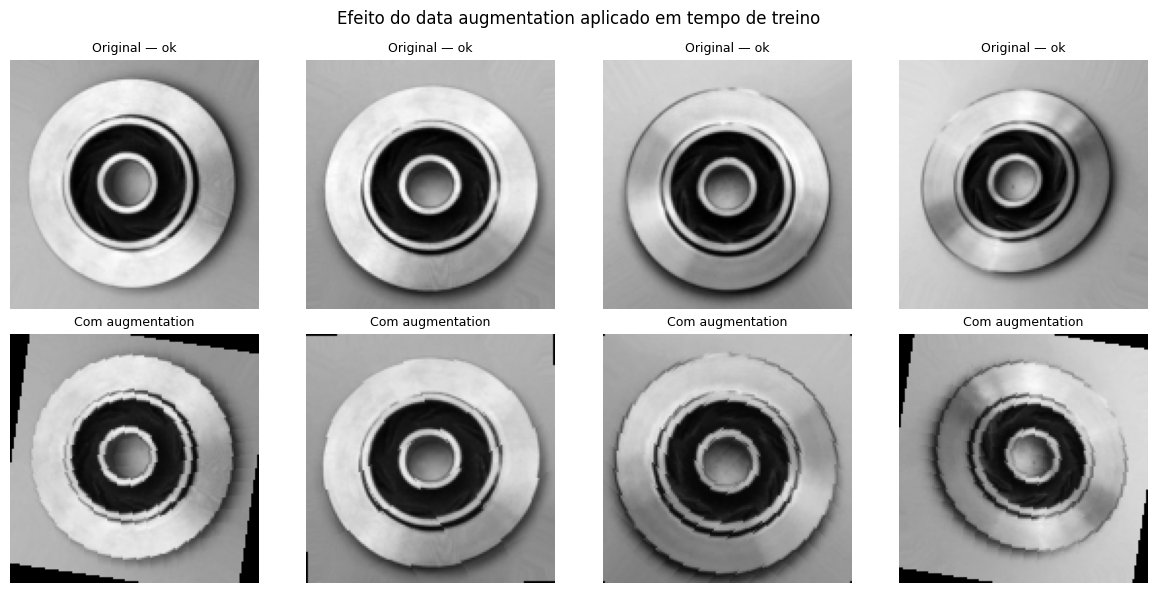

In [ ]:
# ============================================================
# VERIFICAÇÃO VISUAL: ANTES x DEPOIS DO AUGMENTATION
# ============================================================

fixar_sementes(SEED)
indices_exemplo = [0, 1, 2, 3]

fig, eixos = plt.subplots(2, len(indices_exemplo), figsize=(12, 6))
for coluna, indice in enumerate(indices_exemplo):
    original = torch.from_numpy(img_treino[indice]).unsqueeze(0).float() / 255.0
    aumentada = transformacoes_treino(original.clone())
    # desfaz a normalização apenas para visualizar
    aumentada_visivel = aumentada * DESVIO + MEDIA

    eixos[0, coluna].imshow(original.squeeze().numpy(), cmap="gray")
    eixos[0, coluna].set_title(f"Original — {MAPA_CLASSES[int(y_treino[indice])]}", fontsize=9)
    eixos[0, coluna].axis("off")

    eixos[1, coluna].imshow(aumentada_visivel.squeeze().numpy(), cmap="gray", vmin=0, vmax=1)
    eixos[1, coluna].set_title("Com augmentation", fontsize=9)
    eixos[1, coluna].axis("off")

plt.suptitle("Efeito do data augmentation aplicado em tempo de treino")
plt.tight_layout()
plt.show()

fixar_sementes(SEED)

> 💬 **Para discutir:** se aumentássemos a rotação para ±45°, o modelo ficaria mais robusto ou começaria a treinar em imagens que a câmera da linha nunca vai produzir?

---

## 5. 📏 Baseline ingênuo

> 🧭 **O que estamos fazendo?** Criando dois "modelos bobos": um que sempre responde a classe mais comum, e uma regressão logística que enxerga a imagem como uma lista de 1.024 pixels de 32x32, sem nenhuma noção de forma.
> 🎯 **Por que é necessário?** Eles são a régua. Se a rede neural não superar esses números, todo o trabalho extra — convolução, augmentation, GPU — não se pagou.
> 🚫 **E se pulássemos?** Poderíamos comemorar uma acurácia de 90% sem saber que chutar a classe majoritária já dá 57%.

> ⚠️ Os baselines são avaliados na **validação**, nunca no teste. O teste continua lacrado.

In [ ]:
# ============================================================
# BASELINE 1: PREVER SEMPRE A CLASSE MAJORITÁRIA
# ============================================================

classe_majoritaria = int(pd.Series(y_treino).mode()[0])
pred_majoritaria = np.full_like(y_val, fill_value=classe_majoritaria, dtype=int)

print(f"🤖 Baseline majoritário: responde sempre '{MAPA_CLASSES[classe_majoritaria]}' "
      f"(classe mais comum no treino)\n")


def relatar(nome, y_real, y_pred, probabilidades=None):
    """Imprime acurácia, recall/precisão de 'defeito' e especificidade; devolve um dicionário."""
    acuracia = accuracy_score(y_real, y_pred)
    recall_def = recall_score(y_real, y_pred, pos_label=1, zero_division=0)
    precisao_def = precision_score(y_real, y_pred, pos_label=1, zero_division=0)
    f1_def = f1_score(y_real, y_pred, pos_label=1, zero_division=0)
    especificidade = recall_score(y_real, y_pred, pos_label=0, zero_division=0)
    auc = roc_auc_score(y_real, probabilidades) if probabilidades is not None else float("nan")
    print(f"   {nome}")
    print(f"      acuracia          {acuracia:.4f}")
    print(f"      recall 'defeito'  {recall_def:.4f}   <- metrica principal")
    print(f"      precisao 'defeito'{precisao_def:.4f}")
    print(f"      F1 'defeito'      {f1_def:.4f}")
    print(f"      especificidade    {especificidade:.4f}   (recall da classe 'ok')")
    if probabilidades is not None:
        print(f"      AUC-ROC           {auc:.4f}")
    return {"nome": nome, "acuracia": acuracia, "recall": recall_def,
            "precisao": precisao_def, "f1": f1_def,
            "especificidade": especificidade, "auc": auc}


base_majoritaria = relatar("Baseline majoritario (validacao)", y_val, pred_majoritaria)
print("\n   💡 Note o recall 1,0000 com precisao igual à prevalência: é exatamente a")
print("      armadilha de olhar recall isolado. Este modelo nao inspeciona nada.")

🤖 Baseline majoritário: responde sempre 'defeito' (classe mais comum no treino)

   Baseline majoritario (validacao)
      acuracia          0.5690
      recall 'defeito'  1.0000   <- metrica principal
      precisao 'defeito'0.5690
      F1 'defeito'      0.7253
      especificidade    0.0000   (recall da classe 'ok')

   💡 Note o recall 1,0000 com precisao igual à prevalência: é exatamente a
      armadilha de olhar recall isolado. Este modelo nao inspeciona nada.


In [ ]:
# ============================================================
# BASELINE 2: REGRESSÃO LOGÍSTICA SOBRE PIXELS 32x32 ACHATADOS
# ============================================================
# Sem convolução e sem noção de vizinhança espacial: cada pixel é uma
# variável independente. É o "quanto dá para ir" sem visão computacional.

LADO_BASELINE = 32


def achatar(imagens, lado):
    """Reduz as imagens para lado x lado e devolve uma matriz (n_amostras, lado*lado) em 0-1."""
    tensor = torch.from_numpy(imagens).unsqueeze(1).float() / 255.0
    reduzido = F.interpolate(tensor, size=(lado, lado), mode="bilinear", align_corners=False)
    return reduzido.reshape(len(imagens), -1).numpy()


X_treino_plano = achatar(img_treino, LADO_BASELINE)
X_val_plano = achatar(img_val, LADO_BASELINE)

inicio = time.time()
regressao = LogisticRegression(max_iter=2000, random_state=SEED)
regressao.fit(X_treino_plano, y_treino)
prob_val_regressao = regressao.predict_proba(X_val_plano)[:, 1]
pred_val_regressao = (prob_val_regressao >= 0.5).astype(int)

print(f"🤖 Regressao logistica sobre {LADO_BASELINE}x{LADO_BASELINE} pixels "
      f"({X_treino_plano.shape[1]} variaveis) — treinada em {time.time() - inicio:.1f}s\n")
base_regressao = relatar("Regressao logistica (validacao)", y_val,
                         pred_val_regressao, prob_val_regressao)

BASELINES = {"majoritario": base_majoritaria, "regressao_logistica": base_regressao}
print("\n📌 Guardado em BASELINES. Toda avaliacao da CNN sera comparada com estes numeros.")

🤖 Regressao logistica sobre 32x32 pixels (1024 variaveis) — treinada em 5.2s

   Regressao logistica (validacao)
      acuracia          0.9100
      recall 'defeito'  0.9074   <- metrica principal
      precisao 'defeito'0.9325
      F1 'defeito'      0.9198
      especificidade    0.9133   (recall da classe 'ok')
      AUC-ROC           0.9595

📌 Guardado em BASELINES. Toda avaliacao da CNN sera comparada com estes numeros.


> 💬 **Para discutir:** a regressão logística não sabe que pixels vizinhos têm relação entre si. Que tipo de defeito ela consegue detectar mesmo assim, e que tipo escapa completamente dela?

---

## 6. 🏗️ Construção do modelo

> 🧭 **O que estamos fazendo?** Montando uma CNN residual pequena: um *stem* leve, quatro blocos residuais, pooling global, dropout e uma única saída.
> 🎯 **Por que é necessário?** **Convolução** (operação que desliza um filtro pequeno pela imagem, detectando padrões locais como bordas e texturas) é o que permite detectar porosidade em qualquer posição da peça — algo que a regressão logística da seção 5 não consegue fazer.
> 🚫 **E se pulássemos?** Ficaríamos limitados ao desempenho do baseline linear.

### 6.1 O bloco residual

Um **bloco residual** é um par de convoluções cuja saída é *somada* à própria entrada, por um caminho de atalho (*skip connection*). A rede só precisa aprender o "ajuste" sobre o que já tinha, o que faz o gradiente fluir bem mesmo em redes profundas.

```
             entrada (C_in, H, W)
                   |
      +------------+------------+
      |                         |
      |                   Conv 3x3 (stride s)
      |                   BatchNorm
      |                   ReLU
      |                   Conv 3x3
      |                   BatchNorm
      |                         |
 atalho (identidade              |
 ou Conv 1x1 se mudar            |
 canais/resolucao)               |
      |                         |
      +----------> (+) <--------+
                    |
                  ReLU
                    |
             saida (C_out, H/s, W/s)
```

### 6.2 Arquitetura completa

```
  Entrada: 1 x 128 x 128  (escala de cinza)
        |
  [STEM]  Conv 5x5, 32 filtros, stride 1, padding 2  -> 32 x 128 x 128
          BatchNorm + ReLU
          (SEM MaxPool agressivo: defeitos pequenos sumiriam aqui)
        |
  [BLOCO 1]  residual  32 ->  64, stride 2  ->  64 x  64 x  64
  [BLOCO 2]  residual  64 ->  64, stride 1  ->  64 x  64 x  64
  [BLOCO 3]  residual  64 -> 128, stride 2  -> 128 x  32 x  32
  [BLOCO 4]  residual 128 -> 128, stride 1  -> 128 x  32 x  32
  [BLOCO 5]  residual 128 -> 256, stride 2  -> 256 x  16 x  16
        |
  AdaptiveAvgPool2d(1)   -> 256 x 1 x 1   (media espacial: resume cada mapa)
  Flatten                -> 256
  Dropout(0.30)          -> 256           (desliga neuronios ao acaso: regularizacao)
  Linear(256 -> 1)       -> 1 LOGIT
        |
  Saida: 1 numero real (logit). sigmoid(logit) = P(defeito)
```

> 💡 **Por que o stem é leve?** O notebook-modelo (cães e gatos) começava com convolução 7x7 seguida de `MaxPool`, cortando a resolução por 4 logo de cara. Para um gato isso é irrelevante — o gato ocupa metade da foto. Uma trinca de 3 pixels, não: ela desaparece. Aqui a primeira redução só acontece no bloco 1.

| Técnica | Por que usar |
|---|---|
| Bloco residual | Gradiente flui pelo atalho; permite profundidade sem degradação |
| BatchNorm | Normaliza ativações por batch, estabiliza e acelera o treino |
| ReLU | Não-linearidade barata, sem saturar o gradiente para valores positivos |
| `AdaptiveAvgPool2d` | Resume cada mapa a um número: menos parâmetros que achatar tudo |
| Dropout | Impede que a rede dependa de um único neurônio (reduz overfitting) |
| 1 logit + `BCEWithLogitsLoss` | Numericamente estável (log-sum-exp interno) e direto para 2 classes |
| AdamW | Decaimento de peso desacoplado do gradiente — regulariza de fato |

> 💡 **O que é um "logit"?** É a saída bruta da última camada, um número real de −∞ a +∞. Aplicando a função sigmoide, vira uma probabilidade entre 0 e 1. Guardamos o logit em vez da probabilidade porque `BCEWithLogitsLoss` combina sigmoide e entropia cruzada numa conta só, evitando perda de precisão numérica.

> ⚠️ **Por que NÃO usamos label smoothing.** *Label smoothing* substitui os alvos 0 e 1 por, digamos, 0,05 e 0,95, o que costuma melhorar a calibração em classificação multiclasse. Aqui ele seria prejudicial: na seção 11 vamos **varrer o limiar de decisão** usando as probabilidades previstas. Label smoothing comprime essas probabilidades em direção ao centro de forma artificial, distorcendo justamente a grandeza que usaremos para decidir. Pelo mesmo motivo não usamos pesos de classe nem oversampling: o desbalanceamento é leve (razão < 1,5:1) e a assimetria de custo é tratada **explicitamente** pelo limiar, onde ela fica visível e auditável, em vez de escondida dentro da função de perda.

In [ ]:
# ============================================================
# DEFINIÇÃO DA CNN RESIDUAL
# ============================================================

class BlocoResidual(nn.Module):
    """Duas convoluções 3x3 com BatchNorm, somadas à entrada por um caminho de atalho."""

    def __init__(self, canais_entrada, canais_saida, passo=1):
        super().__init__()
        self.conv1 = nn.Conv2d(canais_entrada, canais_saida, 3, stride=passo,
                               padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(canais_saida)
        self.conv2 = nn.Conv2d(canais_saida, canais_saida, 3, stride=1,
                               padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(canais_saida)

        # O atalho só precisa de uma conv 1x1 quando muda o nº de canais ou a resolução
        if passo != 1 or canais_entrada != canais_saida:
            self.atalho = nn.Sequential(
                nn.Conv2d(canais_entrada, canais_saida, 1, stride=passo, bias=False),
                nn.BatchNorm2d(canais_saida),
            )
        else:
            self.atalho = nn.Identity()

    def forward(self, x):
        desvio = self.atalho(x)
        y = F.relu(self.bn1(self.conv1(x)), inplace=True)
        y = self.bn2(self.conv2(y))
        return F.relu(y + desvio, inplace=True)


class InspetorCNN(nn.Module):
    """CNN residual pequena para inspeção de peças fundidas: 1 canal de entrada, 1 logit de saída."""

    def __init__(self, canais_entrada=1, dropout=0.3):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(canais_entrada, 32, kernel_size=5, stride=1, padding=2, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )
        self.blocos = nn.Sequential(
            BlocoResidual(32, 64, passo=2),
            BlocoResidual(64, 64, passo=1),
            BlocoResidual(64, 128, passo=2),
            BlocoResidual(128, 128, passo=1),
            BlocoResidual(128, 256, passo=2),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(dropout)
        self.classificador = nn.Linear(256, 1)

    def forward(self, x):
        x = self.stem(x)
        x = self.blocos(x)
        x = self.pool(x).flatten(1)
        x = self.dropout(x)
        return self.classificador(x).squeeze(1)      # logits, formato (N,)


fixar_sementes(SEED)
modelo = InspetorCNN(canais_entrada=CONFIG["CANAIS"], dropout=CONFIG["DROPOUT"]).to(DISPOSITIVO)

n_parametros = sum(p.numel() for p in modelo.parameters())
n_treinaveis = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
print(f"🏗️ Modelo construido | parametros: {n_parametros:,} "
      f"(treinaveis: {n_treinaveis:,})\n")

resumo_modelo(
    modelo,
    input_size=(1, CONFIG["CANAIS"], IMG_SIZE, IMG_SIZE),
    col_names=("input_size", "output_size", "num_params"),
    depth=2,
    device=DISPOSITIVO,
)

🏗️ Modelo construido | parametros: 1,577,441 (treinaveis: 1,577,441)



Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
InspetorCNN                              [1, 1, 128, 128]          [1]                       --
├─Sequential: 1-1                        [1, 1, 128, 128]          [1, 32, 128, 128]         --
│    └─Conv2d: 2-1                       [1, 1, 128, 128]          [1, 32, 128, 128]         800
│    └─BatchNorm2d: 2-2                  [1, 32, 128, 128]         [1, 32, 128, 128]         64
│    └─ReLU: 2-3                         [1, 32, 128, 128]         [1, 32, 128, 128]         --
├─Sequential: 1-2                        [1, 32, 128, 128]         [1, 256, 16, 16]          --
│    └─BlocoResidual: 2-4                [1, 32, 128, 128]         [1, 64, 64, 64]           57,728
│    └─BlocoResidual: 2-5                [1, 64, 64, 64]           [1, 64, 64, 64]           73,984
│    └─BlocoResidual: 2-6                [1, 64, 64, 64]           [1, 128, 32, 32]          230,144
│    └─BlocoResidual:

> 💬 **Para discutir:** o `AdaptiveAvgPool2d` joga fora a informação de *onde* o defeito está, guardando só *quanto* cada padrão apareceu. Isso ajuda ou atrapalha na inspeção de peças? E se quiséssemos localizar o defeito?

---

## 7. 🏋️ Treinamento

> 🧭 **O que estamos fazendo?** Rodando o laço de treino por até 25 **épocas** (uma época = uma passagem completa por todas as imagens de treino), com precisão mista, corte de gradiente, parada antecipada e redução automática da taxa de aprendizado.
> 🎯 **Por que é necessário?** Porque treinar até o fim cegamente desperdiça tempo e produz overfitting; os *callbacks* param no momento certo e restauram os melhores pesos.
> 🚫 **E se pulássemos?** Entregaríamos o modelo da última época, que quase nunca é o melhor.

> 💡 **Por que monitorar a loss de validação, e não o recall?** A loss é contínua e não depende de limiar: ela muda suavemente a cada época. O recall a 0,5 é uma escada — pode ficar parado por várias épocas enquanto o modelo melhora de verdade, e pular de degrau por causa de uma única imagem. Para decidir "melhorou ou não", a loss é o sinal estável. O recall aparece no log para acompanhamento.

In [ ]:
# ============================================================
# FUNÇÕES DE TREINO E AVALIAÇÃO
# ============================================================

def treinar_epoca(modelo, carregador, otimizador, criterio, escalador, dispositivo):
    """Executa uma época de treino e devolve (loss média, recall de 'defeito' no treino)."""
    modelo.train()
    perda_total, n_amostras = 0.0, 0
    todos_alvos, todas_predicoes = [], []

    for imagens, alvos in carregador:
        imagens = imagens.to(dispositivo, non_blocking=True)
        alvos = alvos.to(dispositivo, non_blocking=True)

        otimizador.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=USAR_AMP):
            logits = modelo(imagens)
            perda = criterio(logits, alvos)

        escalador.scale(perda).backward()
        escalador.unscale_(otimizador)                       # desfaz a escala antes do clipping
        nn.utils.clip_grad_norm_(modelo.parameters(), CONFIG["CLIP_GRAD"])
        escalador.step(otimizador)
        escalador.update()

        perda_total += perda.item() * imagens.size(0)
        n_amostras += imagens.size(0)
        todos_alvos.append(alvos.detach().cpu().numpy())
        todas_predicoes.append((torch.sigmoid(logits.detach().float()) >= 0.5).cpu().numpy())

    alvos_np = np.concatenate(todos_alvos)
    pred_np = np.concatenate(todas_predicoes)
    return perda_total / n_amostras, recall_score(alvos_np, pred_np, zero_division=0)


@torch.no_grad()
def avaliar(modelo, carregador, criterio, dispositivo):
    """Avalia sem atualizar pesos. Devolve (loss média, probabilidades de 'defeito', alvos)."""
    modelo.eval()
    perda_total, n_amostras = 0.0, 0
    todas_probabilidades, todos_alvos = [], []

    for imagens, alvos in carregador:
        imagens = imagens.to(dispositivo, non_blocking=True)
        alvos = alvos.to(dispositivo, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=USAR_AMP):
            logits = modelo(imagens)
            perda = criterio(logits, alvos)

        perda_total += perda.item() * imagens.size(0)
        n_amostras += imagens.size(0)
        todas_probabilidades.append(torch.sigmoid(logits.float()).cpu().numpy())
        todos_alvos.append(alvos.cpu().numpy())

    return (perda_total / n_amostras,
            np.concatenate(todas_probabilidades),
            np.concatenate(todos_alvos))


print("✅ Funcoes treinar_epoca() e avaliar() definidas.")

✅ Funcoes treinar_epoca() e avaliar() definidas.


In [ ]:
# ============================================================
# LAÇO DE TREINAMENTO COM EARLY STOPPING E REDUÇÃO DE LR
# ============================================================

import copy

fixar_sementes(SEED)
modelo = InspetorCNN(canais_entrada=CONFIG["CANAIS"], dropout=CONFIG["DROPOUT"]).to(DISPOSITIVO)

criterio = nn.BCEWithLogitsLoss()                 # sem label smoothing, sem pesos de classe
otimizador = torch.optim.AdamW(modelo.parameters(), lr=CONFIG["LR"],
                               weight_decay=CONFIG["WEIGHT_DECAY"])
agendador = torch.optim.lr_scheduler.ReduceLROnPlateau(
    otimizador, mode="min", factor=CONFIG["FATOR_LR"], patience=CONFIG["PACIENCIA_LR"]
)
escalador = torch.amp.GradScaler("cuda", enabled=USAR_AMP)

historico = {"loss_treino": [], "loss_val": [], "recall_treino": [],
             "recall_val": [], "lr": []}

melhor_loss_val = float("inf")
melhor_epoca = 0
melhores_pesos = copy.deepcopy(modelo.state_dict())
epocas_sem_melhora = 0

cabecalho = (f"{'Epoca':>6} | {'Loss treino':>11} | {'Loss val':>9} | "
             f"{'Recall defeito (val)':>20} | {'LR':>9} | {'Tempo':>7}")
print("🏋️ Iniciando treinamento\n")
print(cabecalho)
print("-" * len(cabecalho))

inicio_treino = time.time()
for epoca in range(1, CONFIG["EPOCAS"] + 1):
    inicio_epoca = time.time()

    loss_treino, recall_treino = treinar_epoca(
        modelo, loader_treino, otimizador, criterio, escalador, DISPOSITIVO
    )
    loss_val, prob_val, alvo_val = avaliar(modelo, loader_val, criterio, DISPOSITIVO)
    recall_val = recall_score(alvo_val, (prob_val >= 0.5).astype(int), zero_division=0)

    lr_atual = otimizador.param_groups[0]["lr"]
    agendador.step(loss_val)                       # sem argumento verbose (removido do PyTorch)

    historico["loss_treino"].append(loss_treino)
    historico["loss_val"].append(loss_val)
    historico["recall_treino"].append(recall_treino)
    historico["recall_val"].append(recall_val)
    historico["lr"].append(lr_atual)

    melhorou = loss_val < melhor_loss_val
    if melhorou:
        melhor_loss_val = loss_val
        melhor_epoca = epoca
        melhores_pesos = copy.deepcopy(modelo.state_dict())
        epocas_sem_melhora = 0
    else:
        epocas_sem_melhora += 1

    marca = "★" if melhorou else " "
    print(f"{epoca:>6} | {loss_treino:>11.4f} | {loss_val:>9.4f} | "
          f"{recall_val:>20.4f} | {lr_atual:>9.2e} | "
          f"{time.time() - inicio_epoca:>6.1f}s {marca}")

    if epocas_sem_melhora >= CONFIG["PACIENCIA_EARLY_STOP"]:
        print(f"\n⏹️ EarlyStopping: {CONFIG['PACIENCIA_EARLY_STOP']} epocas sem melhora "
              f"na loss de validacao.")
        break

TEMPO_TREINO = time.time() - inicio_treino
modelo.load_state_dict(melhores_pesos)             # restaura os pesos da melhor época

print("-" * len(cabecalho))
print(f"⏱️ Tempo total: {TEMPO_TREINO/60:.1f} min ({len(historico['loss_treino'])} epocas)")
print(f"✅ Pesos restaurados da epoca {melhor_epoca} "
      f"(melhor loss de validacao: {melhor_loss_val:.4f})")
print(f"   ★ marca as epocas em que a loss de validacao melhorou.")

🏋️ Iniciando treinamento

 Epoca | Loss treino |  Loss val | Recall defeito (val) |        LR |   Tempo
-----------------------------------------------------------------------------
     1 |      0.2447 |    0.7652 |               0.5606 |  1.00e-03 |    9.7s ★
     2 |      0.1424 |    1.2490 |               1.0000 |  1.00e-03 |    9.0s  
     3 |      0.1106 |    8.5721 |               0.0690 |  1.00e-03 |    7.4s  
     4 |      0.0954 |    1.3872 |               0.5505 |  1.00e-03 |    8.6s  
     5 |      0.0834 |    2.1541 |               0.3468 |  1.00e-03 |    8.1s  
     6 |      0.0413 |    0.1230 |               0.9529 |  5.00e-04 |    7.8s ★
     7 |      0.0491 |    0.1471 |               1.0000 |  5.00e-04 |    8.6s  
     8 |      0.0361 |    0.0714 |               0.9663 |  5.00e-04 |    7.8s ★
     9 |      0.0456 |    0.1212 |               0.9966 |  5.00e-04 |    8.7s  
    10 |      0.0459 |    0.0173 |               0.9949 |  5.00e-04 |    8.5s ★
    11 |      0.03

> 💬 **Para discutir:** o que aconteceria se dobrássemos o número de épocas? Olhe a coluna "Loss val" acima e a época marcada com o último ★ antes de responder.

---

## 8. 📈 Diagnóstico de aprendizado

> 🧭 **O que estamos fazendo?** Plotando loss e recall de treino contra validação e, em seguida, deixando o **código** classificar o resultado como underfitting, overfitting ou ajuste saudável, por regras explícitas.
> 🎯 **Por que é necessário?** "O modelo aprendeu" não é diagnóstico. A decisão do que fazer a seguir (mais capacidade? mais dados? mais regularização?) depende de qual dos três casos ocorreu.
> 🚫 **E se pulássemos?** Ajustaríamos hiperparâmetros no escuro.

> 💡 **Overfitting** = o modelo decora o treino e piora na validação (curvas que se afastam). **Underfitting** = o modelo é fraco demais e vai mal nos dois (curvas altas e juntas).

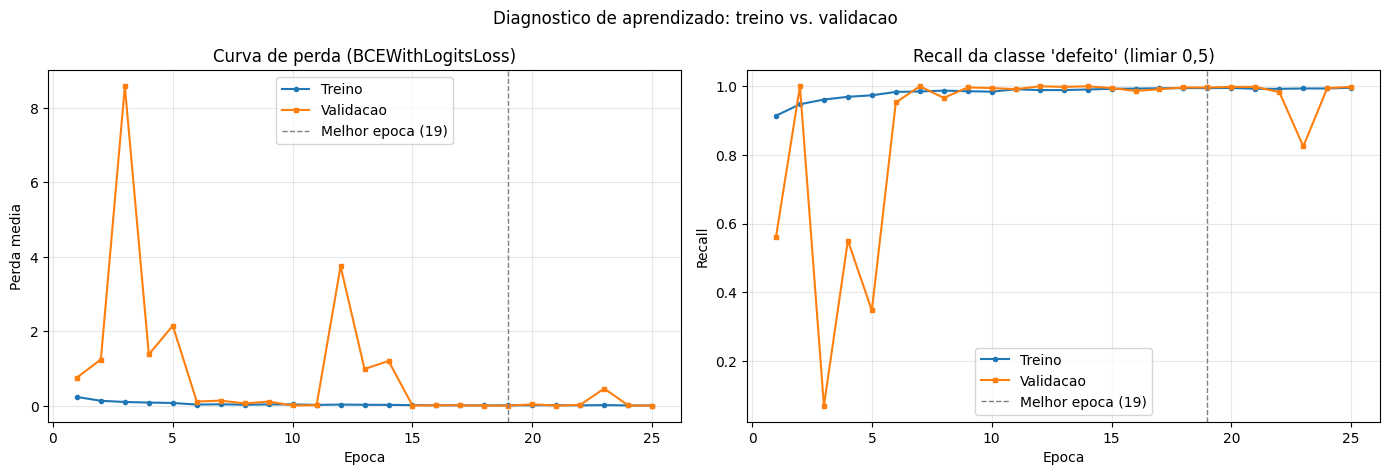

In [ ]:
# ============================================================
# CURVAS DE APRENDIZADO
# ============================================================

epocas_eixo = range(1, len(historico["loss_treino"]) + 1)

fig, eixos = plt.subplots(1, 2, figsize=(14, 4.8))

eixos[0].plot(epocas_eixo, historico["loss_treino"], marker="o", ms=3, label="Treino")
eixos[0].plot(epocas_eixo, historico["loss_val"], marker="s", ms=3, label="Validacao")
eixos[0].axvline(melhor_epoca, color="gray", ls="--", lw=1,
                 label=f"Melhor epoca ({melhor_epoca})")
eixos[0].set_title("Curva de perda (BCEWithLogitsLoss)")
eixos[0].set_xlabel("Epoca")
eixos[0].set_ylabel("Perda media")
eixos[0].legend()
eixos[0].grid(alpha=0.3)

eixos[1].plot(epocas_eixo, historico["recall_treino"], marker="o", ms=3, label="Treino")
eixos[1].plot(epocas_eixo, historico["recall_val"], marker="s", ms=3, label="Validacao")
eixos[1].axvline(melhor_epoca, color="gray", ls="--", lw=1,
                 label=f"Melhor epoca ({melhor_epoca})")
eixos[1].set_title("Recall da classe 'defeito' (limiar 0,5)")
eixos[1].set_xlabel("Epoca")
eixos[1].set_ylabel("Recall")
eixos[1].legend()
eixos[1].grid(alpha=0.3)

plt.suptitle("Diagnostico de aprendizado: treino vs. validacao")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CLASSIFICAÇÃO AUTOMÁTICA DO REGIME DE AJUSTE (regras explícitas)
# ============================================================
# Regras documentadas — qualquer pessoa pode conferir e discordar delas.
#   R1. lacuna = loss_val(melhor) - loss_treino(melhor)
#   R2. tendencia = loss_val(final) - loss_val(melhor)
#   R3. posicao relativa da melhor epoca dentro do treino

LIMIAR_LACUNA = 0.10        # diferenca absoluta de loss considerada grande
LIMIAR_TENDENCIA = 0.05     # subida da loss de validacao apos o minimo
LIMIAR_LOSS_ALTA = 0.35     # loss de treino ainda alta => modelo nao aprendeu o suficiente

i_melhor = melhor_epoca - 1
loss_treino_melhor = historico["loss_treino"][i_melhor]
loss_val_melhor = historico["loss_val"][i_melhor]
loss_val_final = historico["loss_val"][-1]
n_epocas_rodadas = len(historico["loss_treino"])

lacuna = loss_val_melhor - loss_treino_melhor
tendencia = loss_val_final - loss_val_melhor
posicao_melhor = melhor_epoca / n_epocas_rodadas

print("📐 Medidas do diagnostico")
print(f"   R1 lacuna (val - treino) na melhor epoca : {lacuna:+.4f}")
print(f"   R2 subida da loss de val apos o minimo   : {tendencia:+.4f}")
print(f"   R3 melhor epoca / epocas rodadas         : {melhor_epoca}/{n_epocas_rodadas} "
      f"= {posicao_melhor:.2f}")
print(f"   loss de treino na melhor epoca           : {loss_treino_melhor:.4f}")

if loss_treino_melhor > LIMIAR_LOSS_ALTA and lacuna < LIMIAR_LACUNA:
    DIAGNOSTICO = "UNDERFITTING"
    RECOMENDACAO = ("aumentar a capacidade (mais blocos ou mais filtros), treinar mais "
                    "epocas, reduzir dropout ou elevar a taxa de aprendizado inicial.")
elif lacuna > LIMIAR_LACUNA or tendencia > LIMIAR_TENDENCIA:
    DIAGNOSTICO = "OVERFITTING"
    RECOMENDACAO = ("reforcar a regularizacao (dropout maior, weight_decay maior, "
                    "augmentation mais forte) ou reduzir a capacidade do modelo.")
else:
    DIAGNOSTICO = "AJUSTE SAUDAVEL"
    RECOMENDACAO = ("o regime esta equilibrado. Proximos ganhos virao de resolucao maior, "
                    "transfer learning ou mais dados reais — nao de mais epocas.")

if posicao_melhor > 0.9 and DIAGNOSTICO != "OVERFITTING":
    RECOMENDACAO += (" Observacao: a melhor epoca foi uma das ultimas, entao o treino "
                     "pode ter sido interrompido cedo demais; vale aumentar EPOCAS.")

print(f"\n🔍 DIAGNOSTICO: {DIAGNOSTICO}")
print(f"💡 RECOMENDACAO: {RECOMENDACAO}")

📐 Medidas do diagnostico
   R1 lacuna (val - treino) na melhor epoca : -0.0120
   R2 subida da loss de val apos o minimo   : +0.0017
   R3 melhor epoca / epocas rodadas         : 19/25 = 0.76
   loss de treino na melhor epoca           : 0.0215

🔍 DIAGNOSTICO: AJUSTE SAUDAVEL
💡 RECOMENDACAO: o regime esta equilibrado. Proximos ganhos virao de resolucao maior, transfer learning ou mais dados reais — nao de mais epocas.


### 8.1 Tabela de referência

| Sintoma nas curvas | Diagnóstico | Ação |
|---|---|---|
| Loss de treino e de validação altas e juntas | Underfitting | Mais capacidade, mais épocas, menos regularização |
| Loss de treino cai, loss de validação sobe | Overfitting | Mais augmentation, mais dropout/weight decay, menos capacidade |
| Ambas caem e se estabilizam próximas | Ajuste saudável | Buscar ganhos em resolução, arquitetura ou dados |
| Loss de validação oscila muito entre épocas | Batch pequeno ou LR alto | Reduzir LR, aumentar batch, confiar no `ReduceLROnPlateau` |
| Validação melhor que treino | Regularização forte demais ou conjunto de validação fácil | Reduzir dropout; reauditar o split |
| Recall trava num patamar enquanto a loss melhora | Efeito do limiar fixo em 0,5 | Não é problema: o limiar será escolhido na seção 11 |

### ✍️ Interpretação (preencher após executar)

1. O diagnóstico impresso pelo código bate com o que você vê nas curvas? Se não, qual regra está mal calibrada para este problema?
2. A melhor época ficou no meio ou no fim do treino? O que isso diz sobre o orçamento de 25 épocas?
3. A curva de recall na validação é mais irregular que a de loss. Por quê — e por que isso justifica monitorar a loss no early stopping?

> 💬 **Para discutir:** se a lacuna entre treino e validação fosse praticamente zero e a loss de ambas ainda fosse alta, faria sentido comprar mais dados?

---

## 9. 📊 Avaliação no conjunto de teste

> 🧭 **O que estamos fazendo?** Passando o conjunto de teste pelo modelo **uma única vez**, guardando as probabilidades e calculando as métricas com o limiar padrão de 0,5 como referência.
> 🎯 **Por que é necessário?** É a única estimativa honesta de desempenho em peças que o modelo nunca viu — nem elas, nem quase-duplicatas delas.
> 🚫 **E se pulássemos?** Reportaríamos a validação como se fosse desempenho final, mas a validação já foi usada para parar o treino e ajustar o LR: ela está contaminada por essas decisões.

> ⚠️ **Uma vez significa uma vez.** As probabilidades calculadas nesta célula (`prob_teste`) são reaproveitadas nas seções 10 e 11. Em nenhum momento voltamos ao teste para escolher parâmetro.

> 💡 **Limiar** = valor de corte aplicado à probabilidade para decidir a classe. 0,5 não é uma lei da natureza; é o padrão implícito de quem usa `argmax`. A escolha justificada vem na seção 11.

In [ ]:
# ============================================================
# INFERÊNCIA NO TESTE (ÚNICA PASSAGEM) + MÉTRICAS COM LIMIAR 0,5
# ============================================================

loss_teste, prob_teste, alvo_teste = avaliar(modelo, loader_teste, criterio, DISPOSITIVO)
assert np.array_equal(alvo_teste, y_teste), "Ordem dos rotulos do teste divergiu."

LIMIAR_PADRAO = CONFIG["LIMIAR_PADRAO"]
pred_teste_padrao = (prob_teste >= LIMIAR_PADRAO).astype(int)

AUC_TESTE = roc_auc_score(alvo_teste, prob_teste)
RECALL_TESTE_PADRAO = recall_score(alvo_teste, pred_teste_padrao, zero_division=0)

print(f"📊 Conjunto de teste: {len(alvo_teste)} imagens "
      f"({int(alvo_teste.sum())} defeito / {int((1 - alvo_teste).sum())} ok)")
print(f"   Loss de teste: {loss_teste:.4f}\n")
print(f"🎯 Recall da classe 'defeito' (limiar {LIMIAR_PADRAO}): {RECALL_TESTE_PADRAO:.4f}")
print(f"   AUC-ROC: {AUC_TESTE:.4f}\n")

print("📋 Relatorio de classificacao (limiar 0,5)")
# labels=[0, 1] fixa as duas classes explicitamente: sem isso, o relatorio infere
# as classes presentes em y_true/y_pred e quebra se uma classe nao aparecer
# (por exemplo, num teste pequeno ou 100% de uma classe).
print(classification_report(alvo_teste, pred_teste_padrao, labels=[0, 1],
                            target_names=NOMES_CLASSES, digits=4, zero_division=0))

📊 Conjunto de teste: 1039 imagens (612 defeito / 427 ok)
   Loss de teste: 0.0152

🎯 Recall da classe 'defeito' (limiar 0.5): 0.9951
   AUC-ROC: 0.9994

📋 Relatorio de classificacao (limiar 0,5)
              precision    recall  f1-score   support

          ok     0.9930    1.0000    0.9965       427
     defeito     1.0000    0.9951    0.9975       612

    accuracy                         0.9971      1039
   macro avg     0.9965    0.9975    0.9970      1039
weighted avg     0.9971    0.9971    0.9971      1039



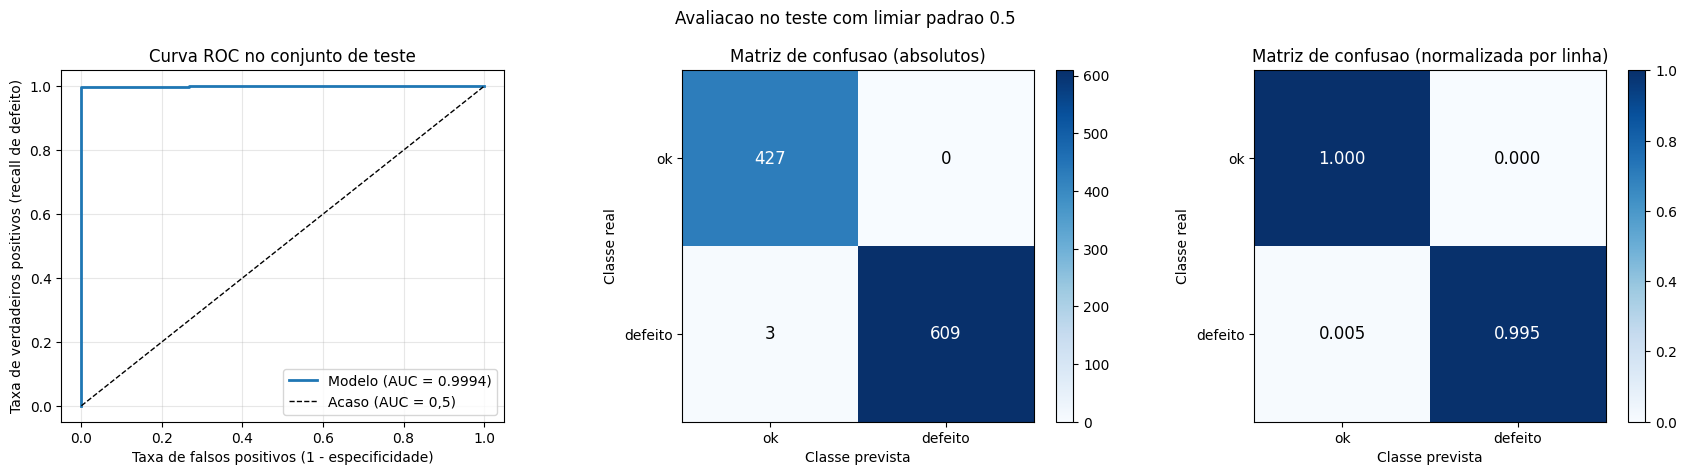

   Verdadeiros negativos (ok  -> ok)      : 427
   Falsos positivos      (ok  -> defeito) : 0   <- reinspecao desnecessaria
   Falsos negativos      (def -> ok)      : 3   <- ERRO CARO: defeito expedido
   Verdadeiros positivos (def -> defeito) : 609


In [ ]:
# ============================================================
# CURVA ROC E MATRIZ DE CONFUSÃO (absoluta e normalizada)
# ============================================================

fpr, tpr, _ = roc_curve(alvo_teste, prob_teste)
matriz = confusion_matrix(alvo_teste, pred_teste_padrao, labels=[0, 1])
matriz_norm = matriz / matriz.sum(axis=1, keepdims=True)

fig, eixos = plt.subplots(1, 3, figsize=(17, 4.8))

eixos[0].plot(fpr, tpr, lw=2, label=f"Modelo (AUC = {AUC_TESTE:.4f})")
eixos[0].plot([0, 1], [0, 1], "k--", lw=1, label="Acaso (AUC = 0,5)")
eixos[0].set_title("Curva ROC no conjunto de teste")
eixos[0].set_xlabel("Taxa de falsos positivos (1 - especificidade)")
eixos[0].set_ylabel("Taxa de verdadeiros positivos (recall de defeito)")
eixos[0].legend(loc="lower right")
eixos[0].grid(alpha=0.3)

for eixo, dados, titulo, formato in [
    (eixos[1], matriz, "Matriz de confusao (absolutos)", "d"),
    (eixos[2], matriz_norm, "Matriz de confusao (normalizada por linha)", ".3f"),
]:
    imagem = eixo.imshow(dados, cmap="Blues")
    eixo.set_xticks([0, 1], NOMES_CLASSES)
    eixo.set_yticks([0, 1], NOMES_CLASSES)
    eixo.set_xlabel("Classe prevista")
    eixo.set_ylabel("Classe real")
    eixo.set_title(titulo)
    limite = dados.max() / 2
    for i in range(2):
        for j in range(2):
            eixo.text(j, i, format(dados[i, j], formato), ha="center", va="center",
                      color="white" if dados[i, j] > limite else "black", fontsize=12)
    fig.colorbar(imagem, ax=eixo, fraction=0.046)

plt.suptitle(f"Avaliacao no teste com limiar padrao {LIMIAR_PADRAO}")
plt.tight_layout()
plt.show()

vn, fp, fn, vp = matriz.ravel()
print(f"   Verdadeiros negativos (ok  -> ok)      : {vn}")
print(f"   Falsos positivos      (ok  -> defeito) : {fp}   <- reinspecao desnecessaria")
print(f"   Falsos negativos      (def -> ok)      : {fn}   <- ERRO CARO: defeito expedido")
print(f"   Verdadeiros positivos (def -> defeito) : {vp}")

In [ ]:
# ============================================================
# INTERVALOS DE CONFIANÇA DE 95% POR BOOTSTRAP
# ============================================================
# Bootstrap: reamostrar o teste COM reposição mil vezes e recalcular a métrica.
# A dispersão dos mil valores estima a incerteza da métrica pontual.

def intervalo_bootstrap(alvos, probabilidades, limiar, n_reamostragens, semente):
    """Devolve os percentis 2,5 e 97,5 de recall e AUC sob reamostragem do conjunto."""
    gerador = np.random.default_rng(semente)
    recalls, aucs = [], []
    n = len(alvos)
    for _ in range(n_reamostragens):
        indices = gerador.integers(0, n, n)
        a, p = alvos[indices], probabilidades[indices]
        if a.sum() == 0 or a.sum() == n:
            continue
        recalls.append(recall_score(a, (p >= limiar).astype(int), zero_division=0))
        aucs.append(roc_auc_score(a, p))
    return (np.percentile(recalls, [2.5, 97.5]), np.percentile(aucs, [2.5, 97.5]))


ic_recall, ic_auc = intervalo_bootstrap(
    alvo_teste, prob_teste, LIMIAR_PADRAO, CONFIG["N_BOOTSTRAP"], SEED
)

print(f"📏 Intervalos de confianca de 95% ({CONFIG['N_BOOTSTRAP']} reamostragens)\n")
print(f"   Recall 'defeito' : {RECALL_TESTE_PADRAO:.4f}  "
      f"IC95% [{ic_recall[0]:.4f}, {ic_recall[1]:.4f}]")
print(f"   AUC-ROC          : {AUC_TESTE:.4f}  "
      f"IC95% [{ic_auc[0]:.4f}, {ic_auc[1]:.4f}]")

print(f"\n💡 O recall no teste foi estimado a partir de apenas {fn} falso(s) negativo(s)")
print(f"   em {int(alvo_teste.sum())} pecas defeituosas. Com tao poucos erros, tirar ou")
print("   acrescentar um unico caso muda bastante o numero — por isso o intervalo e largo.")
print("   Reportar so o valor pontual esconde essa incerteza.")

📏 Intervalos de confianca de 95% (1000 reamostragens)

   Recall 'defeito' : 0.9951  IC95% [0.9886, 1.0000]
   AUC-ROC          : 0.9994  IC95% [0.9982, 1.0000]

💡 O recall no teste foi estimado a partir de apenas 3 falso(s) negativo(s)
   em 612 pecas defeituosas. Com tao poucos erros, tirar ou
   acrescentar um unico caso muda bastante o numero — por isso o intervalo e largo.
   Reportar so o valor pontual esconde essa incerteza.


In [ ]:
# ============================================================
# COMPARAÇÃO COM OS BASELINES DA SEÇÃO 5
# ============================================================

acuracia_teste = accuracy_score(alvo_teste, pred_teste_padrao)
precisao_teste = precision_score(alvo_teste, pred_teste_padrao, zero_division=0)
f1_macro_teste = f1_score(alvo_teste, pred_teste_padrao, average="macro", zero_division=0)
especificidade_teste = recall_score(alvo_teste, pred_teste_padrao, pos_label=0, zero_division=0)

comparacao = pd.DataFrame([
    {"modelo": "Baseline majoritario (val)", "acuracia": base_majoritaria["acuracia"],
     "recall_defeito": base_majoritaria["recall"], "precisao_defeito": base_majoritaria["precisao"],
     "AUC": base_majoritaria["auc"]},
    {"modelo": "Regressao logistica (val)", "acuracia": base_regressao["acuracia"],
     "recall_defeito": base_regressao["recall"], "precisao_defeito": base_regressao["precisao"],
     "AUC": base_regressao["auc"]},
    {"modelo": "CNN residual (TESTE, limiar 0,5)", "acuracia": acuracia_teste,
     "recall_defeito": RECALL_TESTE_PADRAO, "precisao_defeito": precisao_teste,
     "AUC": AUC_TESTE},
])

print("📊 Modelo x baselines\n")
print(comparacao.round(4).to_string(index=False))

ganho_recall = RECALL_TESTE_PADRAO - base_regressao["recall"]
print(f"\n   Ganho de recall sobre a regressao logistica: {ganho_recall:+.4f}")
print(f"   F1-macro da CNN no teste: {f1_macro_teste:.4f} | "
      f"especificidade: {especificidade_teste:.4f}")
print("\n   ⚠️ Comparacao imperfeita de proposito: os baselines foram medidos na")
print("      VALIDACAO e a CNN no TESTE, porque o teste so pode ser aberto uma vez.")
print("      Os conjuntos vieram do mesmo split agrupado, entao a comparacao e indicativa.")

📊 Modelo x baselines

                          modelo  acuracia  recall_defeito  precisao_defeito    AUC
      Baseline majoritario (val)    0.5690          1.0000            0.5690    NaN
       Regressao logistica (val)    0.9100          0.9074            0.9325 0.9595
CNN residual (TESTE, limiar 0,5)    0.9971          0.9951            1.0000 0.9994

   Ganho de recall sobre a regressao logistica: +0.0877
   F1-macro da CNN no teste: 0.9970 | especificidade: 1.0000

   ⚠️ Comparacao imperfeita de proposito: os baselines foram medidos na
      VALIDACAO e a CNN no TESTE, porque o teste so pode ser aberto uma vez.
      Os conjuntos vieram do mesmo split agrupado, entao a comparacao e indicativa.


> 💬 **Para discutir:** se o baseline de regressão logística já tivesse AUC de 0,97, valeria a pena colocar uma CNN em produção? Que outros critérios além da métrica entram nessa decisão?

---

## 10. 🔎 Análise de erros

> 🧭 **O que estamos fazendo?** Olhando as imagens em que o modelo errou **com mais confiança**, separando falsos negativos de falsos positivos, medindo o recall por faixa de brilho e abrindo a "caixa-preta" com Grad-CAM.
> 🎯 **Por que é necessário?** Uma métrica agregada diz *quanto* o modelo erra; a análise de erros diz *onde* e *por quê*. Erro aleatório se resolve com mais dados; erro sistemático se resolve mudando o processo.
> 🚫 **E se pulássemos?** Entregaríamos um modelo com um ponto cego desconhecido — por exemplo, falhando justamente nas peças mais escuras.

❌ Falsos negativos (defeito classificado como ok) : 3
⚠️ Falsos positivos (ok classificado como defeito) : 0


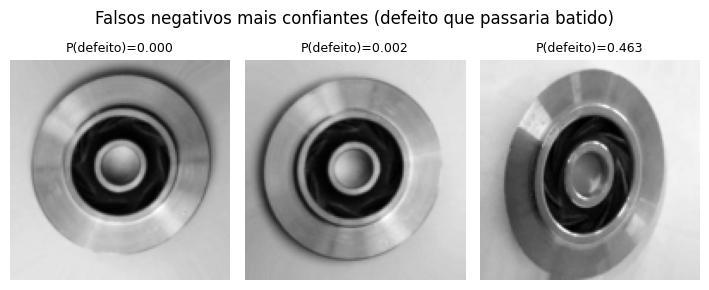

ℹ️ Nenhum caso em 'Falsos positivos mais confiantes (peca boa mandada a reinspecao)'.


In [ ]:
# ============================================================
# OS PIORES ERROS: FALSOS NEGATIVOS E FALSOS POSITIVOS
# ============================================================
# Ordenamos pela confiança do erro: um falso negativo com probabilidade 0,02
# é muito mais preocupante que um com 0,49.

indices_fn = np.where((alvo_teste == 1) & (prob_teste < LIMIAR_PADRAO))[0]
indices_fp = np.where((alvo_teste == 0) & (prob_teste >= LIMIAR_PADRAO))[0]

piores_fn = indices_fn[np.argsort(prob_teste[indices_fn])][: CONFIG["N_ERROS_MOSTRAR"]]
piores_fp = indices_fp[np.argsort(-prob_teste[indices_fp])][: CONFIG["N_ERROS_MOSTRAR"]]

print(f"❌ Falsos negativos (defeito classificado como ok) : {len(indices_fn)}")
print(f"⚠️ Falsos positivos (ok classificado como defeito) : {len(indices_fp)}")


def mostrar_erros(indices, titulo):
    """Exibe uma fileira de imagens de teste com a probabilidade prevista no título."""
    if len(indices) == 0:
        print(f"ℹ️ Nenhum caso em '{titulo}'.")
        return
    n = len(indices)
    fig, eixos = plt.subplots(1, n, figsize=(2.4 * n, 3.0))
    eixos = np.atleast_1d(eixos)
    for posicao, indice in enumerate(indices):
        eixos[posicao].imshow(img_teste[indice], cmap="gray")
        eixos[posicao].axis("off")
        eixos[posicao].set_title(f"P(defeito)={prob_teste[indice]:.3f}", fontsize=9)
    plt.suptitle(titulo)
    plt.tight_layout()
    plt.show()


mostrar_erros(piores_fn, "Falsos negativos mais confiantes (defeito que passaria batido)")
mostrar_erros(piores_fp, "Falsos positivos mais confiantes (peca boa mandada a reinspecao)")

📊 Desempenho por faixa de brilho medio (conjunto de teste)

     faixa_brilho  n_imagens  n_defeito  recall_defeito  especificidade  brilho_medio
Q1 (mais escuras)        260        246          0.9959             1.0      133.3844
               Q2        260        202          1.0000             1.0      139.7133
               Q3        259        143          1.0000             1.0      145.7968
 Q4 (mais claras)        260         21          0.9048             1.0      154.0830


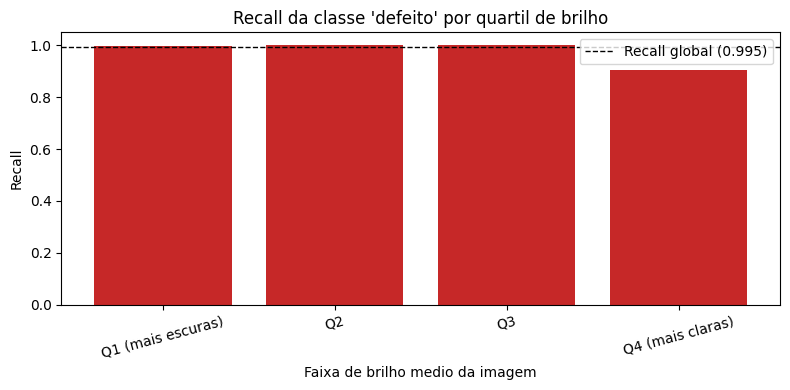


   Amplitude do recall entre quartis: 0.0952
   ⚠️ Diferenca relevante: ha indicio de erro SISTEMATICO ligado a iluminacao.
      Acao sugerida: augmentation de brilho/contraste ou padronizacao da luz na linha.


In [ ]:
# ============================================================
# ERROS SÃO ALEATÓRIOS OU SISTEMÁTICOS? RECALL POR QUARTIL DE BRILHO
# ============================================================
# Se o recall despencar num quartil específico, existe uma subpopulação
# (por exemplo, peças fotografadas com menos luz) em que o modelo falha mais.

brilho_teste = img_teste.reshape(len(img_teste), -1).mean(axis=1)
quartis = pd.qcut(brilho_teste, 4, labels=["Q1 (mais escuras)", "Q2", "Q3",
                                           "Q4 (mais claras)"])

linhas = []
for faixa in quartis.categories:
    mascara = np.asarray(quartis == faixa)
    a, p = alvo_teste[mascara], pred_teste_padrao[mascara]
    linhas.append({
        "faixa_brilho": faixa,
        "n_imagens": int(mascara.sum()),
        "n_defeito": int(a.sum()),
        "recall_defeito": recall_score(a, p, zero_division=0) if a.sum() > 0 else np.nan,
        "especificidade": recall_score(a, p, pos_label=0, zero_division=0)
                          if (a == 0).sum() > 0 else np.nan,
        "brilho_medio": float(brilho_teste[mascara].mean()),
    })

df_quartis = pd.DataFrame(linhas)
print("📊 Desempenho por faixa de brilho medio (conjunto de teste)\n")
print(df_quartis.round(4).to_string(index=False))

fig, eixo = plt.subplots(figsize=(8, 4))
eixo.bar(df_quartis["faixa_brilho"].astype(str), df_quartis["recall_defeito"],
         color="#c62828")
eixo.axhline(RECALL_TESTE_PADRAO, color="black", ls="--", lw=1,
             label=f"Recall global ({RECALL_TESTE_PADRAO:.3f})")
eixo.set_title("Recall da classe 'defeito' por quartil de brilho")
eixo.set_xlabel("Faixa de brilho medio da imagem")
eixo.set_ylabel("Recall")
eixo.set_ylim(0, 1.05)
eixo.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

amplitude = df_quartis["recall_defeito"].max() - df_quartis["recall_defeito"].min()
print(f"\n   Amplitude do recall entre quartis: {amplitude:.4f}")
if amplitude > 0.05:
    print("   ⚠️ Diferenca relevante: ha indicio de erro SISTEMATICO ligado a iluminacao.")
    print("      Acao sugerida: augmentation de brilho/contraste ou padronizacao da luz na linha.")
else:
    print("   ✅ Recall estavel entre as faixas: os erros parecem ALEATORIOS, nao")
    print("      concentrados numa subpopulacao de iluminacao.")

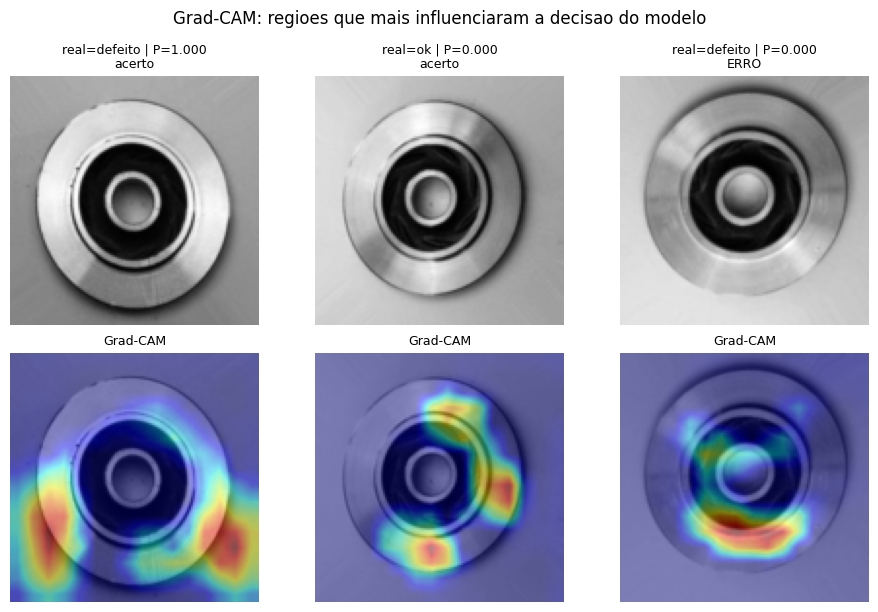

👀 Leitura: o calor deve cair sobre a peça (anel externo, pás, superfície),
   e não sobre o fundo preto. Calor no fundo indica que o modelo encontrou
   um atalho no enquadramento em vez de olhar o defeito.


In [ ]:
# ============================================================
# GRAD-CAM: ONDE O MODELO ESTÁ OLHANDO?
# ============================================================
# Grad-CAM pondera os mapas de ativação do último bloco convolucional pelo
# gradiente do logit, revelando as regiões que mais influenciaram a decisão.

def grad_cam(modelo, tensor_entrada, camada_alvo):
    """Devolve o mapa de calor Grad-CAM (H x W, normalizado em 0-1) e a probabilidade prevista."""
    ativacoes, gradientes = {}, {}

    def gancho_adiante(_modulo, _entrada, saida):
        ativacoes["valor"] = saida
        saida.register_hook(lambda g: gradientes.__setitem__("valor", g))

    alca = camada_alvo.register_forward_hook(gancho_adiante)
    modelo.eval()
    modelo.zero_grad(set_to_none=True)

    logit = modelo(tensor_entrada)
    logit.backward(torch.ones_like(logit))
    alca.remove()

    a = ativacoes["valor"].detach()[0]
    g = gradientes["valor"].detach()[0]
    pesos = g.mean(dim=(1, 2))
    mapa = F.relu((pesos[:, None, None] * a).sum(dim=0))
    mapa = mapa / (mapa.max() + 1e-8)
    mapa = F.interpolate(mapa[None, None], size=(IMG_SIZE, IMG_SIZE),
                         mode="bilinear", align_corners=False)[0, 0]
    return mapa.cpu().numpy(), torch.sigmoid(logit.detach()).item()


if CONFIG["EXECUTAR_GRADCAM"]:
    camada_alvo = modelo.blocos[-1]

    # Um acerto de cada classe e, se existirem, os piores erros
    acerto_defeito = np.where((alvo_teste == 1) & (pred_teste_padrao == 1))[0][:1]
    acerto_ok = np.where((alvo_teste == 0) & (pred_teste_padrao == 0))[0][:1]
    selecionados = list(acerto_defeito) + list(acerto_ok) + list(piores_fn[:1]) + list(piores_fp[:1])

    fig, eixos = plt.subplots(2, len(selecionados), figsize=(3.1 * len(selecionados), 6.2))
    eixos = np.atleast_2d(eixos)
    for coluna, indice in enumerate(selecionados):
        entrada = torch.from_numpy(img_teste[indice]).unsqueeze(0).unsqueeze(0).float() / 255.0
        entrada = transformacoes_avaliacao(entrada[0]).unsqueeze(0).to(DISPOSITIVO)
        entrada.requires_grad_(True)

        mapa, probabilidade = grad_cam(modelo, entrada, camada_alvo)
        real = MAPA_CLASSES[int(alvo_teste[indice])]
        acertou = (probabilidade >= LIMIAR_PADRAO) == bool(alvo_teste[indice])

        eixos[0, coluna].imshow(img_teste[indice], cmap="gray")
        eixos[0, coluna].set_title(f"real={real} | P={probabilidade:.3f}\n"
                                   f"{'acerto' if acertou else 'ERRO'}", fontsize=9)
        eixos[0, coluna].axis("off")

        eixos[1, coluna].imshow(img_teste[indice], cmap="gray")
        eixos[1, coluna].imshow(mapa, cmap="jet", alpha=0.45)
        eixos[1, coluna].set_title("Grad-CAM", fontsize=9)
        eixos[1, coluna].axis("off")

    plt.suptitle("Grad-CAM: regioes que mais influenciaram a decisao do modelo")
    plt.tight_layout()
    plt.show()

    print("👀 Leitura: o calor deve cair sobre a peça (anel externo, pás, superfície),")
    print("   e não sobre o fundo preto. Calor no fundo indica que o modelo encontrou")
    print("   um atalho no enquadramento em vez de olhar o defeito.")
else:
    print("ℹ️ Grad-CAM desativado em CONFIG['EXECUTAR_GRADCAM'].")

🔬 Similaridade de cosseno ao vizinho mais proximo do treino
   mediana: 0.9999 | maxima: 1.0000


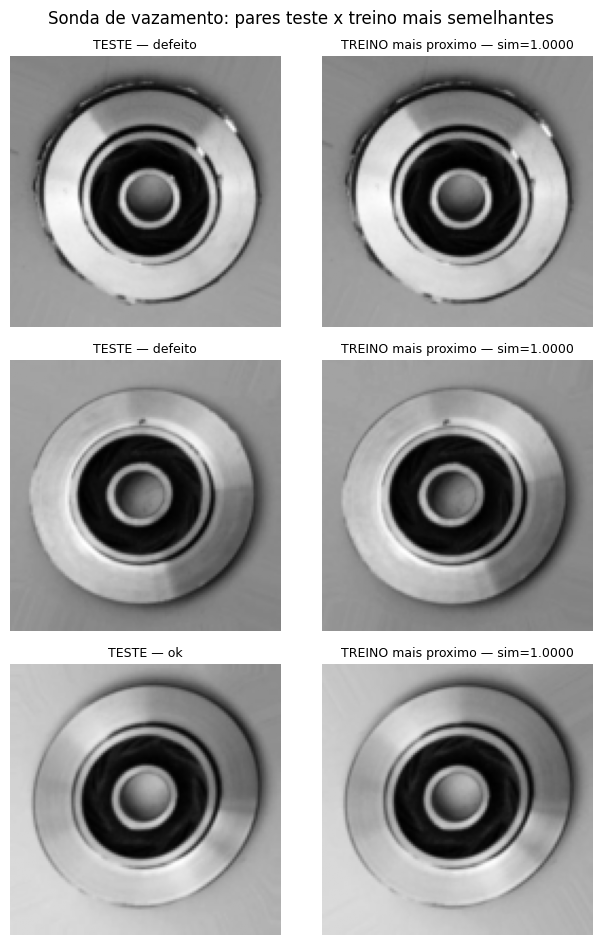


   💡 Similaridade alta NAO prova vazamento: peças do mesmo molde são
      parecidas por natureza, e o embedding foi treinado para aproximar
      imagens da mesma classe. A sonda serve para inspeção visual, não como prova.


In [ ]:
# ============================================================
# SONDA DE VAZAMENTO (opcional): pares teste x treino mais parecidos
# ============================================================
# Usa os embeddings de 256 dimensões (saída do pooling global) para encontrar
# as imagens de teste mais próximas de alguma imagem de treino. Se aparecerem
# pares visualmente idênticos, sobrou vazamento que o pHash não pegou.

@torch.no_grad()
def extrair_embeddings(modelo, imagens, lote=256):
    """Extrai o vetor de 256 dimensões anterior ao classificador."""
    modelo.eval()
    saidas = []
    for comeco in range(0, len(imagens), lote):
        bloco = imagens[comeco:comeco + lote]
        tensor = torch.from_numpy(bloco).unsqueeze(1).float().div(255.0)
        tensor = torch.stack([transformacoes_avaliacao(t) for t in tensor]).to(DISPOSITIVO)
        x = modelo.stem(tensor)
        x = modelo.blocos(x)
        saidas.append(modelo.pool(x).flatten(1).cpu().numpy())
    return np.concatenate(saidas)


emb_treino = extrair_embeddings(modelo, img_treino)
emb_teste = extrair_embeddings(modelo, img_teste)

emb_treino_n = emb_treino / (np.linalg.norm(emb_treino, axis=1, keepdims=True) + 1e-8)
emb_teste_n = emb_teste / (np.linalg.norm(emb_teste, axis=1, keepdims=True) + 1e-8)

similaridades = emb_teste_n @ emb_treino_n.T
vizinho = similaridades.argmax(axis=1)
sim_maxima = similaridades.max(axis=1)

print(f"🔬 Similaridade de cosseno ao vizinho mais proximo do treino")
print(f"   mediana: {np.median(sim_maxima):.4f} | maxima: {sim_maxima.max():.4f}")

mais_suspeitos = np.argsort(-sim_maxima)[:3]
fig, eixos = plt.subplots(len(mais_suspeitos), 2, figsize=(6.5, 3.2 * len(mais_suspeitos)))
eixos = np.atleast_2d(eixos)
for linha, indice_teste in enumerate(mais_suspeitos):
    indice_treino = vizinho[indice_teste]
    eixos[linha, 0].imshow(img_teste[indice_teste], cmap="gray")
    eixos[linha, 0].set_title(f"TESTE — {MAPA_CLASSES[int(alvo_teste[indice_teste])]}", fontsize=9)
    eixos[linha, 1].imshow(img_treino[indice_treino], cmap="gray")
    eixos[linha, 1].set_title(f"TREINO mais proximo — sim={sim_maxima[indice_teste]:.4f}",
                              fontsize=9)
    eixos[linha, 0].axis("off")
    eixos[linha, 1].axis("off")
plt.suptitle("Sonda de vazamento: pares teste x treino mais semelhantes")
plt.tight_layout()
plt.show()

print("\n   💡 Similaridade alta NAO prova vazamento: peças do mesmo molde são")
print("      parecidas por natureza, e o embedding foi treinado para aproximar")
print("      imagens da mesma classe. A sonda serve para inspeção visual, não como prova.")

> 💬 **Para discutir:** olhando o Grad-CAM dos falsos negativos, o modelo estava olhando o lugar certo e não viu o defeito, ou estava olhando o lugar errado? A ação corretiva é diferente em cada caso.

---

## 11. 💰 Tradução para impacto de negócio

> 🧭 **O que estamos fazendo?** Atribuindo um custo em reais a cada tipo de erro, varrendo todos os limiares possíveis **na validação**, escolhendo o que minimiza o custo respeitando a meta de recall, e só então aplicando esse limiar ao teste.
> 🎯 **Por que é necessário?** Ninguém na fábrica decide nada com base em "AUC 0,99". A pergunta real é: quantas peças ruins escapam por mil, e quanto isso custa?
> 🚫 **E se pulássemos?** Ficaríamos com o limiar 0,5 — um valor que ninguém escolheu, que veio de graça com o `argmax`, e que trata um defeito expedido e uma reinspeção como se custassem a mesma coisa.

> ⚠️ **É proibido escolher o limiar olhando o teste.** O limiar é um parâmetro como qualquer outro: ajustado no teste, ele transforma a estimativa final em otimismo puro. A varredura acontece na validação; o teste recebe o número pronto, uma única vez.

In [ ]:
# ============================================================
# SUPOSIÇÕES DE CUSTO (EDITÁVEIS) E VARREDURA DE LIMIAR NA VALIDAÇÃO
# ============================================================
# ⚠️ Os valores abaixo são HIPOTÉTICOS, para fins didáticos. Numa aplicação
# real viriam do financeiro e da engenharia de qualidade.

CUSTO_FN = CONFIG["CUSTO_FN"]                 # defeito que chega ao cliente
CUSTO_FP = CONFIG["CUSTO_FP"]                 # reinspeção manual de peça boa
META_RECALL = CONFIG["META_RECALL"]           # recall mínimo exigido para 'defeito'

print("💰 Suposicoes de custo (editaveis)")
print(f"   CUSTO_FN    = R$ {CUSTO_FN:,.2f}  (falso negativo: defeito expedido)")
print(f"   CUSTO_FP    = R$ {CUSTO_FP:,.2f}  (falso positivo: reinspecao de peca boa)")
print(f"   Razao FN:FP = {CUSTO_FN / CUSTO_FP:.0f}:1")
print(f"   META_RECALL = {META_RECALL:.2f}\n")

# Probabilidades na VALIDAÇÃO com o modelo já restaurado
_, prob_val_final, alvo_val_final = avaliar(modelo, loader_val, criterio, DISPOSITIVO)

limiares = np.linspace(0.005, 0.995, 199)


def custos_por_limiar(alvos, probabilidades, grade, custo_fn, custo_fp):
    """Para cada limiar, devolve custo total, recall, precisão e especificidade."""
    registros = []
    for limiar in grade:
        predicoes = (probabilidades >= limiar).astype(int)
        vn, fp, fn, vp = confusion_matrix(alvos, predicoes, labels=[0, 1]).ravel()
        registros.append({
            "limiar": limiar,
            "FN": int(fn), "FP": int(fp), "VP": int(vp), "VN": int(vn),
            "custo": custo_fn * fn + custo_fp * fp,
            "recall": vp / (vp + fn) if (vp + fn) else np.nan,
            "precisao": vp / (vp + fp) if (vp + fp) else np.nan,
            "especificidade": vn / (vn + fp) if (vn + fp) else np.nan,
        })
    return pd.DataFrame(registros)


df_custos = custos_por_limiar(alvo_val_final, prob_val_final, limiares, CUSTO_FN, CUSTO_FP)

elegiveis = df_custos[df_custos["recall"] >= META_RECALL]
if len(elegiveis) > 0:
    melhor_linha = elegiveis.loc[elegiveis["custo"].idxmin()]
    motivo_escolha = f"menor custo entre os limiares com recall >= {META_RECALL:.2f}"
else:
    melhor_linha = df_custos.loc[df_custos["recall"].idxmax()]
    motivo_escolha = ("NENHUM limiar atingiu a meta de recall; escolhido o de maior recall")
    print(f"⚠️ Meta de recall {META_RECALL:.2f} inatingivel na validacao.")

LIMIAR_ESCOLHIDO = float(melhor_linha["limiar"])
custo_no_padrao = float(df_custos.iloc[(df_custos["limiar"] - 0.5).abs().idxmin()]["custo"])

print(f"🎯 Limiar escolhido (na VALIDACAO): {LIMIAR_ESCOLHIDO:.3f}")
print(f"   Criterio: {motivo_escolha}")
print(f"   Na validacao -> recall={melhor_linha['recall']:.4f} | "
      f"precisao={melhor_linha['precisao']:.4f} | "
      f"especificidade={melhor_linha['especificidade']:.4f}")
print(f"   Custo na validacao: R$ {melhor_linha['custo']:,.2f} "
      f"(contra R$ {custo_no_padrao:,.2f} com limiar 0,5)")
print(f"\n💡 Por que nao 0,5? Porque 0,5 pressupoe que um defeito expedido custa o mesmo")
print(f"   que uma reinspecao. Como o FN custa {CUSTO_FN / CUSTO_FP:.0f}x mais, compensa")
print(f"   deslocar o limiar para baixo: aceitamos mais reinspecoes para deixar passar")
print(f"   menos defeitos.")

💰 Suposicoes de custo (editaveis)
   CUSTO_FN    = R$ 500.00  (falso negativo: defeito expedido)
   CUSTO_FP    = R$ 5.00  (falso positivo: reinspecao de peca boa)
   Razao FN:FP = 100:1
   META_RECALL = 0.98

🎯 Limiar escolhido (na VALIDACAO): 0.060
   Criterio: menor custo entre os limiares com recall >= 0.98
   Na validacao -> recall=0.9983 | precisao=0.9983 | especificidade=0.9978
   Custo na validacao: R$ 505.00 (contra R$ 1,000.00 com limiar 0,5)

💡 Por que nao 0,5? Porque 0,5 pressupoe que um defeito expedido custa o mesmo
   que uma reinspecao. Como o FN custa 100x mais, compensa
   deslocar o limiar para baixo: aceitamos mais reinspecoes para deixar passar
   menos defeitos.


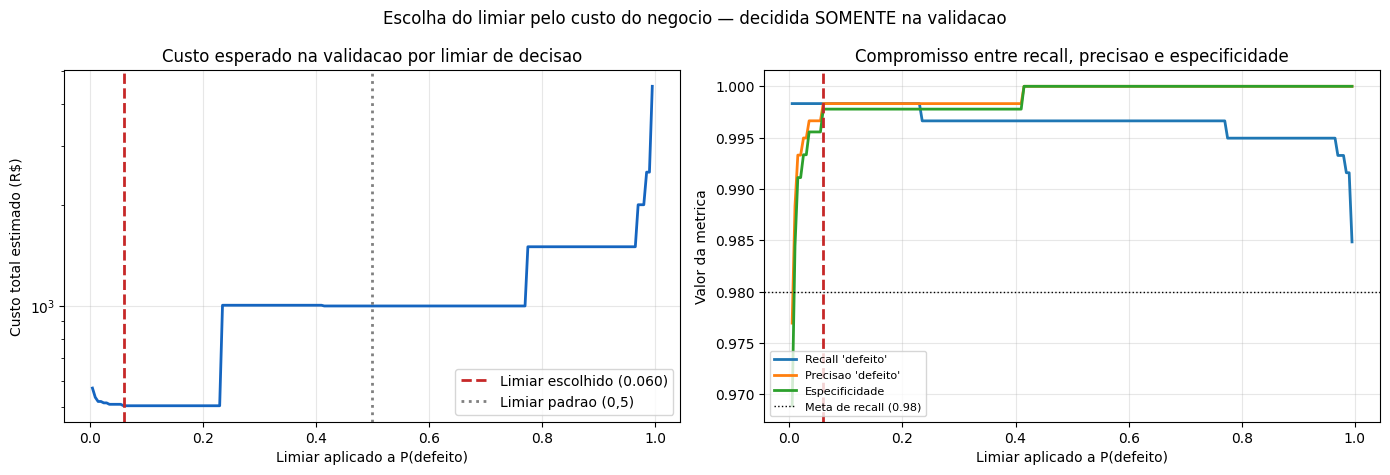

In [ ]:
# ============================================================
# CURVA DE CUSTO x LIMIAR (VALIDAÇÃO)
# ============================================================

fig, eixos = plt.subplots(1, 2, figsize=(14, 4.8))

eixos[0].plot(df_custos["limiar"], df_custos["custo"], lw=2, color="#1565c0")
eixos[0].axvline(LIMIAR_ESCOLHIDO, color="#c62828", ls="--", lw=2,
                 label=f"Limiar escolhido ({LIMIAR_ESCOLHIDO:.3f})")
eixos[0].axvline(0.5, color="gray", ls=":", lw=2, label="Limiar padrao (0,5)")
eixos[0].set_title("Custo esperado na validacao por limiar de decisao")
eixos[0].set_xlabel("Limiar aplicado a P(defeito)")
eixos[0].set_ylabel("Custo total estimado (R$)")
eixos[0].set_yscale("log")
eixos[0].legend()
eixos[0].grid(alpha=0.3)

eixos[1].plot(df_custos["limiar"], df_custos["recall"], lw=2, label="Recall 'defeito'")
eixos[1].plot(df_custos["limiar"], df_custos["precisao"], lw=2, label="Precisao 'defeito'")
eixos[1].plot(df_custos["limiar"], df_custos["especificidade"], lw=2, label="Especificidade")
eixos[1].axhline(META_RECALL, color="black", ls=":", lw=1,
                 label=f"Meta de recall ({META_RECALL:.2f})")
eixos[1].axvline(LIMIAR_ESCOLHIDO, color="#c62828", ls="--", lw=2)
eixos[1].set_title("Compromisso entre recall, precisao e especificidade")
eixos[1].set_xlabel("Limiar aplicado a P(defeito)")
eixos[1].set_ylabel("Valor da metrica")
eixos[1].legend(loc="lower left", fontsize=8)
eixos[1].grid(alpha=0.3)

plt.suptitle("Escolha do limiar pelo custo do negocio — decidida SOMENTE na validacao")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# APLICAÇÃO DO LIMIAR ESCOLHIDO AO TESTE (UMA ÚNICA VEZ)
# ============================================================
# Reutilizamos prob_teste, já calculado na seção 9. O teste não é reprocessado.

pred_teste_final = (prob_teste >= LIMIAR_ESCOLHIDO).astype(int)
vn_f, fp_f, fn_f, vp_f = confusion_matrix(alvo_teste, pred_teste_final, labels=[0, 1]).ravel()

RECALL_TESTE_FINAL = vp_f / (vp_f + fn_f) if (vp_f + fn_f) else np.nan
PRECISAO_TESTE_FINAL = vp_f / (vp_f + fp_f) if (vp_f + fp_f) else np.nan
ESPECIFICIDADE_TESTE_FINAL = vn_f / (vn_f + fp_f) if (vn_f + fp_f) else np.nan
ACURACIA_TESTE_FINAL = accuracy_score(alvo_teste, pred_teste_final)
CUSTO_TESTE_FINAL = CUSTO_FN * fn_f + CUSTO_FP * fp_f
CUSTO_TESTE_PADRAO = CUSTO_FN * fn + CUSTO_FP * fp

print(f"📊 Teste com o limiar escolhido ({LIMIAR_ESCOLHIDO:.3f}) vs. limiar padrao (0,5)\n")
cabecalho = f"{'Metrica':<22}{'limiar 0,5':>14}{'limiar escolhido':>20}"
print(cabecalho)
print("-" * len(cabecalho))
print(f"{'Recall defeito':<22}{RECALL_TESTE_PADRAO:>14.4f}{RECALL_TESTE_FINAL:>20.4f}")
print(f"{'Precisao defeito':<22}{precisao_teste:>14.4f}{PRECISAO_TESTE_FINAL:>20.4f}")
print(f"{'Especificidade':<22}{especificidade_teste:>14.4f}{ESPECIFICIDADE_TESTE_FINAL:>20.4f}")
print(f"{'Acuracia':<22}{acuracia_teste:>14.4f}{ACURACIA_TESTE_FINAL:>20.4f}")
print(f"{'Falsos negativos':<22}{fn:>14d}{fn_f:>20d}")
print(f"{'Falsos positivos':<22}{fp:>14d}{fp_f:>20d}")
print(f"{'Custo total (R$)':<22}{CUSTO_TESTE_PADRAO:>14,.2f}{CUSTO_TESTE_FINAL:>20,.2f}")
print("-" * len(cabecalho))
print(f"\n   Economia estimada no conjunto de teste: "
      f"R$ {CUSTO_TESTE_PADRAO - CUSTO_TESTE_FINAL:,.2f}")

ic_recall_final, _ = intervalo_bootstrap(
    alvo_teste, prob_teste, LIMIAR_ESCOLHIDO, CONFIG["N_BOOTSTRAP"], SEED
)
print(f"   Recall final: {RECALL_TESTE_FINAL:.4f} "
      f"IC95% [{ic_recall_final[0]:.4f}, {ic_recall_final[1]:.4f}]")
print(f"   Meta de recall {META_RECALL:.2f} "
      f"{'ATINGIDA ✅' if RECALL_TESTE_FINAL >= META_RECALL else 'NAO atingida ❌'} no teste.")

📊 Teste com o limiar escolhido (0.060) vs. limiar padrao (0,5)

Metrica                   limiar 0,5    limiar escolhido
--------------------------------------------------------
Recall defeito                0.9951              0.9967
Precisao defeito              1.0000              0.9935
Especificidade                1.0000              0.9906
Acuracia                      0.9971              0.9942
Falsos negativos                   3                   2
Falsos positivos                   0                   4
Custo total (R$)            1,500.00            1,020.00
--------------------------------------------------------

   Economia estimada no conjunto de teste: R$ 480.00
   Recall final: 0.9967 IC95% [0.9915, 1.0000]
   Meta de recall 0.98 ATINGIDA ✅ no teste.


In [ ]:
# ============================================================
# DOIS CENÁRIOS DE PREVALÊNCIA: O QUE ACONTECE POR 1.000 PEÇAS
# ============================================================
# Sensibilidade (recall) e especificidade NÃO dependem da prevalência; a
# precisão depende, e muito. Por isso projetamos os dois cenários.

SENSIBILIDADE = RECALL_TESTE_FINAL
ESPECIFICIDADE = ESPECIFICIDADE_TESTE_FINAL
PREVALENCIA_DATASET = float(alvo_teste.mean())
PREVALENCIA_PRODUCAO = CONFIG["PREVALENCIA_PRODUCAO"]


def projetar_por_mil(sensibilidade, especificidade, prevalencia, custo_fn, custo_fp, n=1000):
    """Projeta VP, FN, FP, VN, precisão e custo para n peças sob uma dada prevalência."""
    defeituosas = n * prevalencia
    boas = n * (1 - prevalencia)
    vp = defeituosas * sensibilidade
    fn_ = defeituosas * (1 - sensibilidade)
    vn_ = boas * especificidade
    fp_ = boas * (1 - especificidade)
    precisao = vp / (vp + fp_) if (vp + fp_) > 0 else np.nan
    return {
        "prevalencia": prevalencia, "VP": vp, "FN": fn_, "FP": fp_, "VN": vn_,
        "precisao": precisao, "pecas_reinspecionadas": vp + fp_,
        "custo": custo_fn * fn_ + custo_fp * fp_,
    }


cenarios = {
    f"Dataset ({100*PREVALENCIA_DATASET:.1f}% defeito)":
        projetar_por_mil(SENSIBILIDADE, ESPECIFICIDADE, PREVALENCIA_DATASET, CUSTO_FN, CUSTO_FP),
    f"Producao hipotetica ({100*PREVALENCIA_PRODUCAO:.1f}% defeito)":
        projetar_por_mil(SENSIBILIDADE, ESPECIFICIDADE, PREVALENCIA_PRODUCAO, CUSTO_FN, CUSTO_FP),
}

print(f"📦 Projecao por 1.000 pecas inspecionadas")
print(f"   sensibilidade={SENSIBILIDADE:.4f} | especificidade={ESPECIFICIDADE:.4f} "
      f"(medidas no teste, com o limiar escolhido)\n")

cabecalho = (f"{'Cenario':<38}{'FN':>7}{'FP':>9}{'Reinsp.':>10}"
             f"{'Precisao':>11}{'Custo R$':>13}")
print(cabecalho)
print("-" * len(cabecalho))
for nome, c in cenarios.items():
    print(f"{nome:<38}{c['FN']:>7.1f}{c['FP']:>9.1f}{c['pecas_reinspecionadas']:>10.1f}"
          f"{c['precisao']:>11.4f}{c['custo']:>13,.2f}")
print("-" * len(cabecalho))

p_dataset = list(cenarios.values())[0]["precisao"]
p_producao = list(cenarios.values())[1]["precisao"]
print(f"\n⚠️ A precisao cai de {p_dataset:.4f} para {p_producao:.4f} "
      f"({100*(p_dataset - p_producao)/p_dataset:.1f}% de queda) apenas por mudar a")
print(f"   prevalencia — o modelo e exatamente o mesmo. Os ~{100*PREVALENCIA_DATASET:.0f}% de")
print("   defeituosas deste dataset sao um artefato de como ele foi montado; numa linha")
print("   madura, defeito e raro, e a maioria dos alarmes passa a ser falso alarme.")
print("   Consequencia operacional: dimensionar a equipe de reinspecao pela coluna 'Reinsp.'")
print(f"   do cenario de producao, nao pela do dataset. PREVALENCIA_PRODUCAO "
      f"({100*PREVALENCIA_PRODUCAO:.0f}%) e uma SUPOSICAO editavel na CONFIG.")

📦 Projecao por 1.000 pecas inspecionadas
   sensibilidade=0.9967 | especificidade=0.9906 (medidas no teste, com o limiar escolhido)

Cenario                                    FN       FP   Reinsp.   Precisao     Custo R$
----------------------------------------------------------------------------------------
Dataset (58.9% defeito)                   1.9      3.8     591.0     0.9935       981.71
Producao hipotetica (3.0% defeito)        0.1      9.1      39.0     0.7669        94.45
----------------------------------------------------------------------------------------

⚠️ A precisao cai de 0.9935 para 0.7669 (22.8% de queda) apenas por mudar a
   prevalencia — o modelo e exatamente o mesmo. Os ~59% de
   defeituosas deste dataset sao um artefato de como ele foi montado; numa linha
   madura, defeito e raro, e a maioria dos alarmes passa a ser falso alarme.
   Consequencia operacional: dimensionar a equipe de reinspecao pela coluna 'Reinsp.'
   do cenario de producao, nao pela do dat

In [ ]:
# ============================================================
# SENSIBILIDADE DO LIMIAR À RAZÃO DE CUSTOS FN:FP
# ============================================================
# Como a escolha do limiar se move quando a área financeira revisa as premissas?

linhas_sensibilidade = []
for razao in CONFIG["RAZOES_CUSTO_SENSIBILIDADE"]:
    custo_fn_hipotetico = razao * CUSTO_FP
    tabela = custos_por_limiar(alvo_val_final, prob_val_final, limiares,
                               custo_fn_hipotetico, CUSTO_FP)
    linha_otima = tabela.loc[tabela["custo"].idxmin()]
    projecao = projetar_por_mil(linha_otima["recall"], linha_otima["especificidade"],
                                PREVALENCIA_PRODUCAO, custo_fn_hipotetico, CUSTO_FP)
    linhas_sensibilidade.append({
        "razao_FN_FP": f"{razao}:1",
        "limiar_otimo": round(float(linha_otima["limiar"]), 3),
        "recall_val": round(float(linha_otima["recall"]), 4),
        "precisao_val": round(float(linha_otima["precisao"]), 4),
        "FN_por_1000_producao": round(projecao["FN"], 2),
        "FP_por_1000_producao": round(projecao["FP"], 1),
    })

df_sensibilidade = pd.DataFrame(linhas_sensibilidade)
print("📊 Como o limiar otimo se move com a razao de custos (decidido na VALIDACAO)\n")
print(df_sensibilidade.to_string(index=False))
print("\n   Leitura: quanto mais caro o falso negativo, mais baixo o limiar otimo —")
print("   o modelo passa a 'desconfiar' de mais pecas. Isso e uma decisao de negocio,")
print("   nao de engenharia: a mesma rede atende a varias politicas de risco.")

📊 Como o limiar otimo se move com a razao de custos (decidido na VALIDACAO)

razao_FN_FP  limiar_otimo  recall_val  precisao_val  FN_por_1000_producao  FP_por_1000_producao
        5:1          0.06      0.9983        0.9983                  0.05                   2.2
       25:1          0.06      0.9983        0.9983                  0.05                   2.2
      100:1          0.06      0.9983        0.9983                  0.05                   2.2

   Leitura: quanto mais caro o falso negativo, mais baixo o limiar otimo —
   o modelo passa a 'desconfiar' de mais pecas. Isso e uma decisao de negocio,
   nao de engenharia: a mesma rede atende a varias politicas de risco.


In [ ]:
# ============================================================
# ⚠️ ACURÁCIA ENGANOSA: OS NÚMEROS QUE PROVAM O PONTO
# ============================================================

acuracia_baseline_val = base_majoritaria["acuracia"]
recall_baseline_val = base_majoritaria["recall"]

# Dois limiares com acurácia parecida, mas recall bem diferente (medidos na validação)
acuracias_val = []
for limiar in limiares:
    predicoes = (prob_val_final >= limiar).astype(int)
    acuracias_val.append(accuracy_score(alvo_val_final, predicoes))
acuracias_val = np.array(acuracias_val)

idx_melhor_acuracia = int(acuracias_val.argmax())
idx_escolhido = int(np.abs(limiares - LIMIAR_ESCOLHIDO).argmin())

print("⚠️  A ACURACIA ENGANA — prova numerica\n")
print(f"1) Baseline que nao inspeciona nada (sempre 'defeito'):")
print(f"      acuracia = {acuracia_baseline_val:.4f} | recall = {recall_baseline_val:.4f} | "
      f"especificidade = 0.0000")
print(f"      Uma acuracia de {100*acuracia_baseline_val:.0f}% sem olhar uma unica peca.\n")

print(f"2) Dois limiares diferentes na VALIDACAO:")
print(f"      limiar {limiares[idx_melhor_acuracia]:.3f} (maxima acuracia) -> "
      f"acuracia={acuracias_val[idx_melhor_acuracia]:.4f} | "
      f"recall={df_custos.iloc[idx_melhor_acuracia]['recall']:.4f} | "
      f"FN={int(df_custos.iloc[idx_melhor_acuracia]['FN'])}")
print(f"      limiar {limiares[idx_escolhido]:.3f} (escolhido por custo) -> "
      f"acuracia={acuracias_val[idx_escolhido]:.4f} | "
      f"recall={df_custos.iloc[idx_escolhido]['recall']:.4f} | "
      f"FN={int(df_custos.iloc[idx_escolhido]['FN'])}")
diferenca_acuracia = abs(acuracias_val[idx_melhor_acuracia] - acuracias_val[idx_escolhido])
diferenca_fn = int(df_custos.iloc[idx_melhor_acuracia]["FN"]) - int(df_custos.iloc[idx_escolhido]["FN"])
print(f"\n      Diferenca de acuracia: {diferenca_acuracia:.4f} "
      f"({100*diferenca_acuracia:.2f} ponto(s) percentual(is))")
print(f"      Diferenca de defeitos que escapam: {diferenca_fn:+d} pecas")
print(f"      Em reais (CUSTO_FN=R$ {CUSTO_FN:,.2f}): R$ {diferenca_fn * CUSTO_FN:,.2f}\n")
print("   Moral: dois modelos com acuracia praticamente igual podem ter consequencias")
print("   financeiras muito diferentes. Acuracia e uma media que esconde QUAL erro")
print("   esta sendo cometido — e na inspecao de qualidade os dois erros nao se equivalem.")

⚠️  A ACURACIA ENGANA — prova numerica

1) Baseline que nao inspeciona nada (sempre 'defeito'):
      acuracia = 0.5690 | recall = 1.0000 | especificidade = 0.0000
      Uma acuracia de 57% sem olhar uma unica peca.

2) Dois limiares diferentes na VALIDACAO:
      limiar 0.060 (maxima acuracia) -> acuracia=0.9981 | recall=0.9983 | FN=1
      limiar 0.060 (escolhido por custo) -> acuracia=0.9981 | recall=0.9983 | FN=1

      Diferenca de acuracia: 0.0000 (0.00 ponto(s) percentual(is))
      Diferenca de defeitos que escapam: +0 pecas
      Em reais (CUSTO_FN=R$ 500.00): R$ 0.00

   Moral: dois modelos com acuracia praticamente igual podem ter consequencias
   financeiras muito diferentes. Acuracia e uma media que esconde QUAL erro
   esta sendo cometido — e na inspecao de qualidade os dois erros nao se equivalem.


> 💬 **Para discutir:** a diretoria pede "99% de acurácia". Como você reformularia essa meta em termos que realmente protegem o cliente — e o que você mostraria na reunião para defender a reformulação?

---

## 12. 🔮 Inferência

> 🧭 **O que estamos fazendo?** Empacotando todo o pré-processamento numa função `prever()` que aceita caminho local **ou** URL, e testando o modelo sob perturbações fortes de imagem.
> 🎯 **Por que é necessário?** Em produção não existe `DataLoader`: chega uma imagem por vez. Qualquer diferença entre o pré-processamento do treino e o da inferência degrada o modelo silenciosamente.
> 🚫 **E se pulássemos?** O modelo funcionaria no notebook e falharia na linha, sem mensagem de erro — só com previsões erradas.

🔮 Exemplo 1 — imagem do teste | classe real: defeito


/tmp/ipykernel_3950/823929481.py:17: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  tensor = torch.from_numpy(np.asarray(cinza, dtype=np.uint8)).unsqueeze(0).float() / 255.0


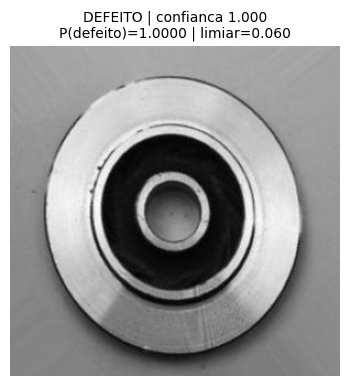

   Resultado: defeito (P(defeito)=1.0000)


In [ ]:
# ============================================================
# FUNÇÃO DE INFERÊNCIA: CAMINHO LOCAL OU URL
# ============================================================

def carregar_imagem(caminho_ou_url):
    """Abre uma imagem a partir de um caminho no disco ou de uma URL http(s)."""
    if str(caminho_ou_url).lower().startswith(("http://", "https://")):
        resposta = requests.get(caminho_ou_url, timeout=20)
        resposta.raise_for_status()
        return Image.open(io.BytesIO(resposta.content))
    return Image.open(caminho_ou_url)


def preprocessar(imagem):
    """Aplica exatamente o mesmo pré-processamento da avaliação: cinza, resize, normalização."""
    cinza = imagem.convert("L").resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
    tensor = torch.from_numpy(np.asarray(cinza, dtype=np.uint8)).unsqueeze(0).float() / 255.0
    return transformacoes_avaliacao(tensor).unsqueeze(0)


@torch.no_grad()
def prever(caminho_ou_url, limiar=None, modelo_usado=None, mostrar=True):
    """Classifica uma peça e devolve classe, confiança e probabilidades das duas classes."""
    limiar = LIMIAR_ESCOLHIDO if limiar is None else limiar
    rede = modelo if modelo_usado is None else modelo_usado
    rede.eval()

    imagem = carregar_imagem(caminho_ou_url)
    entrada = preprocessar(imagem).to(DISPOSITIVO)
    probabilidade_defeito = torch.sigmoid(rede(entrada).float()).item()

    classe = MAPA_CLASSES[1] if probabilidade_defeito >= limiar else MAPA_CLASSES[0]
    confianca = probabilidade_defeito if classe == MAPA_CLASSES[1] else 1 - probabilidade_defeito

    resultado = {
        "classe": classe,
        "confianca": confianca,
        "probabilidades": {MAPA_CLASSES[0]: 1 - probabilidade_defeito,
                           MAPA_CLASSES[1]: probabilidade_defeito},
        "limiar": limiar,
    }

    if mostrar:
        fig, eixo = plt.subplots(figsize=(3.6, 3.9))
        eixo.imshow(imagem.convert("L"), cmap="gray")
        eixo.axis("off")
        eixo.set_title(f"{classe.upper()} | confianca {confianca:.3f}\n"
                       f"P(defeito)={probabilidade_defeito:.4f} | limiar={limiar:.3f}",
                       fontsize=10)
        plt.tight_layout()
        plt.show()

    return resultado


# ---------- Exemplo 1: uma imagem do conjunto de teste ----------
indice_exemplo = int(np.where(alvo_teste == 1)[0][0])
caminho_exemplo = df_teste["caminho"].iloc[indice_exemplo]
print(f"🔮 Exemplo 1 — imagem do teste | classe real: "
      f"{MAPA_CLASSES[int(alvo_teste[indice_exemplo])]}")
resultado_1 = prever(caminho_exemplo)
print(f"   Resultado: {resultado_1['classe']} "
      f"(P(defeito)={resultado_1['probabilidades']['defeito']:.4f})")

🔮 Exemplo 2 — mesma peca sob 'outra camera' (brilho, contraste, escala, blur, ruido)
   Classe real: defeito


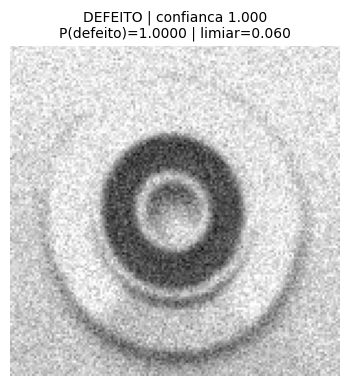


   P(defeito) original   : 1.0000
   P(defeito) perturbada : 1.0000
   Variacao: +0.0000

   💡 A funcao tambem aceita URL: prever('https://.../peca.jpg')


In [ ]:
# ============================================================
# EXEMPLO 2: IMAGEM "EXTERNA" SOB TRANSFORMAÇÃO DRÁSTICA
# ============================================================
# Simulamos uma câmera diferente: brilho e contraste alterados, escala
# reduzida, desfoque e ruído. O arquivo é criado pelo próprio notebook.

def perturbar(imagem, fator_brilho=1.6, fator_contraste=0.6, escala=0.5,
              raio_blur=1.5, ruido=18.0, semente=SEED):
    """Aplica brilho, contraste, redução de escala, desfoque e ruído gaussiano."""
    gerador = np.random.default_rng(semente)
    saida = imagem.convert("L")
    saida = ImageEnhance.Brightness(saida).enhance(fator_brilho)
    saida = ImageEnhance.Contrast(saida).enhance(fator_contraste)
    novo_lado = max(16, int(saida.size[0] * escala))
    saida = saida.resize((novo_lado, novo_lado), Image.BILINEAR)
    saida = saida.filter(ImageFilter.GaussianBlur(radius=raio_blur))
    arranjo = np.asarray(saida, dtype=np.float32)
    arranjo = np.clip(arranjo + gerador.normal(0, ruido, arranjo.shape), 0, 255)
    return Image.fromarray(arranjo.astype(np.uint8))


with Image.open(caminho_exemplo) as original:
    imagem_perturbada = perturbar(original)

caminho_perturbado = os.path.join(CONFIG["DIR_SAIDA"], "peca_condicoes_adversas.png")
imagem_perturbada.save(caminho_perturbado)

print("🔮 Exemplo 2 — mesma peca sob 'outra camera' (brilho, contraste, escala, blur, ruido)")
print(f"   Classe real: {MAPA_CLASSES[int(alvo_teste[indice_exemplo])]}")
resultado_2 = prever(caminho_perturbado)

print(f"\n   P(defeito) original   : {resultado_1['probabilidades']['defeito']:.4f}")
print(f"   P(defeito) perturbada : {resultado_2['probabilidades']['defeito']:.4f}")
print(f"   Variacao: {resultado_2['probabilidades']['defeito'] - resultado_1['probabilidades']['defeito']:+.4f}")
print("\n   💡 A funcao tambem aceita URL: prever('https://.../peca.jpg')")

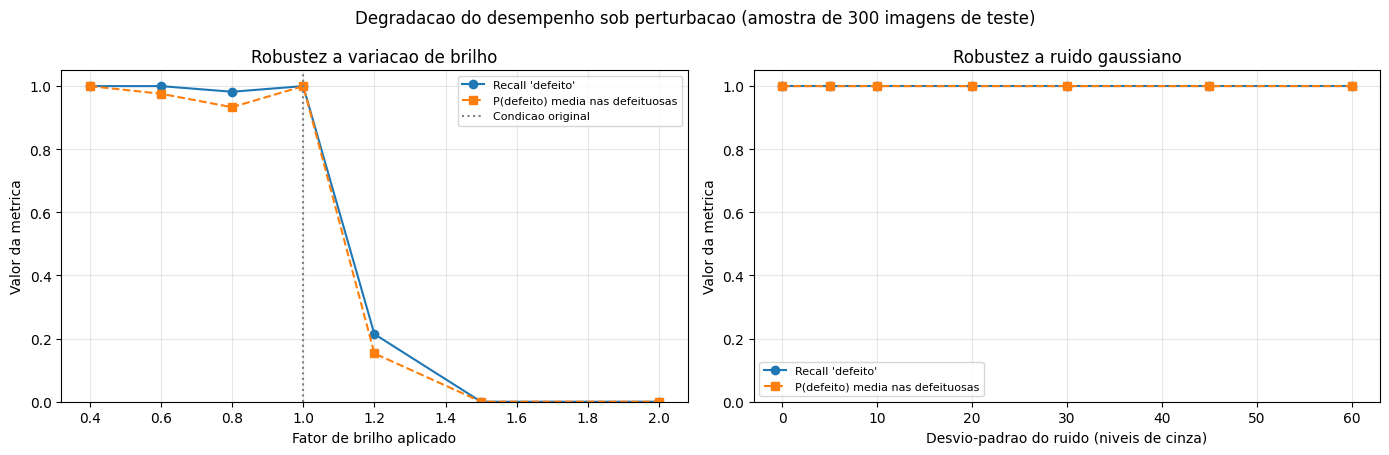

   Queda maxima de recall por brilho: 1.0000
   Queda maxima de recall por ruido : 0.0000


In [ ]:
# ============================================================
# CURVA DE ROBUSTEZ: RECALL x INTENSIDADE DA PERTURBAÇÃO
# ============================================================
# Degradamos progressivamente um subconjunto do teste e medimos o recall.

@torch.no_grad()
def recall_sob_perturbacao(imagens, alvos, transformador, limiar):
    """Aplica uma transformação a todas as imagens e mede recall e P(defeito) média."""
    tensores = []
    for arranjo in imagens:
        transformada = transformador(Image.fromarray(arranjo))
        transformada = transformada.convert("L").resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
        tensor = torch.from_numpy(np.asarray(transformada, dtype=np.uint8)).unsqueeze(0).float() / 255.0
        tensores.append(transformacoes_avaliacao(tensor))
    lote = torch.stack(tensores).to(DISPOSITIVO)
    modelo.eval()
    probabilidades = torch.sigmoid(modelo(lote).float()).cpu().numpy()
    predicoes = (probabilidades >= limiar).astype(int)
    return (recall_score(alvos, predicoes, zero_division=0),
            float(probabilidades[alvos == 1].mean()))


rng_rob = np.random.default_rng(SEED)
n_sub = min(300, len(img_teste))
sub = rng_rob.choice(len(img_teste), n_sub, replace=False)
img_sub, alvo_sub = img_teste[sub], alvo_teste[sub].astype(int)

fatores_brilho = [0.4, 0.6, 0.8, 1.0, 1.2, 1.5, 2.0]
niveis_ruido = [0, 5, 10, 20, 30, 45, 60]

recalls_brilho, probs_brilho = [], []
for fator in fatores_brilho:
    r, p = recall_sob_perturbacao(
        img_sub, alvo_sub,
        lambda im, f=fator: ImageEnhance.Brightness(im).enhance(f),
        LIMIAR_ESCOLHIDO)
    recalls_brilho.append(r)
    probs_brilho.append(p)

recalls_ruido, probs_ruido = [], []
for nivel in niveis_ruido:
    def aplicar_ruido(im, s=nivel):
        arranjo = np.asarray(im, dtype=np.float32)
        arranjo = np.clip(arranjo + np.random.default_rng(SEED).normal(0, s, arranjo.shape), 0, 255)
        return Image.fromarray(arranjo.astype(np.uint8))
    r, p = recall_sob_perturbacao(img_sub, alvo_sub, aplicar_ruido, LIMIAR_ESCOLHIDO)
    recalls_ruido.append(r)
    probs_ruido.append(p)

fig, eixos = plt.subplots(1, 2, figsize=(14, 4.6))

eixos[0].plot(fatores_brilho, recalls_brilho, marker="o", label="Recall 'defeito'")
eixos[0].plot(fatores_brilho, probs_brilho, marker="s", ls="--",
              label="P(defeito) media nas defeituosas")
eixos[0].axvline(1.0, color="gray", ls=":", label="Condicao original")
eixos[0].set_title("Robustez a variacao de brilho")
eixos[0].set_xlabel("Fator de brilho aplicado")
eixos[0].set_ylabel("Valor da metrica")
eixos[0].set_ylim(0, 1.05)
eixos[0].legend(fontsize=8)
eixos[0].grid(alpha=0.3)

eixos[1].plot(niveis_ruido, recalls_ruido, marker="o", label="Recall 'defeito'")
eixos[1].plot(niveis_ruido, probs_ruido, marker="s", ls="--",
              label="P(defeito) media nas defeituosas")
eixos[1].set_title("Robustez a ruido gaussiano")
eixos[1].set_xlabel("Desvio-padrao do ruido (niveis de cinza)")
eixos[1].set_ylabel("Valor da metrica")
eixos[1].set_ylim(0, 1.05)
eixos[1].legend(fontsize=8)
eixos[1].grid(alpha=0.3)

plt.suptitle(f"Degradacao do desempenho sob perturbacao (amostra de {n_sub} imagens de teste)")
plt.tight_layout()
plt.show()

queda_brilho = max(recalls_brilho) - min(recalls_brilho)
queda_ruido = max(recalls_ruido) - min(recalls_ruido)
print(f"   Queda maxima de recall por brilho: {queda_brilho:.4f}")
print(f"   Queda maxima de recall por ruido : {queda_ruido:.4f}")

> ⚠️ **Alerta de *distribution shift* (mudança de distribuição)**
>
> Todas as imagens de treino vieram de **uma** câmera, **uma** iluminação e **um** tipo de peça, numa bancada controlada. O gráfico acima mostra o que acontece quando só o brilho ou só o ruído mudam — e esses são os casos fáceis. Na prática, uma imagem do mundo real pode diferir em resolução, enquadramento, ângulo, cor de fundo, lente, foco e até no modelo do impulsor.
>
> O ponto mais perigoso não é o modelo errar: é ele errar **com alta confiança**. Uma rede treinada só neste domínio não tem como saber que a entrada é estranha; ela vai produzir um número entre 0 e 1 de qualquer jeito. Por isso, em produção, um sistema assim precisa de: (1) checagem de que a imagem se parece com o que ele viu no treino, (2) monitoramento contínuo da distribuição das probabilidades previstas, e (3) reciclagem periódica com dados novos.

> 💬 **Para discutir:** que sinal simples você monitoraria na linha para detectar que a câmera foi trocada ou desregulada, antes de o modelo começar a errar em silêncio?

---

## 13. 💾 Persistência e exportação

> 🧭 **O que estamos fazendo?** Salvando os pesos (`.pth`), um JSON com toda a configuração de inferência, e exportando o modelo para ONNX com metadados — validando que o ONNX produz a mesma saída do PyTorch.
> 🎯 **Por que é necessário?** O artefato que vai para produção precisa ser autocontido e verificável. ONNX permite rodar o modelo em C++, .NET ou num CLP industrial, sem Python.
> 🚫 **E se pulássemos?** O modelo viveria só neste notebook, e ninguém conseguiria reproduzir a inferência daqui a seis meses.

> 💡 **Por que salvar só os pesos torna o modelo inútil?** Um `state_dict` é um dicionário de matrizes. Sem saber que a entrada é 128x128 em 1 canal, que foi normalizada com **aquela** média e **aquele** desvio, e que a decisão usa o limiar da seção 11, qualquer pessoa que carregue o arquivo vai pré-processar diferente e obter previsões erradas — sem nenhum erro aparecer na tela. A configuração não é documentação: é parte do modelo.

In [ ]:
# ============================================================
# SALVAR PESOS + CONFIGURAÇÃO DE INFERÊNCIA
# ============================================================

CAMINHO_PESOS = os.path.join(CONFIG["DIR_SAIDA"], "inspetor_fundidos.pth")
CAMINHO_CONFIG = os.path.join(CONFIG["DIR_SAIDA"], "inspetor_fundidos_config.json")

torch.save(modelo.state_dict(), CAMINHO_PESOS)

config_inferencia = {
    "nome_projeto": "Inspetor Visual de Defeitos em Pecas Fundidas",
    "classes": {"0": MAPA_CLASSES[0], "1": MAPA_CLASSES[1]},
    "classe_positiva": MAPA_CLASSES[1],
    "img_size": IMG_SIZE,
    "canais": CONFIG["CANAIS"],
    "normalizacao": {"media": MEDIA, "desvio": DESVIO,
                     "origem": "calculada apenas no conjunto de treino"},
    "limiar_decisao": LIMIAR_ESCOLHIDO,
    "limiar_criterio": motivo_escolha,
    "seed": SEED,
    "arquitetura": "InspetorCNN (stem 5x5 + 5 blocos residuais + pooling global)",
    "melhor_epoca": int(melhor_epoca),
    "metricas_teste": {
        "auc_roc": float(AUC_TESTE),
        "recall_defeito_limiar_padrao": float(RECALL_TESTE_PADRAO),
        "recall_defeito_limiar_escolhido": float(RECALL_TESTE_FINAL),
        "precisao_defeito_limiar_escolhido": float(PRECISAO_TESTE_FINAL),
    },
    "versoes": VERSOES,
}

with open(CAMINHO_CONFIG, "w", encoding="utf-8") as arquivo:
    json.dump(config_inferencia, arquivo, indent=2, ensure_ascii=False)

print(f"💾 Pesos salvos     : {CAMINHO_PESOS} "
      f"({os.path.getsize(CAMINHO_PESOS)/1e6:.2f} MB)")
print(f"💾 Configuracao     : {CAMINHO_CONFIG}")

# ---------- Recarregar e reproduzir uma previsão idêntica ----------
modelo_recarregado = InspetorCNN(canais_entrada=CONFIG["CANAIS"],
                                 dropout=CONFIG["DROPOUT"]).to(DISPOSITIVO)
estado = torch.load(CAMINHO_PESOS, map_location=DISPOSITIVO, weights_only=True)
modelo_recarregado.load_state_dict(estado)
modelo_recarregado.eval()

resultado_original = prever(caminho_exemplo, mostrar=False)
resultado_recarregado = prever(caminho_exemplo, modelo_usado=modelo_recarregado, mostrar=False)
diferenca = abs(resultado_original["probabilidades"]["defeito"]
                - resultado_recarregado["probabilidades"]["defeito"])

print(f"\n🔁 Verificacao de reprodutibilidade")
print(f"   P(defeito) modelo original    : {resultado_original['probabilidades']['defeito']:.8f}")
print(f"   P(defeito) modelo recarregado : {resultado_recarregado['probabilidades']['defeito']:.8f}")
print(f"   Diferenca absoluta            : {diferenca:.2e}")
print(f"   {'✅ Previsao identica.' if diferenca < 1e-6 else '❌ Divergencia inesperada!'}")
print("   (weights_only=True: carrega apenas tensores, sem executar codigo arbitrario)")

💾 Pesos salvos     : /content/artefatos/inspetor_fundidos.pth (6.35 MB)
💾 Configuracao     : /content/artefatos/inspetor_fundidos_config.json

🔁 Verificacao de reprodutibilidade
   P(defeito) modelo original    : 0.99999976
   P(defeito) modelo recarregado : 0.99999976
   Diferenca absoluta            : 0.00e+00
   ✅ Previsao identica.
   (weights_only=True: carrega apenas tensores, sem executar codigo arbitrario)


In [ ]:
# ============================================================
# EXPORTAÇÃO ONNX COM METADADOS E EIXO DE BATCH DINÂMICO
# ============================================================

CAMINHO_ONNX = os.path.join(CONFIG["DIR_SAIDA"], "inspetor_fundidos.onnx")

modelo_cpu = InspetorCNN(canais_entrada=CONFIG["CANAIS"], dropout=CONFIG["DROPOUT"])
modelo_cpu.load_state_dict(torch.load(CAMINHO_PESOS, map_location="cpu", weights_only=True))
modelo_cpu.eval()

entrada_exemplo = torch.randn(1, CONFIG["CANAIS"], IMG_SIZE, IMG_SIZE)

argumentos_export = dict(
    input_names=["entrada"],
    output_names=["logit"],
    dynamic_axes={"entrada": {0: "lote"}, "logit": {0: "lote"}},
    opset_version=17,
)

try:
    torch.onnx.export(modelo_cpu, entrada_exemplo, CAMINHO_ONNX,
                      dynamo=False, **argumentos_export)
except TypeError:
    # Versões antigas do torch não conhecem o argumento dynamo
    torch.onnx.export(modelo_cpu, entrada_exemplo, CAMINHO_ONNX, **argumentos_export)

# Metadados incorporados ao arquivo: o ONNX passa a carregar sua própria bula
grafo_onnx = onnx.load(CAMINHO_ONNX)
for chave, valor in {
    "projeto": config_inferencia["nome_projeto"],
    "classes": json.dumps(config_inferencia["classes"], ensure_ascii=False),
    "classe_positiva": MAPA_CLASSES[1],
    "img_size": str(IMG_SIZE),
    "normalizacao_media": f"{MEDIA:.6f}",
    "normalizacao_desvio": f"{DESVIO:.6f}",
    "limiar_decisao": f"{LIMIAR_ESCOLHIDO:.6f}",
    "saida": "logit; aplicar sigmoid para obter P(defeito)",
    "versao_torch": torch.__version__,
}.items():
    entrada_meta = grafo_onnx.metadata_props.add()
    entrada_meta.key, entrada_meta.value = chave, valor

onnx.save(grafo_onnx, CAMINHO_ONNX)
onnx.checker.check_model(onnx.load(CAMINHO_ONNX))

print(f"📦 ONNX exportado: {CAMINHO_ONNX} "
      f"({os.path.getsize(CAMINHO_ONNX)/1e6:.2f} MB)")
print("   Metadados incorporados:")
for propriedade in onnx.load(CAMINHO_ONNX).metadata_props:
    print(f"      {propriedade.key:<20} = {propriedade.value}")

/tmp/ipykernel_3950/2206802227.py:21: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(modelo_cpu, entrada_exemplo, CAMINHO_ONNX,


📦 ONNX exportado: /content/artefatos/inspetor_fundidos.onnx (6.31 MB)
   Metadados incorporados:
      projeto              = Inspetor Visual de Defeitos em Pecas Fundidas
      classes              = {"0": "ok", "1": "defeito"}
      classe_positiva      = defeito
      img_size             = 128
      normalizacao_media   = 0.563852
      normalizacao_desvio  = 0.234299
      limiar_decisao       = 0.060000
      saida                = logit; aplicar sigmoid para obter P(defeito)
      versao_torch         = 2.11.0+cu128


In [ ]:
# ============================================================
# VALIDAÇÃO DO ONNX: A SAÍDA COINCIDE COM A DO PYTORCH?
# ============================================================
# Exportar sem verificar é confiar que nada se perdeu na tradução.
# Testamos com um lote real do conjunto de teste e com batch de tamanho diferente.

sessao = onnxruntime.InferenceSession(CAMINHO_ONNX, providers=["CPUExecutionProvider"])

lote_teste = torch.stack([
    transformacoes_avaliacao(torch.from_numpy(img).unsqueeze(0).float() / 255.0)
    for img in img_teste[:16]
])

with torch.no_grad():
    saida_pytorch = modelo_cpu(lote_teste).numpy()

saida_onnx = sessao.run(["logit"], {"entrada": lote_teste.numpy()})[0]

diferenca_maxima = float(np.abs(saida_pytorch - saida_onnx.reshape(saida_pytorch.shape)).max())
TOLERANCIA = 1e-4

print(f"🔍 Comparacao PyTorch x ONNX Runtime (lote de {len(lote_teste)} imagens reais)")
print(f"   Diferenca maxima absoluta nos logits: {diferenca_maxima:.3e}")
print(f"   Tolerancia exigida: {TOLERANCIA:.0e}")
print(f"   {'✅ ONNX validado.' if diferenca_maxima < TOLERANCIA else '❌ FALHOU — nao use este ONNX!'}")

# Eixo de batch dinâmico: o mesmo arquivo aceita lotes de tamanhos diferentes
for tamanho_lote in (1, 5, 16):
    entrada_variavel = lote_teste[:tamanho_lote].numpy()
    saida_variavel = sessao.run(["logit"], {"entrada": entrada_variavel})[0]
    print(f"   lote={tamanho_lote:>2} -> saida {saida_variavel.shape} ✅")

assert diferenca_maxima < TOLERANCIA, "Saida do ONNX divergiu do PyTorch."
ONNX_VALIDADO = True
DIFERENCA_ONNX = diferenca_maxima

🔍 Comparacao PyTorch x ONNX Runtime (lote de 16 imagens reais)
   Diferenca maxima absoluta nos logits: 8.583e-06
   Tolerancia exigida: 1e-04
   ✅ ONNX validado.
   lote= 1 -> saida (1,) ✅
   lote= 5 -> saida (5,) ✅
   lote=16 -> saida (16,) ✅


> 💬 **Para discutir:** o ONNX guarda o limiar nos metadados, mas não o aplica — a saída continua sendo um logit. Por que é melhor que a decisão fique fora do modelo exportado?

---

## 14. 🧭 Limitações e próximos passos

### 14.1 O que este modelo **não** faz

| Limitação | Consequência prática |
|---|---|
| Não **localiza** o defeito | Diz "defeituosa", não diz onde nem quanto. O operador ainda precisa procurar |
| Não **tipifica** o defeito | Porosidade, rebarba e trinca viram um único rótulo. Não serve para diagnóstico de processo |
| Só vale para **este impulsor** | Outra peça, outro molde, outro fornecedor: precisa de novos dados |
| Só vale para a **vista superior** | Um defeito lateral ou interno é invisível para o modelo |
| Não quantifica sua própria **incerteza** | Retorna uma probabilidade, não um "não sei" |
| Sem **transfer learning** nesta versão | Treinado do zero, com o que este dataset oferece |

### 14.2 Como isso falharia em produção

1. **Câmera nova ou desregulada** — foco, ganho ou distância mudam; o modelo continua respondendo, agora errado (vide a curva de robustez da seção 12).
2. **Iluminação alterada** — uma lâmpada queimada muda o brilho médio; a seção 10 mediu quanto o recall varia por faixa de brilho.
3. **Molde novo ou desgastado** — a textura de referência muda, e "normal" para o modelo deixa de ser normal na linha.
4. **Prevalência diferente** — a seção 11 mostra a precisão caindo só por o defeito ficar raro, sem nenhuma mudança no modelo.
5. **Vazamento residual** — o augmentation do autor pode ter criado variantes que o pHash canônico não detecta (rotações não múltiplas de 90°, zoom forte). Se isso ocorreu, as métricas de teste estão otimistas. A auditoria da seção 4 reduz o risco, mas **não o elimina**.
6. **Deriva silenciosa** — sem monitoramento, a degradação só aparece quando o cliente reclama.

### 14.3 Próximos passos, priorizados

| # | Melhoria | Impacto | Esforço | Por quê |
|---|---|---|---|---|
| 1 | **Monitoramento de drift em produção** | Alto | Baixo | Registrar a distribuição de P(defeito) por turno e alertar quando ela se deslocar. Protege contra os 6 modos de falha acima e não exige retreinar nada |
| 2 | **Transfer learning** (ResNet-18/EfficientNet pré-treinada, adaptada para 1 canal) | Alto | Médio | Aproveita representações visuais gerais; costuma elevar recall e, principalmente, melhorar a robustez fora do domínio |
| 3 | **Múltiplas seeds com média ± desvio** | Médio | Baixo | Todas as métricas aqui vêm de **uma** execução. Rodar 5 seeds mostra se a diferença para o baseline é real ou ruído |
| 4 | **Detecção/segmentação do defeito** (YOLO, U-Net) | Alto | Alto | Transforma "peça reprovada" em "trinca de 4 mm às 3 horas": aciona a correção do processo, não só a triagem |
| 5 | **Split por peça física** com rastreabilidade | Médio | Alto | Se a fábrica registrar o ID da peça na captura, o agrupamento deixa de depender de heurística de hash |

---

## 15. 🏁 Resumo final

> 🧭 **O que estamos fazendo?** Imprimindo, a partir de variáveis, todas as métricas do projeto — todas vindas da **mesma época restaurada**.
> 🎯 **Por que é necessário?** Porque um resumo que mistura a menor loss de uma época com o melhor recall de outra descreve um modelo que nunca existiu.
> 🚫 **E se pulássemos?** Reportaríamos um Frankenstein de métricas impossível de reproduzir.

In [ ]:
# ============================================================
# RESUMO FINAL — TODAS AS MÉTRICAS DA MESMA ÉPOCA RESTAURADA
# ============================================================

largura = 78
print("=" * largura)
print("INSPETOR VISUAL DE DEFEITOS EM PECAS FUNDIDAS — RESUMO FINAL".center(largura))
print("=" * largura)

print("\n[ DADOS ]")
print(f"  Imagens 300x300 utilizadas        : {TOTAL_IMAGENS}")
print(f"  Pastas excluidas do pipeline      : {len(df_fora)} "
      f"({int(df_fora['n_imagens'].sum())} imagens, resolucao != 300x300)")
print(f"  Grupos de quase-duplicatas        : {n_grupos} "
      f"(maior grupo: {maior_grupo} imagens)")
print(f"  Split agrupado (treino/val/teste)  : {len(df_treino)} / {len(df_val)} / {len(df_teste)}")
print(f"  Intersecao de grupos entre conjuntos: "
      f"{sum(len(s) for s in interseccoes.values())} (deve ser 0)")
print(f"  Normalizacao (so do treino)       : media={MEDIA:.4f} desvio={DESVIO:.4f}")

print("\n[ MODELO ]")
print(f"  Arquitetura                       : InspetorCNN residual "
      f"({n_parametros:,} parametros)")
print(f"  Entrada                           : {CONFIG['CANAIS']} x {IMG_SIZE} x {IMG_SIZE}")
print(f"  Tempo de treino                   : {TEMPO_TREINO/60:.1f} min "
      f"({len(historico['loss_treino'])} epocas)")
print(f"  Epoca restaurada (early stopping) : {melhor_epoca}")

print(f"\n[ METRICAS DA EPOCA {melhor_epoca} — VALIDACAO ]")
print(f"  Loss de validacao                 : {historico['loss_val'][i_melhor]:.4f}")
print(f"  Loss de treino                    : {historico['loss_treino'][i_melhor]:.4f}")
print(f"  Recall 'defeito' (limiar 0,5)     : {historico['recall_val'][i_melhor]:.4f}")
print(f"  Diagnostico de aprendizado        : {DIAGNOSTICO}")

print(f"\n[ METRICAS DA EPOCA {melhor_epoca} — TESTE (uma unica avaliacao) ]")
print(f"  AUC-ROC                           : {AUC_TESTE:.4f} "
      f"IC95% [{ic_auc[0]:.4f}, {ic_auc[1]:.4f}]")
print(f"  -- com limiar padrao 0,5 --")
print(f"     recall 'defeito'               : {RECALL_TESTE_PADRAO:.4f} "
      f"IC95% [{ic_recall[0]:.4f}, {ic_recall[1]:.4f}]")
print(f"     precisao 'defeito'             : {precisao_teste:.4f}")
print(f"     falsos negativos / positivos   : {fn} / {fp}")
print(f"  -- com limiar escolhido {LIMIAR_ESCOLHIDO:.3f} (definido na validacao) --")
print(f"     recall 'defeito'               : {RECALL_TESTE_FINAL:.4f} "
      f"IC95% [{ic_recall_final[0]:.4f}, {ic_recall_final[1]:.4f}]")
print(f"     precisao 'defeito'             : {PRECISAO_TESTE_FINAL:.4f}")
print(f"     especificidade                 : {ESPECIFICIDADE_TESTE_FINAL:.4f}")
print(f"     acuracia                       : {ACURACIA_TESTE_FINAL:.4f}")
print(f"     falsos negativos / positivos   : {fn_f} / {fp_f}")
print(f"     meta de recall ({META_RECALL:.2f})          : "
      f"{'ATINGIDA' if RECALL_TESTE_FINAL >= META_RECALL else 'NAO atingida'}")

print("\n[ BASELINES (validacao) ]")
print(f"  Majoritario   : acuracia={base_majoritaria['acuracia']:.4f} "
      f"recall={base_majoritaria['recall']:.4f}")
print(f"  Reg. logistica: acuracia={base_regressao['acuracia']:.4f} "
      f"recall={base_regressao['recall']:.4f} AUC={base_regressao['auc']:.4f}")

print("\n[ IMPACTO DE NEGOCIO (suposicoes editaveis) ]")
print(f"  Custo FN / FP                     : R$ {CUSTO_FN:,.2f} / R$ {CUSTO_FP:,.2f}")
print(f"  Custo no teste (limiar 0,5)       : R$ {CUSTO_TESTE_PADRAO:,.2f}")
print(f"  Custo no teste (limiar escolhido) : R$ {CUSTO_TESTE_FINAL:,.2f}")
for nome, c in cenarios.items():
    print(f"  Por 1.000 pecas — {nome:<34}: FN={c['FN']:.1f} FP={c['FP']:.1f} "
          f"precisao={c['precisao']:.4f}")

print("\n[ ARTEFATOS ]")
print(f"  Pesos        : {CAMINHO_PESOS}")
print(f"  Configuracao : {CAMINHO_CONFIG}")
print(f"  ONNX         : {CAMINHO_ONNX} (diferenca maxima vs PyTorch: {DIFERENCA_ONNX:.2e})")
print("=" * largura)

         INSPETOR VISUAL DE DEFEITOS EM PECAS FUNDIDAS — RESUMO FINAL         

[ DADOS ]
  Imagens 300x300 utilizadas        : 7348
  Pastas excluidas do pipeline      : 2 (1300 imagens, resolucao != 300x300)
  Grupos de quase-duplicatas        : 5950 (maior grupo: 20 imagens)
  Split agrupado (treino/val/teste)  : 5265 / 1044 / 1039
  Intersecao de grupos entre conjuntos: 0 (deve ser 0)
  Normalizacao (so do treino)       : media=0.5639 desvio=0.2343

[ MODELO ]
  Arquitetura                       : InspetorCNN residual (1,577,441 parametros)
  Entrada                           : 1 x 128 x 128
  Tempo de treino                   : 3.5 min (25 epocas)
  Epoca restaurada (early stopping) : 19

[ METRICAS DA EPOCA 19 — VALIDACAO ]
  Loss de validacao                 : 0.0095
  Loss de treino                    : 0.0215
  Recall 'defeito' (limiar 0,5)     : 0.9966
  Diagnostico de aprendizado        : AJUSTE SAUDAVEL

[ METRICAS DA EPOCA 19 — TESTE (uma unica avaliacao) ]
  AUC-ROC      

## 16. 🌐 Implantação: demonstração web (ONNX Runtime Web)

> 🧭 **O que estamos fazendo?** Levando o `inspetor_fundidos.onnx` para dentro do protótipo web (gerado no Lovable), rodando a inferência inteiramente no navegador via `onnxruntime-web` (WebAssembly) — sem servidor Python, sem API própria.
> 🎯 **Por que é necessário?** Um `.onnx` sozinho não é uma demonstração: alguém precisa enviar uma foto, o navegador precisa pré-processar essa imagem exatamente como fizemos no treino, e o resultado precisa aparecer de um jeito que um gestor de qualidade entenda sem ler código.
> 🚫 **E se pulássemos?** O projeto ficaria preso ao Colab. Ninguém fora deste notebook conseguiria testar uma peça nova sem rodar Python.

### 16.1 Arquitetura da demonstração

```
[navegador do usuario]
        |
        v
   upload de imagem (JPG/PNG/WEBP)
        |
        v
   pre-processamento em JS (Canvas 2D)
   cinza -> resize 128x128 -> /255 -> normalizacao
        |
        v
   onnxruntime-web (WASM, 1 thread)
   entrada [1,1,128,128] -> logit
        |
        v
   sigmoid(logit) = P(defeito)
        |
        v
   decisao: P(defeito) >= limiar_decisao ? "defeito" : "ok"
```

Os arquivos do runtime ONNX (`.wasm`/`.mjs`) vêm do **CDN oficial do `onnxruntime-web`**, não de uma cópia local — o motivo está na seção 16.3.

---

In [1]:
# ============================================================
# BAIXAR OS ARTEFATOS DO MODELO (gerados na seção 13)
# ============================================================
# Esta célula roda de forma INDEPENDENTE das seções 0-15: não depende de
# CONFIG estar na memória (por exemplo, após "Reiniciar sessão"). Se os
# arquivos também não existirem mais no disco desta VM — sinal de que é uma
# sessão NOVA, não apenas um reinício —, ela permite reenviá-los manualmente.

import os
from google.colab import files

DIR_ARTEFATOS = "/content/artefatos"   # mesmo caminho de CONFIG["DIR_SAIDA"] na seção 1
NOMES_ARTEFATOS = ["inspetor_fundidos.onnx", "inspetor_fundidos_config.json"]

faltando = [n for n in NOMES_ARTEFATOS
           if not os.path.exists(os.path.join(DIR_ARTEFATOS, n))]
veio_de_upload_manual = False

if faltando:
    print(f"⚠️ Não encontrados em {DIR_ARTEFATOS}: {faltando}")
    print("   Isso acontece quando esta é uma sessão NOVA do Colab (não apenas um")
    print("   'Reiniciar sessão') — o disco da VM anterior foi descartado junto com ela.")
    print("   Opção A: rode as seções 1 a 13 de novo para retreinar e reexportar.")
    print("   Opção B: envie agora os dois arquivos que você já baixou antes:\n")
    os.makedirs(DIR_ARTEFATOS, exist_ok=True)
    enviado = files.upload()

    inesperados = [n for n in enviado if n not in NOMES_ARTEFATOS]
    if inesperados:
        print(f"\n⚠️ Arquivo(s) enviado(s) não são os esperados: {inesperados}")
        print(f"   Esperado exatamente: {NOMES_ARTEFATOS}")
        print("   Isso costuma acontecer quando se envia sem querer o .zip do projeto")
        print("   Lovable — esse .zip é usado mais à frente, na célula 16.4 ('ENVIAR E")
        print("   EXTRAIR O ZIP DO PROJETO'), não aqui. Rode esta célula de novo e")
        print("   selecione os dois arquivos do MODELO (.onnx e .json).\n")

    for nome in enviado:
        os.replace(nome, os.path.join(DIR_ARTEFATOS, nome))
    veio_de_upload_manual = True

# Só baixa de volta para o computador se os arquivos vieram de um treino NESTA
# sessão — e não de um upload manual que você acabou de fazer a partir do seu
# próprio PC (nesse caso você já os tem, baixar de novo só duplicaria o arquivo
# na sua pasta de downloads com um "(1)" no nome).
if veio_de_upload_manual:
    print(f"✅ Arquivos recebidos em {DIR_ARTEFATOS} — não baixados de novo, "
          f"você acabou de envia-los do seu computador.")
else:
    for nome_arquivo in NOMES_ARTEFATOS:
        caminho = os.path.join(DIR_ARTEFATOS, nome_arquivo)
        if os.path.exists(caminho):
            files.download(caminho)
        else:
            print(f"❌ {caminho} ainda não encontrado.")
    print("✅ Se o download não abriu automaticamente, verifique o bloqueador de pop-up do navegador.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Se o download não abriu automaticamente, verifique o bloqueador de pop-up do navegador.


### 16.2 ⚠️ Diagnóstico: por que a inferência falhava no navegador

Ao testar o protótipo através de um túnel (Colab + Cloudflare), a tela de inspeção mostrava:

```
Falha na inferência: no available backend found. ERR: [wasm] TypeError:
Failed to fetch dynamically imported module: .../ort/ort-wasm-simd-threaded.jsep.mjs?import
```

**Causa raiz:** a primeira versão da integração copiava os binários `.wasm`/`.mjs` do `onnxruntime-web` manualmente para `public/ort/`, para funcionar 100% offline. Esses arquivos precisam corresponder **byte a byte** à versão do pacote `onnxruntime-web` que o código JavaScript carrega em tempo de execução. Duas coisas destravaram esse acoplamento:

1. O projeto tem um `bun.lock` — é gerenciado por **Bun**, não npm. Instalar com `npm install` faz uma resolução de dependências própria, que pode divergir da travada no lockfile.
2. Os arquivos de `public/ort/` foram copiados manualmente **uma vez**; qualquer reinstalação de dependências que resolvesse uma versão diferente de `onnxruntime-web` deixava esses arquivos desatualizados em relação ao código que os importa.

O resultado é exatamente esse erro: o navegador tenta importar dinamicamente o arquivo do runtime e ele não corresponde ao que o pacote instalado espera.

> 💡 **Correção aplicada:** remover a configuração manual `ort.env.wasm.wasmPaths = "/ort/"` em `src/lib/onnx-inference.ts`. Sem essa linha, o próprio `onnxruntime-web` busca os arquivos corretos no CDN oficial (jsDelivr), **sempre casados com a versão exatamente instalada** — não há mais cópia manual para ficar desatualizada. A pasta `public/ort/` deixou de ser necessária e foi removida.
>
> ⚠️ **Trade-off:** a demonstração passa a exigir internet no navegador de quem testa (para baixar o runtime do CDN, uma única vez por sessão). Para uma versão realmente offline no futuro, a alternativa robusta é automatizar a cópia dos arquivos como parte do `postinstall`, fixando a versão exata do `onnxruntime-web` no `package.json` — não copiá-los à mão de novo.

A célula abaixo aplica essa mesma correção a qualquer `.zip` exportado do Lovable, para o caso de você reenviar uma versão mais nova do protótipo que ainda tenha o problema.

In [2]:
# ============================================================
# CORREÇÃO AUTOMÁTICA: remover o wasmPaths manual e a pasta public/ort
# ============================================================
# Reaplicável em qualquer export do Lovable que ainda tenha o problema.

import re
import shutil
from pathlib import Path

PASTA_PROJETO = Path("foundry-sight-pro-main")   # ajuste se o nome da pasta for outro
caminho_ts = PASTA_PROJETO / "src" / "lib" / "onnx-inference.ts"
pasta_ort_local = PASTA_PROJETO / "public" / "ort"

if not caminho_ts.exists():
    print(f"❌ {caminho_ts} não encontrado. Extraia o ZIP do Lovable antes desta célula "
          f"(veja a seção 16.4).")
else:
    texto = caminho_ts.read_text(encoding="utf-8")
    texto_corrigido, n_removidas = re.subn(
        r'[ \t]*ort\.env\.wasm\.wasmPaths\s*=\s*["\'][^"\']*["\'];\n', "", texto
    )
    if n_removidas > 0:
        caminho_ts.write_text(texto_corrigido, encoding="utf-8")
        print(f"✅ {caminho_ts}: removida(s) {n_removidas} linha(s) de wasmPaths manual.")
    else:
        print(f"ℹ️ {caminho_ts}: nenhuma linha de wasmPaths manual encontrada "
              f"(já pode estar corrigido).")

    if pasta_ort_local.exists():
        shutil.rmtree(pasta_ort_local)
        print(f"✅ Pasta {pasta_ort_local} removida (não é mais usada).")
    else:
        print(f"ℹ️ Pasta {pasta_ort_local} não existe — nada a remover.")

ℹ️ foundry-sight-pro-main/src/lib/onnx-inference.ts: nenhuma linha de wasmPaths manual encontrada (já pode estar corrigido).
ℹ️ Pasta foundry-sight-pro-main/public/ort não existe — nada a remover.


### 16.3 Colocar os artefatos do modelo dentro do projeto

O `.onnx` e o `.json` de configuração precisam estar em `public/model/` dentro da pasta do projeto extraído, para o navegador conseguir buscá-los como arquivos estáticos.

In [3]:
# ============================================================
# COPIAR OS ARTEFATOS PARA public/model/ DO PROJETO
# ============================================================
# Redefine DIR_ARTEFATOS aqui também: esta célula pode rodar sem que a
# anterior (16.1) tenha rodado na mesma sessão.

DIR_ARTEFATOS = "/content/artefatos"

pasta_model = PASTA_PROJETO / "public" / "model"
pasta_model.mkdir(parents=True, exist_ok=True)

for nome_arquivo in ["inspetor_fundidos.onnx", "inspetor_fundidos_config.json"]:
    origem = Path(DIR_ARTEFATOS) / nome_arquivo
    destino = pasta_model / nome_arquivo
    if origem.exists():
        shutil.copy(origem, destino)
        print(f"✅ {destino} ({destino.stat().st_size / 1e6:.2f} MB)")
    else:
        print(f"❌ {origem} não encontrado — rode a célula de download (16.1) antes desta.")

✅ foundry-sight-pro-main/public/model/inspetor_fundidos.onnx (6.31 MB)
✅ foundry-sight-pro-main/public/model/inspetor_fundidos_config.json (0.00 MB)


### 16.4 Subir o projeto e testar via túnel

Fluxo único, na ordem: instalar Node e Bun (o gerenciador de pacotes correto para este projeto, seção 16.2) → instalar dependências → subir o servidor → abrir um túnel público → testar.

> ⚠️ Rode as células desta seção **uma vez, em ordem**. Se algo falhar no meio, reinicie o ambiente de execução (`Ambiente de execução > Reiniciar sessão`) antes de tentar de novo, em vez de reexecutar por cima — processos de servidor deixados rodando em segundo plano em tentativas anteriores costumam ser a causa de comportamento estranho.

In [4]:
# ============================================================
# ENVIAR E EXTRAIR O ZIP DO PROJETO LOVABLE
# ============================================================

enviado = files.upload()   # selecione o .zip exportado do Lovable
nome_zip = next(iter(enviado))

!unzip -q -o "{nome_zip}"
print(f"✅ Extraído: {nome_zip}")
!ls

Saving foundry-sight-pro-corrigido.zip to foundry-sight-pro-corrigido (1).zip
✅ Extraído: foundry-sight-pro-corrigido (1).zip
 artefatos			        foundry-sight-pro-corrigido.zip
 cloudflared.log		        foundry-sight-pro-main
'foundry-sight-pro-corrigido (1).zip'   sample_data


In [5]:
# ============================================================
# INSTALAR NODE.JS E BUN (uma única vez)
# ============================================================

!curl -fsSL https://deb.nodesource.com/setup_20.x | bash - > /dev/null 2>&1
!apt-get install -y nodejs > /dev/null 2>&1
!curl -fsSL https://bun.sh/install | bash > /dev/null 2>&1

import os
os.environ["PATH"] = f"/root/.bun/bin:{os.environ['PATH']}"

!node -v
!bun --version

v20.20.2
1.4.2


In [12]:
# ============================================================
# INSTALAR DEPENDÊNCIAS E SUBIR O SERVIDOR (bun, não npm — ver 16.2)
# ============================================================

%cd {PASTA_PROJETO}
!bun install
get_ipython().system_raw("bun run dev --host 0.0.0.0 --port 5173 &")

/content/foundry-sight-pro-main
bun install v1.4.2 (744846f84)

Checked 432 installs across 492 packages (no changes) [20.00ms]


In [17]:
# ============================================================
# CONSERTAR O vite.config.ts (comentário quebrado) E LIBERAR O HOST DO TÚNEL
# ============================================================
# Causa raiz confirmada pelo log de erro: o cabeçalho do arquivo (gerado pelo
# scaffold @lovable.dev/vite-tanstack-config) tem uma linha de exemplo sem
# "//" na frente, o que é sintaxe inválida e quebra o parser do Vite antes de
# qualquer coisa subir. Por acaso essa mesma linha quebrada contém o texto
# "allowedHosts: true", o que enganava as checagens das tentativas anteriores
# e fazia elas pularem a correção de verdade.

import glob
import re
import time
from pathlib import Path

candidatos = [p for p in glob.glob("/content/**/vite.config.ts", recursive=True)
             if "node_modules" not in p]
if not candidatos:
    raise FileNotFoundError(
        "Não encontrei vite.config.ts em /content — extraia o ZIP do projeto primeiro."
    )

caminho_vite_config = Path(candidatos[0])
PASTA_PROJETO = caminho_vite_config.parent
print(f"📁 Projeto encontrado em: {PASTA_PROJETO}")

texto_vite = caminho_vite_config.read_text(encoding="utf-8")
linhas = texto_vite.splitlines(keepends=True)

# ------------------------------------------------------------------
# 1) Conserta a linha de documentação quebrada (sem "//"), antes do import.
#    Qualquer linha não vazia ali que não comece com "//" é, por construção
#    do scaffold, sobra de comentário mal formatado — nunca deveria ser
#    código de verdade.
# ------------------------------------------------------------------
idx_import = next(
    (i for i, l in enumerate(linhas) if l.strip().startswith("import ")), None
)

corrigiu_comentario = False
if idx_import is not None:
    for i in range(idx_import):
        conteudo = linhas[i].strip()
        if conteudo and not conteudo.startswith("//"):
            indent = linhas[i][: len(linhas[i]) - len(linhas[i].lstrip())]
            linhas[i] = f"{indent}// {conteudo}\n"
            corrigiu_comentario = True

texto_vite = "".join(linhas)
if corrigiu_comentario:
    print("🧹 Linha de documentação sem '//' corrigida (essa era a causa do PARSE_ERROR na linha 7).")
else:
    print("ℹ️ Nenhuma linha de comentário quebrada encontrada no cabeçalho — já estava ok.")

# ------------------------------------------------------------------
# 2) Insere allowedHosts DENTRO do objeto real de defineConfig, como irmão
#    de "tanstackStart" (é assim que este wrapper espera, conforme a própria
#    documentação do arquivo). A checagem de "já existe?" olha SOMENTE para
#    dentro desse objeto — nunca para comentários — para não repetir o
#    falso positivo das tentativas anteriores.
# ------------------------------------------------------------------
match_config = re.search(r"export default defineConfig\(\{", texto_vite)
if not match_config:
    raise ValueError(
        f"Não encontrei 'export default defineConfig({{' em {caminho_vite_config}. "
        f"Conteúdo atual:\n\n{texto_vite}"
    )

pos_abertura = match_config.end()
regiao_config = texto_vite[pos_abertura:]

if re.search(r"\bvite\s*:\s*\{", regiao_config):
    print("ℹ️ O objeto defineConfig({...}) já tem uma chave 'vite:'. Não mexi, para não duplicar — "
          "confira manualmente se 'allowedHosts: true' está dentro dela.")
    texto_vite_corrigido = texto_vite
else:
    texto_vite_corrigido = (
        texto_vite[:pos_abertura]
        + "\n  vite: { server: { allowedHosts: true } },"
        + texto_vite[pos_abertura:]
    )
    print("✅ 'vite: { server: { allowedHosts: true } }' inserido dentro de export default defineConfig({...}).")

# Checagem simples de sanidade: chaves e parênteses balanceados no arquivo final.
if texto_vite_corrigido.count("{") != texto_vite_corrigido.count("}"):
    raise ValueError("⚠️ Chaves { } desbalanceadas após a edição — NÃO gravando o arquivo. Copie o conteúdo abaixo e me envie.")
if texto_vite_corrigido.count("(") != texto_vite_corrigido.count(")"):
    raise ValueError("⚠️ Parênteses ( ) desbalanceados após a edição — NÃO gravando o arquivo. Copie o conteúdo abaixo e me envie.")

caminho_vite_config.write_text(texto_vite_corrigido, encoding="utf-8")

print("\n--- conteúdo final de", caminho_vite_config, "---")
print(texto_vite_corrigido)

# ------------------------------------------------------------------
# 3) Reinicia o servidor com a saída redirecionada para um log (essencial
#    para diagnosticar se ainda falhar).
# ------------------------------------------------------------------
!pkill -f "vite dev" > /dev/null 2>&1 || true
!pkill -f "bun run dev" > /dev/null 2>&1 || true
!fuser -k 5173/tcp > /dev/null 2>&1 || true
time.sleep(2)

LOG_SERVIDOR = "/content/dev_server.log"
get_ipython().system_raw(
    f"cd {PASTA_PROJETO} && bun run dev --host 0.0.0.0 --port 5173 "
    f"> {LOG_SERVIDOR} 2>&1 &"
)
time.sleep(10)

!curl -sS -o /dev/null -w "status HTTP local apos reiniciar: %{http_code}\n" http://localhost:5173/
!echo "--- últimas linhas de {LOG_SERVIDOR} (útil se o status acima for 000) ---"
!tail -n 40 {LOG_SERVIDOR} 2>/dev/null || echo "(log ainda não existe)"

📁 Projeto encontrado em: /content/foundry-sight-pro-main
🧹 Linha de documentação sem '//' corrigida (essa era a causa do PARSE_ERROR na linha 7).
✅ 'vite: { server: { allowedHosts: true } }' inserido dentro de export default defineConfig({...}).

--- conteúdo final de /content/foundry-sight-pro-main/vite.config.ts ---
// @lovable.dev/vite-tanstack-config already includes the following — do NOT add them manually
// or the app will break with duplicate plugins:
//   - TanStack devtools (dev-only, first), tanstackStart, viteReact, tailwindcss, tsConfigPaths,
//     nitro (build-only using cloudflare as a default target), VITE_* env injection, @ path alias,
//     React/TanStack dedupe, error logger plugins, and sandbox detection (port/host/strictPort).
// You can pass additional config via defineConfig({
  // vite: { server: { allowedHosts: true } }, vite: { ... }, etc... }) if needed.
import { defineConfig } from "@lovable.dev/vite-tanstack-config";

export default defineConfig({
  vite:

In [18]:
# ============================================================
# AGUARDAR O SERVIDOR SUBIR E CONFIRMAR COM UMA REQUISIÇÃO LOCAL
# ============================================================
# Em vez de um único sleep fixo, tenta algumas vezes: o build do TanStack
# Start pode demorar mais que 8-10s dependendo da máquina do Colab.

LOG_SERVIDOR = "/content/dev_server.log"

!for i in $(seq 1 8); do \
   status=$(curl -sS -o /dev/null -w "%{http_code}" http://localhost:5173/ 2>/dev/null); \
   echo "tentativa $i — status HTTP local: $status"; \
   if [ "$status" = "200" ]; then break; fi; \
   sleep 3; \
 done

!echo "--- últimas linhas de {LOG_SERVIDOR} (útil se o status acima nunca virou 200) ---"
!tail -n 40 {LOG_SERVIDOR} 2>/dev/null || echo "(log ainda não existe)"

tentativa 1 — status HTTP local: 200
--- últimas linhas de /content/dev_server.log (útil se o status acima nunca virou 200) ---
$ vite dev --host "0.0.0.0" --port "5173"
The plugin "vite-tsconfig-paths" is detected. Vite now supports tsconfig paths resolution natively via the resolve.tsconfigPaths option. You can remove the plugin and set resolve.tsconfigPaths: true in your Vite config instead.

  VITE v8.1.5  ready in 5044 ms

  ➜  Local:   http://localhost:5173/
  ➜  Network: http://172.28.0.12:5173/
1:28:00 AM [vite] (ssr) connected.


In [19]:
# ============================================================
# ABRIR UM TÚNEL PÚBLICO (cloudflared) E OBTER A URL
# ============================================================

import subprocess
import time
import re
import os

# Encerra qualquer cloudflared de uma tentativa anterior antes de sobrescrever
# o binário — sem isso, um processo já rodando trava o arquivo e o download
# seguinte falha com "Text file busy".
!pkill -f cloudflared > /dev/null 2>&1 || true
time.sleep(1)

if not os.path.exists("cloudflared"):
    !wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
    !chmod +x cloudflared

log_tunel = open("/content/cloudflared.log", "w")
subprocess.Popen(["./cloudflared", "tunnel", "--url", "http://localhost:5173"],
                 stdout=log_tunel, stderr=subprocess.STDOUT)

time.sleep(12)

with open("/content/cloudflared.log") as f:
    conteudo = f.read()

encontrada = re.search(r"https://[a-zA-Z0-9.-]*trycloudflare\.com", conteudo)
if encontrada:
    print(f"✅ URL pública: {encontrada.group(0)}")
else:
    print("⚠️ URL ainda não apareceu no log — espere mais alguns segundos e rode esta célula de novo.")

^C
✅ URL pública: https://physicians-thick-dosage-dicke.trycloudflare.com


In [20]:
# ============================================================
# MOSTRAR O CONTEÚDO ATUAL DE onnx-inference.ts (para diagnóstico)
# ============================================================
import glob
from pathlib import Path

candidatos = [p for p in glob.glob("/content/**/onnx-inference.ts", recursive=True)
             if "node_modules" not in p]

if not candidatos:
    print("❌ Não encontrei onnx-inference.ts em /content.")
else:
    caminho = Path(candidatos[0])
    print(f"📄 {caminho}\n")
    print(caminho.read_text(encoding="utf-8"))

📄 /content/foundry-sight-pro-main/src/lib/onnx-inference.ts

// Inferência do modelo "Inspetor Visual de Defeitos em Peças Fundidas" no navegador.
//
// Reproduz EXATAMENTE o pré-processamento usado no treino/avaliação (ver notebook,
// seção 12 — funções `preprocessar` e `prever`):
//   1) converter para escala de cinza ("L")
//   2) redimensionar para IMG_SIZE x IMG_SIZE com interpolação bilinear
//   3) escalar de 0-255 para 0-1
//   4) normalizar com (x - media) / desvio, usando media/desvio calculados no treino
//   5) tensor de entrada [1, 1, IMG_SIZE, IMG_SIZE]
//   6) rede devolve 1 logit -> sigmoid(logit) = P(defeito)
//   7) decisão = P(defeito) >= limiar_decisao

export interface ModeloConfig {
  nome_projeto: string;
  classes: Record<string, string>;
  classe_positiva: string;
  img_size: number;
  canais: number;
  normalizacao: { media: number; desvio: number; origem: string };
  limiar_decisao: number;
  limiar_criterio: string;
  arquitetura: string;
  metricas_teste: 

> ⚠️ URLs `trycloudflare.com` são **temporárias** (caem quando esta sessão do Colab termina ou reinicia) e não são adequadas como link permanente — servem só para este teste. Para uma URL estável, publique o projeto pelo próprio Lovable.

### 16.5 Checklist de verificação

1. A URL acima abre e mostra a tela "Estação de inspeção".
2. Ao enviar uma imagem e clicar em "Inspecionar", o resultado aparece **sem** a mensagem "Falha na inferência".
3. No console do navegador (F12 → Console/Network), a origem do arquivo do runtime ONNX agora é `cdn.jsdelivr.net`, não mais `/ort/...`.
4. A primeira inferência é mais lenta (baixando o runtime do CDN pela primeira vez); as seguintes são quase instantâneas.


---